<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [70]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [77]:
len(files)

31

In [178]:
reload(constants)
files = constants.SIMULATION_FILES

main_labels = [
    r"$f_{\rm bin} = 1.0$",
    r"$f_{\rm bin} = 0.0$",
    "No BH kicks", "No fallback rescaling", "Hobbs+2005",
    "Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025",
    r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$",
    r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$",
    'Time-evolving potential'
]
markers = ['o'] * (len(main_labels) - 1) + ['d']
initC_labels = [
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$"
]
markers += ['^'] * len(initC_labels)
main_labels += initC_labels
mt_labels = [
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$",
]
markers += ['s'] * len(mt_labels)
labels = main_labels + mt_labels
mt_labels = [main_labels[0]] + mt_labels  # include the fiducial model in the MT section

In [80]:
plot_labels = [
    "Fiducial",
    "Singles",
    "No BH kicks",
    "No fallback rescaling",
    "Hobbs+2005",
    "Fryer+2012 Rapid", r"Mandel & Muller 2020", "Maltsev+2025 (Default)",
    r"Maltsev+2025 ($f_{\rm fb} = 0.0$)", r"Maltsev+2025 ($f_{\rm fb} = 0.25$)", r"Maltsev+2025 ($f_{\rm fb} = 0.75$)", r"Maltsev+2025 ($f_{\rm fb} = 1.0$)",
    r"Maltsev+2025 ($P({\rm pf}) = 0.0$)", r"Maltsev+2025 ($P({\rm pf}) = 1.0$)",
    'Time-evolving potential',
    # initC
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$",
    # mt
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"
]

In [208]:
groups = [
    {
        "title": "Binary fraction",
        "members": [r"$f_{\rm bin} = 1.0$", r"$f_{\rm bin} = 0.0$"],
        "colour": "black"
    },
    {
        "title": "Supernova natal kicks",
        "members": ["No BH kicks", "No fallback rescaling", "Hobbs+2005"],
        "colour": "tab:green"
    },
    {
        "title": "Remnant mass prescriptions",
        "members": ["Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025", r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$", r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$"],
        "colour": "#f14432"
    },
    {
        "title": "Galactic gravitational potential",
        "members": ['Time-evolving potential'],
        "colour": "#FF9D1E"
    },
    {
        "title": "Initial conditions",
        "members": [r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$", r"$\kappa = -1.0$", r"$\kappa = 1.0$", r"$q_{\rm min} = -1.0$", r"$\pi = 0.0$", r"$\pi = -1.0$", r"$P_{\rm orb, max} = 10^3\,{\rm days}$"],
        "colour": "black"
    },
    {
        "title": "Mass transfer physics",
        "members": [r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$", r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"],
        "colour": "tab:blue"
    }
]

group_spacing = 1.0
member_spacing = 1.0

member_y_positions = []
group_title_y_positions = [0.0]
current_y = 1.0
group_ind = 0
label_ind = 0
while label_ind < len(labels):
    label = labels[label_ind]
    if label not in groups[group_ind]["members"]:
        group_ind += 1
        group_title_y_positions.append(current_y + group_spacing)
        current_y += group_spacing
        continue

    member_y_positions.append(current_y)
    current_y += member_spacing
    label_ind += 1

In [81]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(files, labels, [None] * len(files))

Loading post-processed data for $f_{\rm bin} = 1.0$ from fiducial
Loading post-processed data for $f_{\rm bin} = 0.0$ from singles
Loading post-processed data for No BH kicks from bhflag_0
Loading post-processed data for No fallback rescaling from bhflag_3
Loading post-processed data for Hobbs+2005 from kickflag_1
Loading post-processed data for Fryer+2012 Rapid from fryer_rapid
Loading post-processed data for Mandel\&Muller2020 from mandel_muller
Loading post-processed data for Maltsev+2025 from maltsev_fallback_0.5
Loading post-processed data for $f_{\rm fb} = 0.0$ from maltsev_fallback_0.0
Loading post-processed data for $f_{\rm fb} = 0.25$ from maltsev_fallback_0.25
Loading post-processed data for $f_{\rm fb} = 0.75$ from maltsev_fallback_0.75
Loading post-processed data for $f_{\rm fb} = 1.0$ from maltsev_fallback_1.0
Loading post-processed data for $P({\rm pf}) = 0.0$ from maltsev_pf_prob_0.0
Loading post-processed data for $P({\rm pf}) = 1.0$ from maltsev_pf_prob_1.0
Loading pos

In [192]:
for pop in pops:
    if "companion" not in data[pop.label]:
        for key in ["n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]:
            data[pop.label][key] = np.nan
        print("Skipping", pop.label)
        continue
    data[pop.label]["n_BH_star"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] < 10))
    data[pop.label]["n_BH_wd"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (np.isin(data[pop.label]["companion"]["BH"], [10, 11, 12])))
    data[pop.label]["n_BH_NS"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] == 13))
    data[pop.label]["n_BH_BH"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["primary"]["BH"]) & (data[pop.label]["companion"]["BH"] == 14))

    data[pop.label]["n_NS_star"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["companion"]["NS"] < 10))
    data[pop.label]["n_NS_wd"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (np.isin(data[pop.label]["companion"]["NS"], [10, 11, 12])))
    data[pop.label]["n_NS_NS"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["primary"]["NS"]) & (data[pop.label]["companion"]["NS"] == 13))

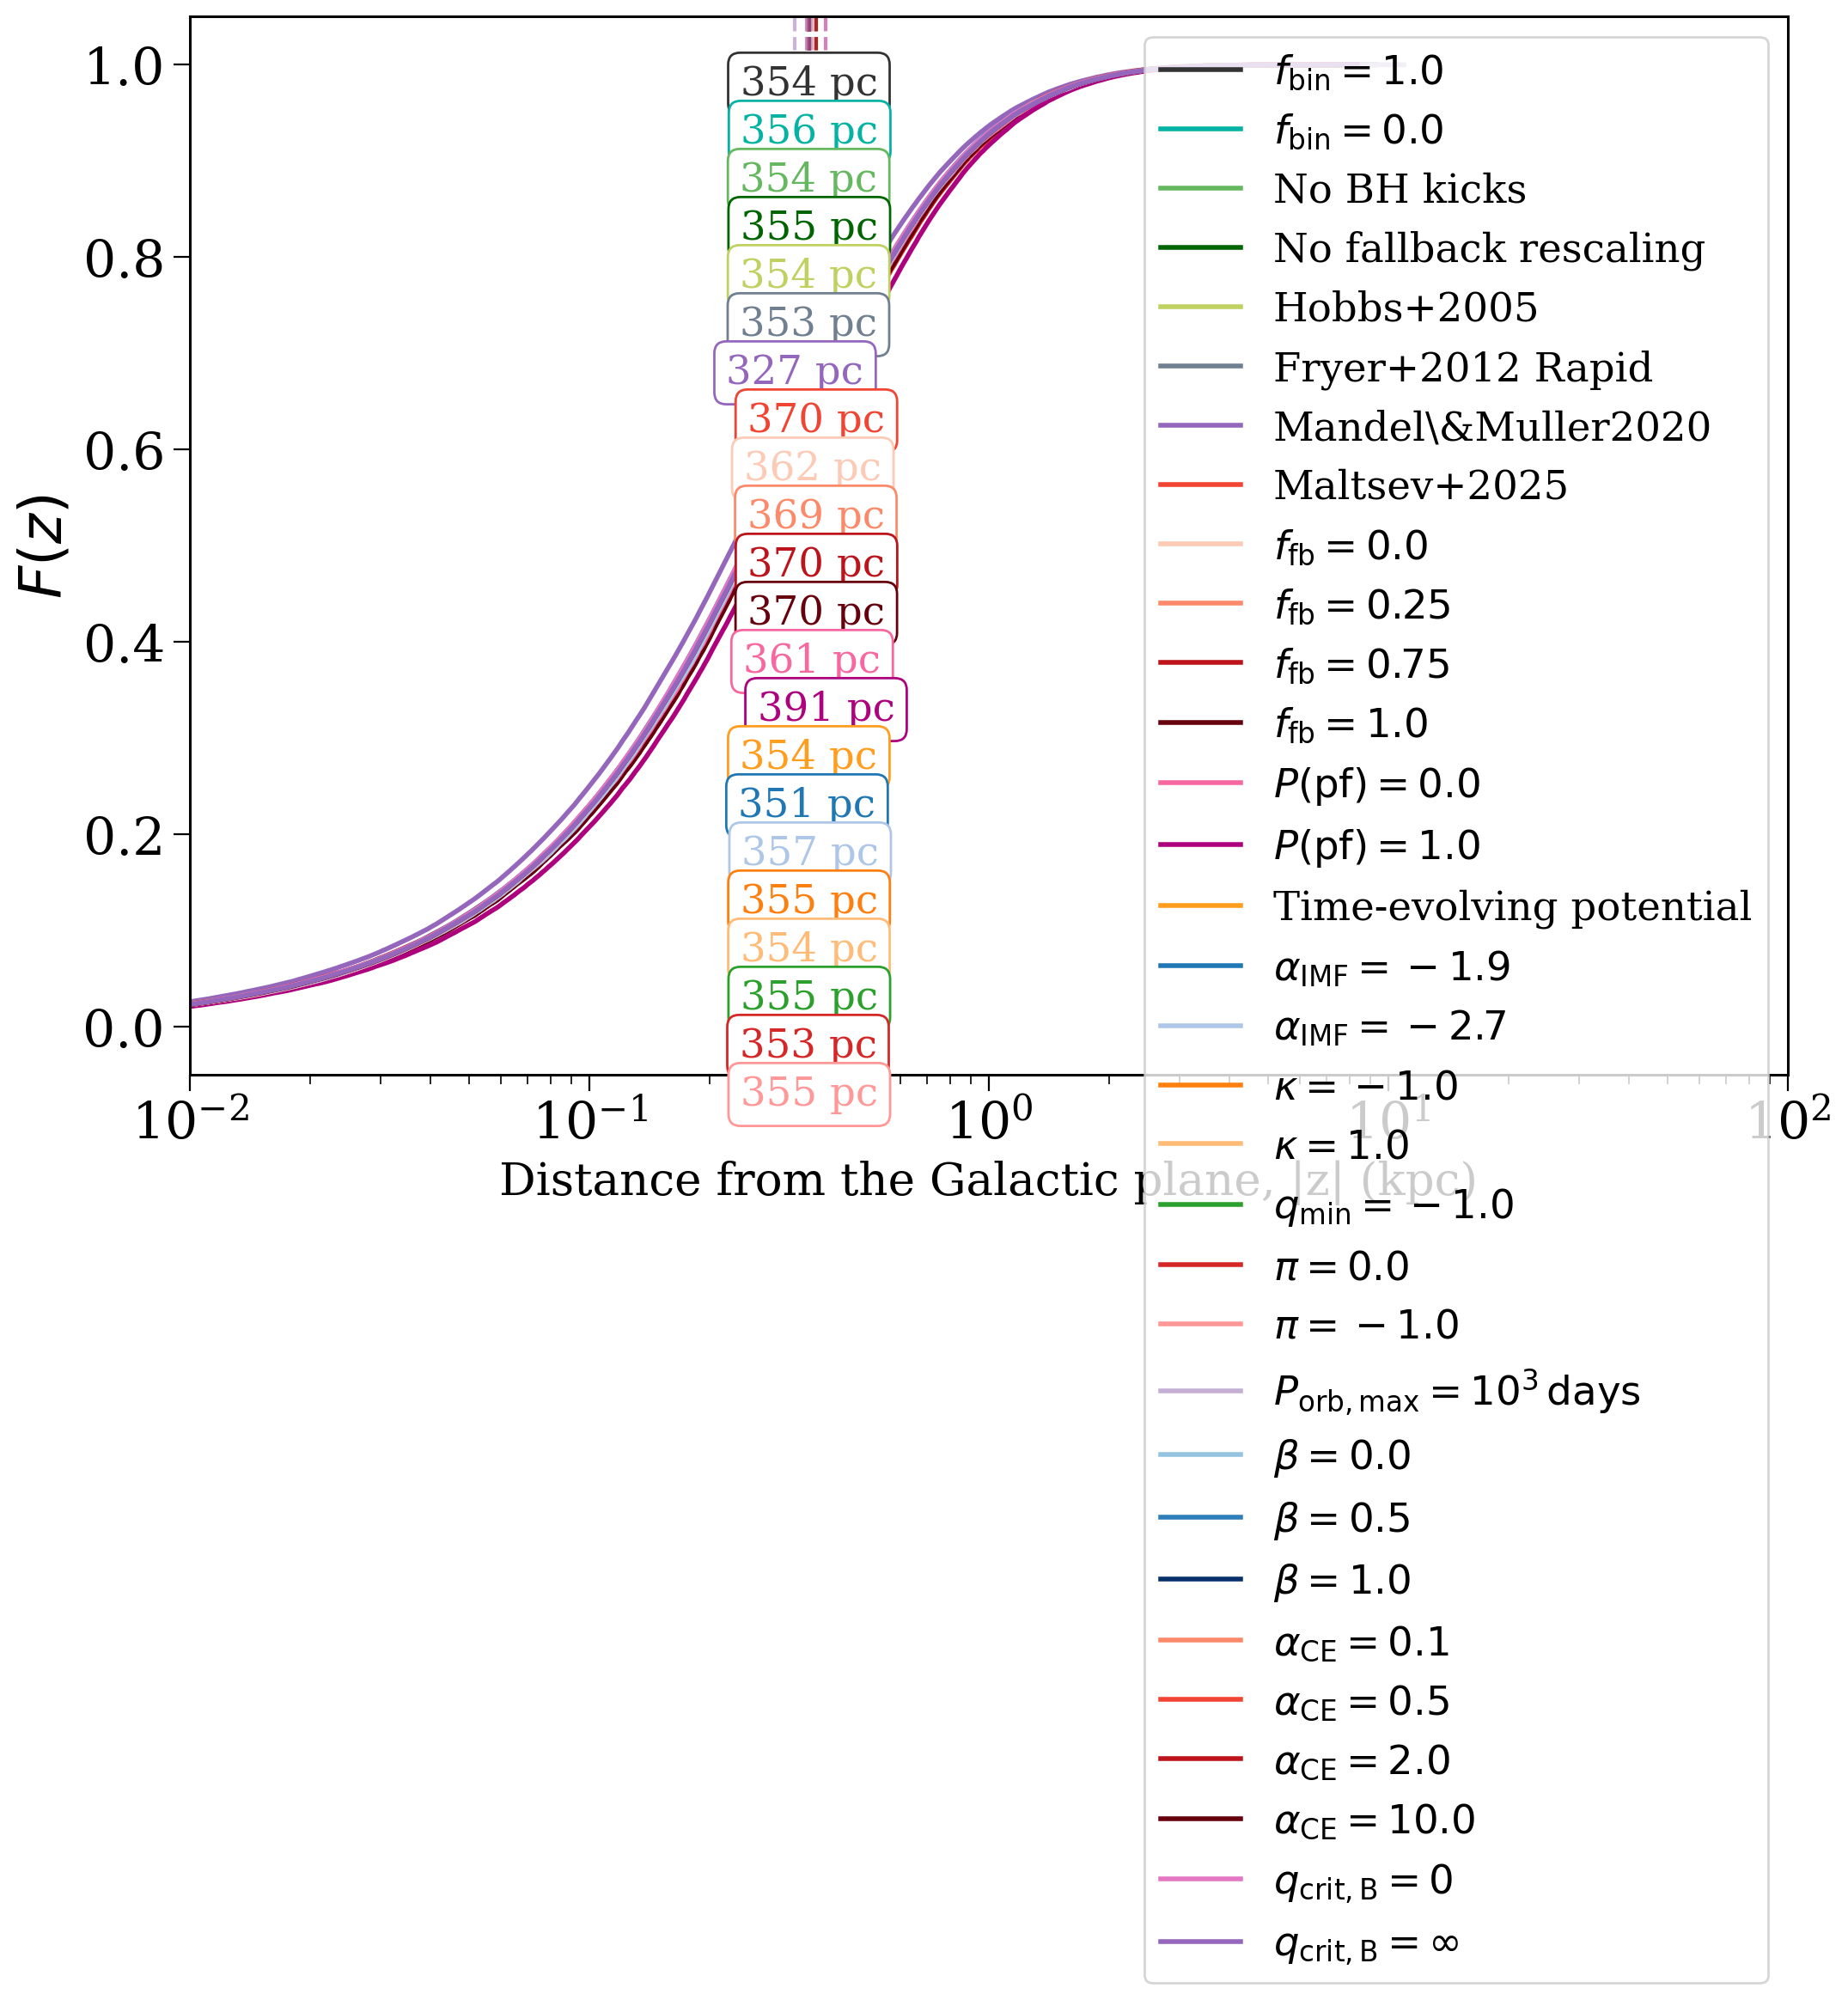

In [83]:
reload(plotting)

fig, ax = plt.subplots()

scale_heights = []
scale_height_errs = []

for label, colour in zip(labels, constants.SIMULATION_COLOURS):
    sh, sh_err, _, _ = plotting.estimate_scale_height_cdf(
        z=data[label]["init_z"]["BH"][~data[label]["escaped"]["BH"]],
        fig=fig,
        ax=ax,
        plot=True,#label == "No BH kicks",
        show=False,
        label=label,
        colour=colour,
        xlim=(1e-2, 1e2),
        scale_height_loc=1 - labels.index(label) * 0.05
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(0 * 1000)

ax.legend()
plt.show()

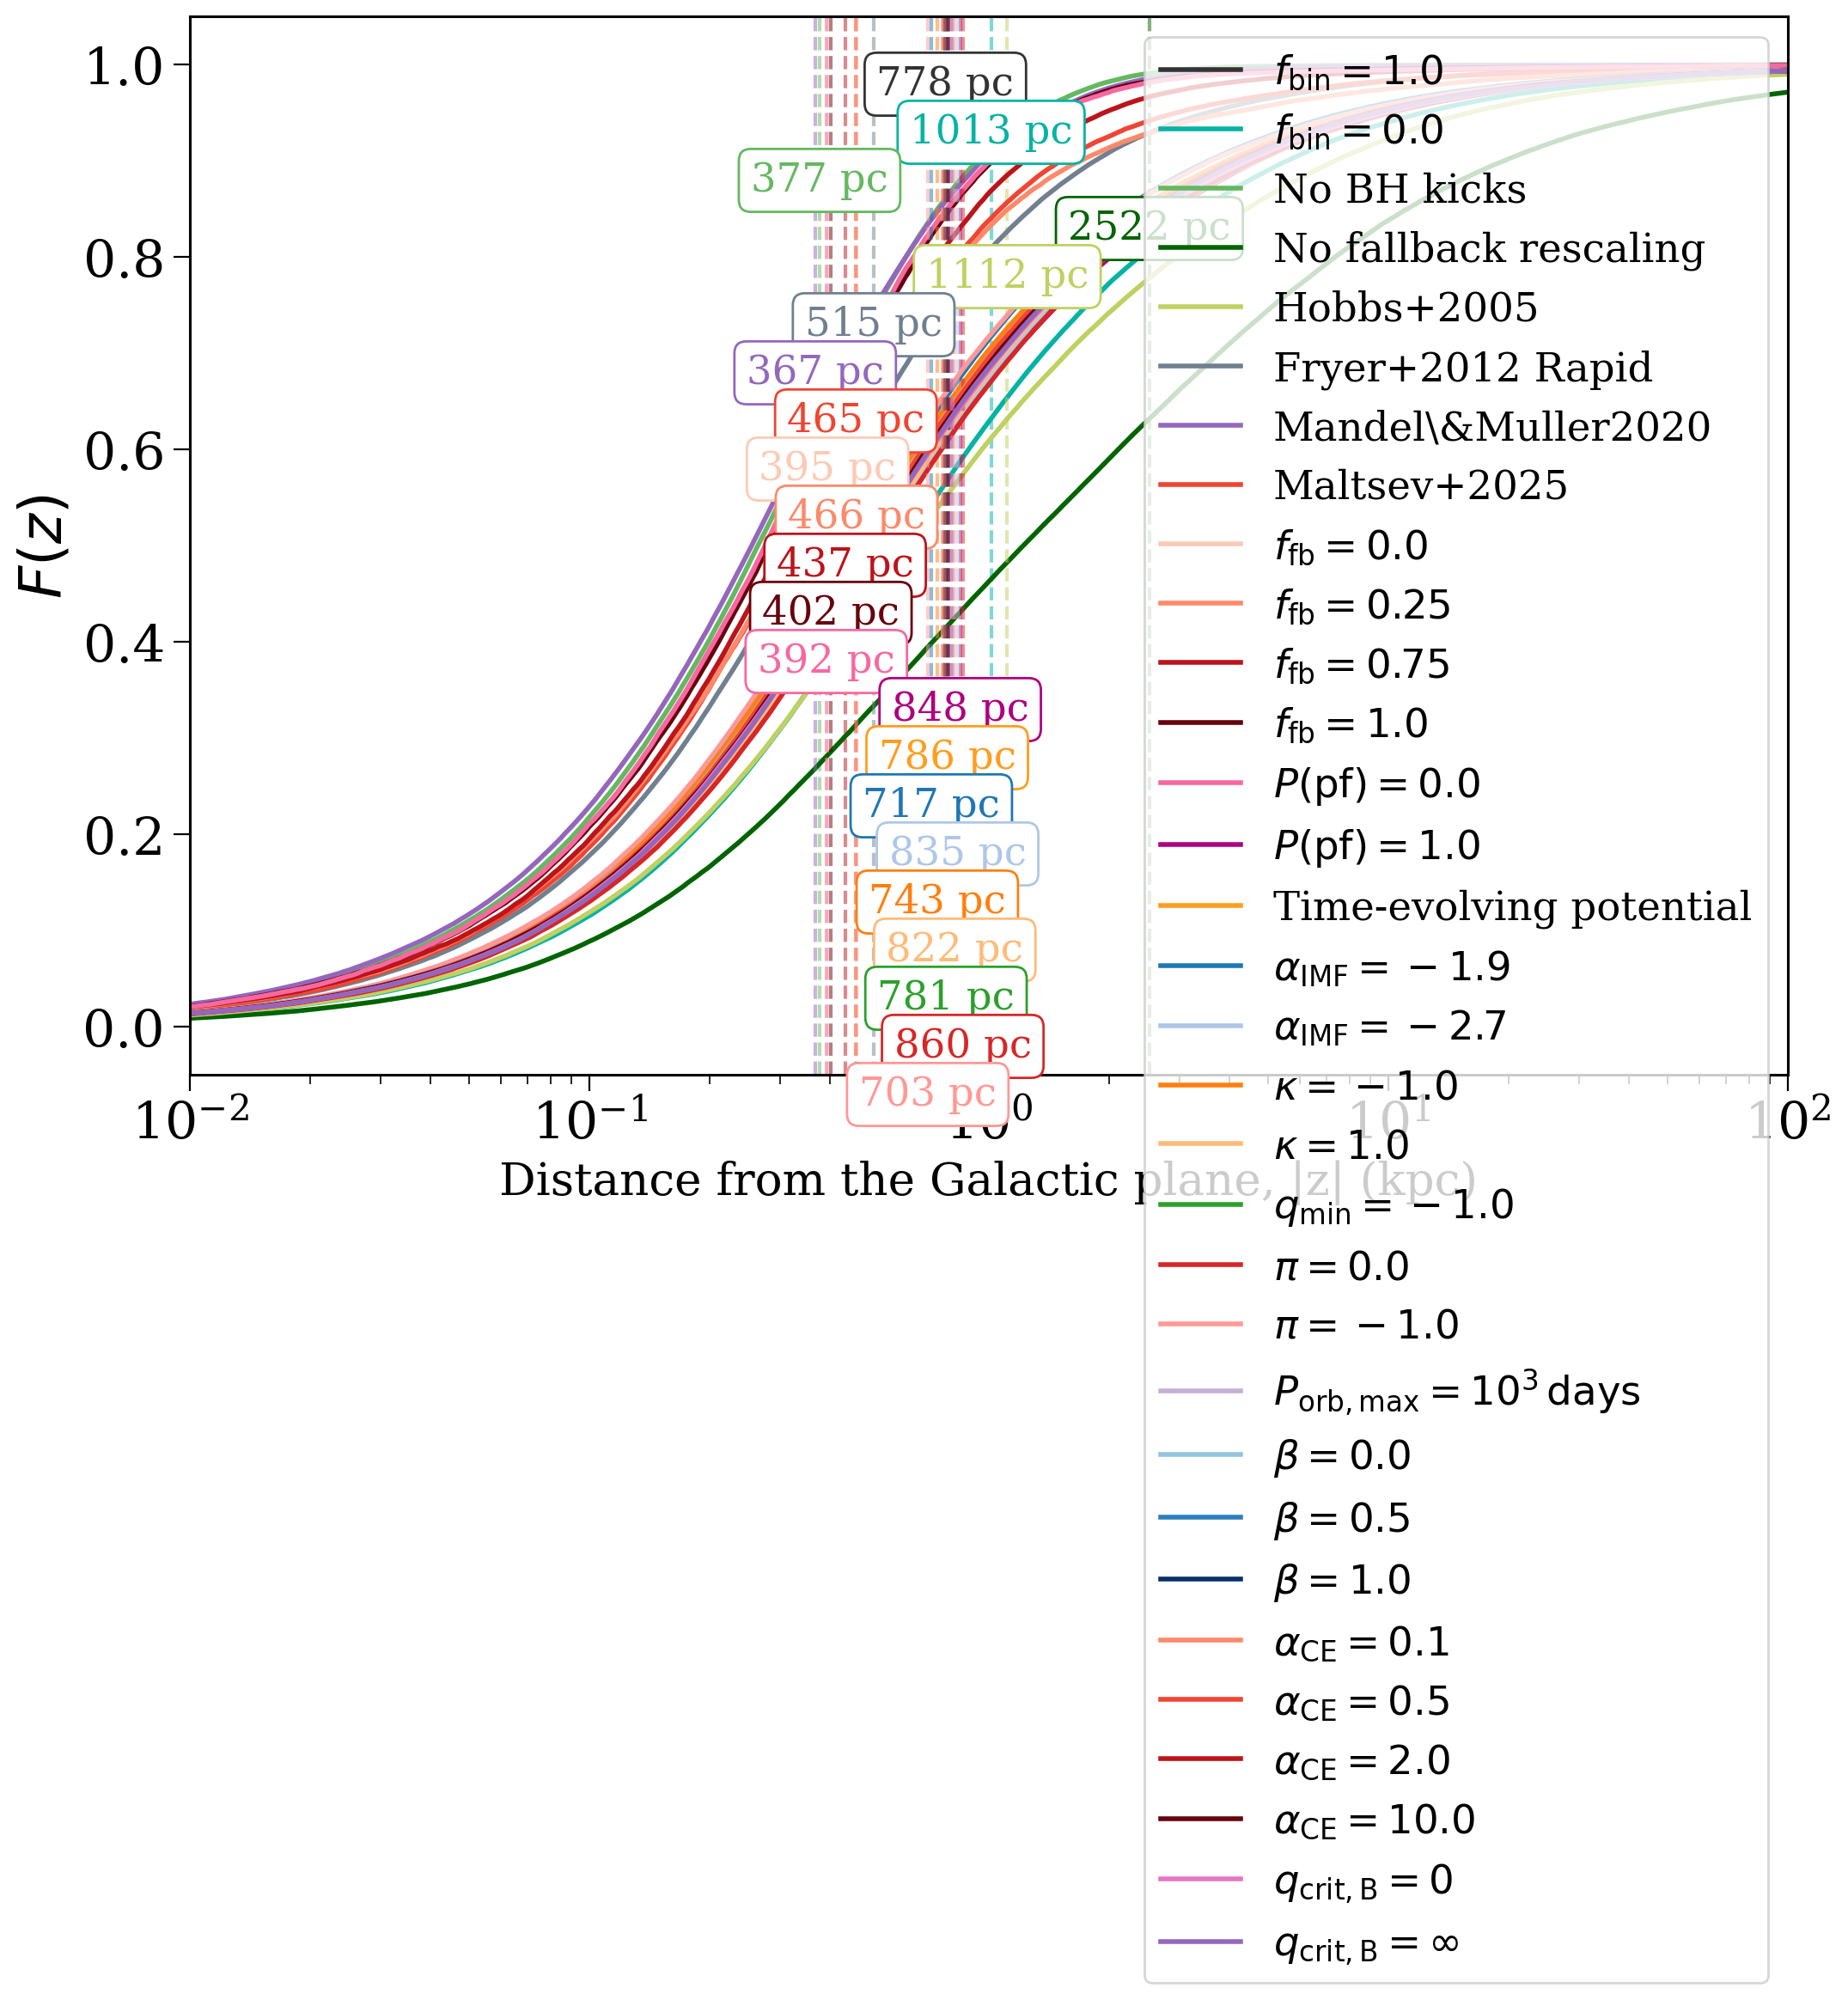

In [84]:
reload(plotting)

fig, ax = plt.subplots()

scale_heights = []
scale_height_errs = []

for label, colour in zip(labels, constants.SIMULATION_COLOURS):
    sh, sh_err, _, _ = plotting.estimate_scale_height_cdf(
        z=data[label]["pos"]["BH"][:, 2][~data[label]["escaped"]["BH"]],
        fig=fig,
        ax=ax,
        plot=True,#label == "No BH kicks",
        show=False,
        label=label,
        colour=colour,
        xlim=(1e-2, 1e2),
        scale_height_loc=1 - labels.index(label) * 0.05
    )
    scale_heights.append(sh * 1000)
    scale_height_errs.append(0 * 1000)

ax.legend()
plt.show()

In [85]:
stats = {
    "scale_up": [6e10 / data[label]["mass_binaries"] for label in labels],
    "n_BH": [data[label]["n_BH"] for label in labels],
    "m_BH": [sum(data[label]["mass"]["BH"]) for label in labels],
    "scale_height": scale_heights,
    "scale_height_err": scale_height_errs,
    r"$f_{\rm esc}$": [data[label]["escaped"]["BH"].sum() / len(data[label]["escaped"]["BH"])
                       for label in labels],
    r"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) < 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$": [data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) >= 1) & ~(data[label]["escaped"]["BH"])].mean() for label in labels],
    r"$f_{\rm bound}$": [(data[label]["sep"]["BH"] > 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm merger}$": [(data[label]["sep"]["BH"] == 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm unbound}$": [(data[label]["sep"]["BH"] < 0).sum() / data[label]["n_BH"] for label in labels],
    "n_BH_star": [data[label]["n_BH_star"] for label in labels],
    "n_BH_wd": [data[label]["n_BH_wd"] for label in labels],
    "n_BH_NS": [data[label]["n_BH_NS"] for label in labels],
    "n_BH_BH": [data[label]["n_BH_BH"] for label in labels],
    "n_NS_star": [data[label]["n_NS_star"] for label in labels],
    "n_NS_wd": [data[label]["n_NS_wd"] for label in labels],
    "n_NS_NS": [data[label]["n_NS_NS"] for label in labels],
}

df = pd.DataFrame(stats)
df.index = labels

# fix stats for singles because wide binaries make it funky
df.loc[r"$f_{\rm bin} = 0.0$", [r"$f_{\rm bound}$", r"$f_{\rm merger}$", r"$f_{\rm unbound}$", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

for col, norm in zip(
    ["n_BH", "m_BH", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"],
    [1e8, 1e9, 1e4, 1e5, 1e5, 1e6, 1e4, 1e5, 1e4]
):
    df[col] *= df["scale_up"] / norm
del df["scale_up"]

latex_header = [r"$N_{\rm BH} / 10^8$", r"$M_{\rm BH} / 10^9 M_\odot$", r"$h_z$ (pc)", r"$\sigma_{h_z}$ (pc)"]
df.rename(columns=dict(zip(df.columns, latex_header)), inplace=True)
df.rename(columns={
    "n_BH_star": r"$N_{\rm BH\text{-}star} / 10^4$",
    "n_BH_wd": r"$N_{\rm BH\text{-}WD} / 10^5$",
    "n_BH_NS": r"$N_{\rm BH\text{-}NS} / 10^5$",
    "n_BH_BH": r"$N_{\rm BH\text{-}BH} / 10^6$",
    "n_NS_star": r"$N_{\rm NS\text{-}star} / 10^4$",
    "n_NS_wd": r"$N_{\rm NS\text{-}WD} / 10^5$",
    "n_NS_NS": r"$N_{\rm NS\text{-}NS} / 10^4$",
}, inplace=True)

df.round(2)

,$N_{\rm BH} / 10^8$,$M_{\rm BH} / 10^9 M_\odot$,$h_z$ (pc),$\sigma_{h_z}$ (pc),$f_{\rm esc}$,"$\langle m \rangle_{|z| < 1 \, {\rm kpc}}$","$\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$",$f_{\rm bound}$,$f_{\rm merger}$,$f_{\rm unbound}$,$N_{\rm BH\text{-}star} / 10^4$,$N_{\rm BH\text{-}WD} / 10^5$,$N_{\rm BH\text{-}NS} / 10^5$,$N_{\rm BH\text{-}BH} / 10^6$,$N_{\rm NS\text{-}star} / 10^4$,$N_{\rm NS\text{-}WD} / 10^5$,$N_{\rm NS\text{-}NS} / 10^4$
$f_{\rm bin} = 1.0$,1.76,1.53,778.01,0,0.03,9.38,7.47,0.09,0.34,0.57,20.06,14.79,1.34,6.75,48.32,29.63,11.79
$f_{\rm bin} = 0.0$,1.66,1.44,1012.73,0,0.04,9.66,7.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No BH kicks,1.73,1.50,376.74,0,0.00,8.56,9.89,0.32,0.36,0.32,77.11,67.98,3.54,23.73,51.06,29.68,11.01
No fallback rescaling,1.81,1.58,2522.37,0,0.15,8.01,9.18,0.00,0.31,0.68,3.13,2.68,0.46,0.27,49.56,29.94,10.75
Hobbs+2005,1.84,1.60,1111.62,0,0.03,9.73,7.26,0.07,0.32,0.61,19.08,12.82,0.57,5.98,38.62,21.69,6.58
Fryer+2012 Rapid,1.36,1.53,514.64,0,0.01,11.48,10.23,0.15,0.35,0.50,31.00,30.24,3.18,8.48,46.11,25.46,10.75
Mandel\&Muller2020,2.20,1.94,367.40,0,0.00,8.83,8.44,0.26,0.42,0.32,105.76,90.01,3.16,23.12,47.41,23.20,10.81
Maltsev+2025,0.38,0.48,464.62,0,0.01,12.80,10.94,0.17,0.32,0.51,12.83,13.02,3.99,2.34,50.08,26.80,11.66
$f_{\rm fb} = 0.0$,0.31,0.43,394.54,0,0.00,13.70,15.32,0.21,0.31,0.48,12.70,12.97,4.25,2.29,46.17,27.07,10.29
$f_{\rm fb} = 0.25$,0.37,0.45,466.22,0,0.02,12.78,9.57,0.17,0.31,0.52,12.96,12.93,3.97,2.33,48.13,26.63,11.79


# Main summary table

In [86]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial", "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution"
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-9]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False

for i, row in df.loc[main_labels].iterrows():
    if i in first_label_to_section:

        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{8}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row.values

    bound_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"

    latex_table += r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & {bound_perc} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.76$ & $1.53$ & $778 \pm 0$ & 2.7\% & $9.38$ & $7.47$ & $9\%$ \\
\quad $f_{\rm bin} = 0.0$ & $1.66$ & $1.44$ & $1013 \pm 0$ & 3.6\% & $9.66$ & $7.35$ & - \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $1.73$ & $1.50$ & $377 \pm 0$ & 0.0\% & $8.56$ & $9.89$ & $32\%$ \\
\quad No fallback rescaling & $1.81$ & $1.58$ & $2522 \pm 0$ & 15.4\% & $8.01$ & $9.18$ & $0\%$ \\
\quad Hobbs+2005 & $1.84$ & $1.60$ & $1112 \pm 0$ & 2.6\% & $9.73$ & $7.26$ & $7\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $1.36$ & $1.53$ & $515 \pm 0$ & 0.7\% & $11.48$ & $10

In [87]:
first_label_to_section = {
    # r"$f_{\rm bin} = 1.0$": "Fiducial",
    "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
cols = cols[-7:-3]
latex_table = r"\begin{tabular}{l" + "c" * len(cols) + r"""}
\toprule
"""
latex_table += "Model & " + " & ".join(cols) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False

for i, row in df.iterrows():
    if i == r"$f_{\rm bin} = 0.0$":
        continue
    if i in first_label_to_section:
        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{" + str(len(cols)) + "}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row[cols].values

    vals_str = [f"${val:.1f}$" for val in vals]

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    latex_table += model_name + f' & {" & ".join(vals_str)} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccc}
\toprule
Model & $N_{\rm BH\text{-}star} / 10^4$ & $N_{\rm BH\text{-}WD} / 10^5$ & $N_{\rm BH\text{-}NS} / 10^5$ & $N_{\rm BH\text{-}BH} / 10^6$ \\
\midrule
\textbf{Fiducial} & $20.1$ & $14.8$ & $1.3$ & $6.7$ \\
\addlinespace[0.5em]
\multicolumn{4}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $77.1$ & $68.0$ & $3.5$ & $23.7$ \\
\quad No fallback rescaling & $3.1$ & $2.7$ & $0.5$ & $0.3$ \\
\quad Hobbs+2005 & $19.1$ & $12.8$ & $0.6$ & $6.0$ \\
\addlinespace[0.5em]
\multicolumn{4}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $31.0$ & $30.2$ & $3.2$ & $8.5$ \\
\quad Mandel\&Muller2020 & $105.8$ & $90.0$ & $3.2$ & $23.1$ \\
\quad Maltsev+2025 & $12.8$ & $13.0$ & $4.0$ & $2.3$ \\
\multicolumn{4}{l}{\textit{\quad Maltsev+2025 fallback mass fraction}} \\
\quad\quad $f_{\rm fb} = 0.0$ & $12.7$ & $13.0$ & $4.2$ & $2.3$ \\
\quad\quad $f_{\rm fb} = 0.25$ & $13.0$ & $12.9$ & $4.0$ & $2.3$ \\
\quad\quad $f_{\rm fb} = 0.75$ & $12.8$ & $13.1$

# Appendix MT summary plot

In [88]:
first_label_to_section = {
    r"$f_{\rm bin} = 1.0$": "Fiducial",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
latex_table = r"""\begin{tabular}{lccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols[:-2]) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[mt_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values
    latex_table += r"\quad " + i + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f} \pm {vals[3]:.0f}$ & {vals[4] * 100:1.1f}\% & ${vals[5]:.2f}$ & ${vals[6]:.2f}$ & ${vals[7] * 100:1.0f}\%$ \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_z$ (pc) & $f_{\rm esc}$ & $\langle m \rangle_{|z| < 1 \, {\rm kpc}}$ & $\langle m \rangle_{|z| \ge 1 \, {\rm kpc}}$ & $f_{\rm bound}$ & $f_{\rm merger}$ & $f_{\rm unbound}$ & $N_{\rm BH\text{-}star} / 10^4$ & $N_{\rm BH\text{-}WD} / 10^5$ & $N_{\rm BH\text{-}NS} / 10^5$ & $N_{\rm BH\text{-}BH} / 10^6$ & $N_{\rm NS\text{-}star} / 10^4$ \\
\midrule
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Fiducial}} \\
\quad $f_{\rm bin} = 1.0$ & $1.76$ & $1.53$ & $778 \pm 0$ & 2.7\% & $9.38$ & $7.47$ & $9\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Mass transfer efficiency}} \\
\quad $\beta = 0.0$ & $1.40$ & $1.24$ & $767 \pm 0$ & 2.6\% & $9.60$ & $7.44$ & $11\%$ \\
\quad $\beta = 0.5$ & $1.57$ & $1.37$ & $788 \pm 0$ & 2.7\% & $9.54$ & $7.40$ & $10\%$ \\
\quad $\beta = 1.0$ & $1.77$ & $1.54$ & $776 \pm 0$ & 2.7\% & $9.38$ & $7.47$ & $9\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{C

# Summary plot

In [339]:
groups = [
    {
        "title": "Binary fraction",
        "members": [r"$f_{\rm bin} = 1.0$", r"$f_{\rm bin} = 0.0$"],
        "colour": "black"
    },
    {
        "title": "Supernova natal kicks",
        "members": ["No BH kicks", "No fallback rescaling", "Hobbs+2005"],
        "colour": "tab:green"
    },
    {
        "title": "Remnant mass prescriptions",
        "members": ["Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025", r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$", r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$"],
        "colour": "#f14432"
    },
    {
        "title": "Time-evolving potential",
        "members": ['Time-evolving potential'],
        "colour": "#FF9D1E"
    },
    {
        "title": "Initial conditions",
        "members": [r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$", r"$\kappa = -1.0$", r"$\kappa = 1.0$", r"$q_{\rm min} = -1.0$", r"$\pi = 0.0$", r"$\pi = -1.0$", r"$P_{\rm orb, max} = 10^3\,{\rm days}$"],
        "colour": "black"
    },
    {
        "title": "Mass transfer physics",
        "members": [r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$", r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"],
        "colour": "tab:blue"
    }
]

group_spacing = 2.0
member_spacing = 1.0

y_positions = [("group", "Binary fraction", (group_spacing + member_spacing) / 2)]
group_ind = 0
label_ind = 0
while label_ind < len(labels):
    label = labels[label_ind]
    if label not in groups[group_ind]["members"]:
        group_ind += 1
        y_positions.append(("group", groups[group_ind]["title"], (group_spacing + member_spacing) / 2))
        continue

    y_positions.append(("member", label, member_spacing))
    label_ind += 1

In [353]:
def summary_plot(label_subset, col, fig=None, ax=None, show=True, groups_to_show=groups, legend_kwargs={"loc":"lower left", "fontsize":12, "ncol":5, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={}, norm=1.0):

    default_ax_kwargs = {
        "xscale": 'log',
    }
    default_ax_kwargs.update(ax_kwargs)
    ax_kwargs = default_ax_kwargs

    if fig is None or ax is None:
        fig, ax = plt.subplots()
    
    labels_inds = np.array([labels.index(label) for label in label_subset])

    # create a legend with the labels
    handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker=markers[i], linestyle='', markersize=10) for i in labels_inds]

    if legend_kwargs is not None:
        ax.legend(handles, np.array(plot_labels)[labels_inds], **legend_kwargs)


    plot_df = df.loc[label_subset]

    vs = plot_df[col].values.copy() * norm
    cs = np.array([constants.SIMULATION_COLOURS[i] for i in labels_inds])
    ms = np.array([markers[i] for i in labels_inds])

    group_titles_to_show = [group["title"] for group in groups_to_show]
    group_ys = []
    ys = []
    current_y = 0.0
    for pos_type, label, dy in y_positions:
        if pos_type == "group" and label in group_titles_to_show:
            group_ys.append(current_y + (dy - member_spacing) / 2)
            current_y += dy
        elif pos_type == "member" and label in label_subset:
            ys.append(current_y)
            current_y += dy

    ys = np.array(ys)

    # ys = np.array([member_y_positions[i] for i in labels_inds])

    for m in np.unique(ms):
        mask = ms == m
        ax.scatter(vs[mask], ys[mask], color=cs[mask], marker=m, zorder=10, s=100)

            # print(labels[i], "not in labels_inds", member_y_positions[i], to_subtract)

    # ys = np.array([member_y_positions[i] for i in labels_inds])

    for m in np.unique(ms):
        mask = ms == m
        ax.scatter(vs[mask], ys[mask], color=cs[mask], marker=m, zorder=10, s=100)

    for group, group_y in zip(groups_to_show, group_ys):
        gc = "grey"#group["colour"]
        ax.annotate(group["title"], xy=(0.5, group_y), fontsize=8, color=gc, ha='center', va='center', xycoords=ax.get_yaxis_transform(),
                    bbox=dict(boxstyle="round,pad=0.0", fc="white", ec="white"), clip_on=True)
        ax.axhline(group_y, color=gc, ls='-', lw=1, zorder=-1)
    ax.set_ylim(top=min(ys) - 0.8, bottom=max(ys) + 0.8)

    ax.axvline(plot_df[col].values[0] * norm, color="#333", ls="--", zorder=-1, lw=1)

    ax.set(**ax_kwargs)
    ax.set_yticks([])

    ax.grid(True, which='both', axis='x', ls=':', lw=0.5, zorder=-100)
    ax.tick_params(which='both', axis='x', labelsize=16)

    if show:
        plt.show()

    return fig, ax

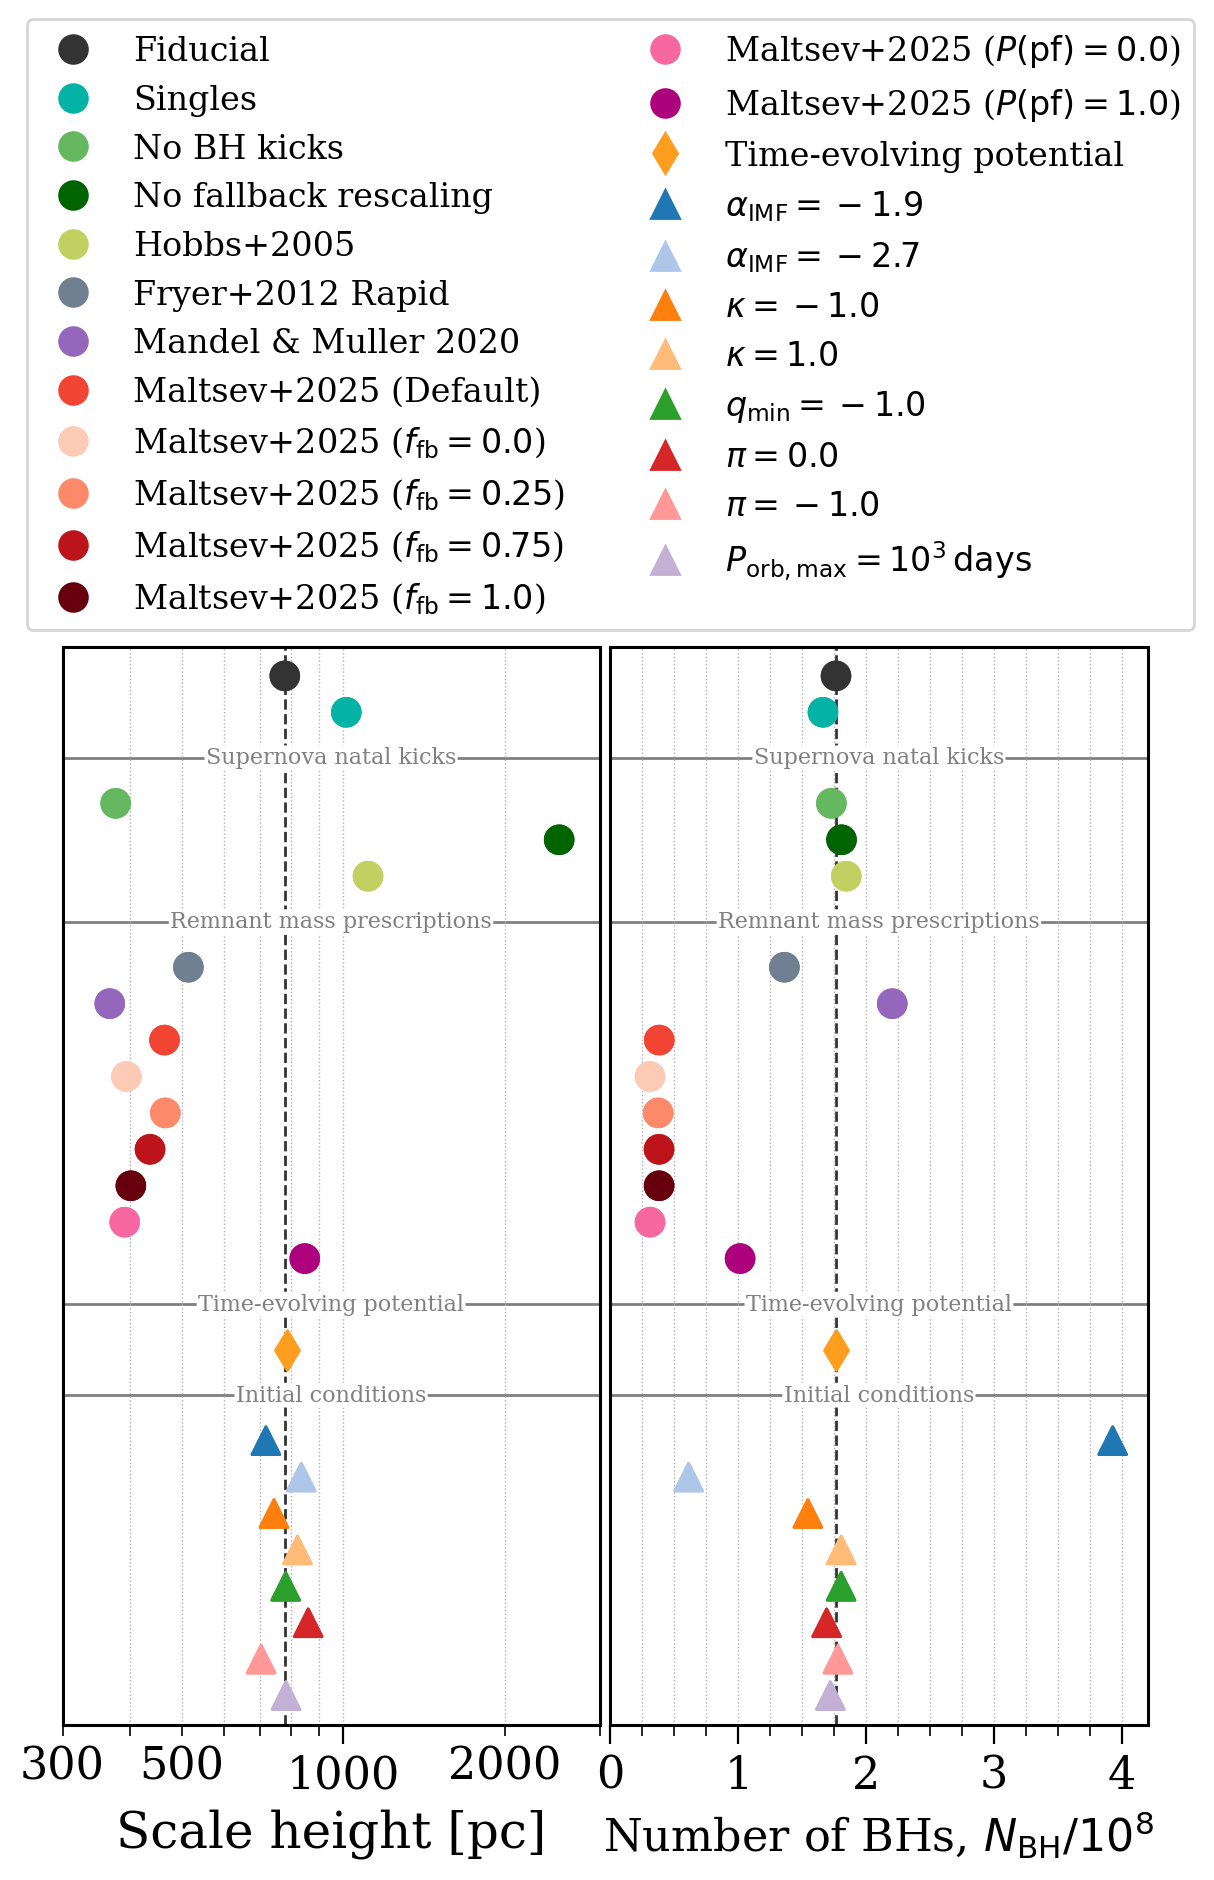

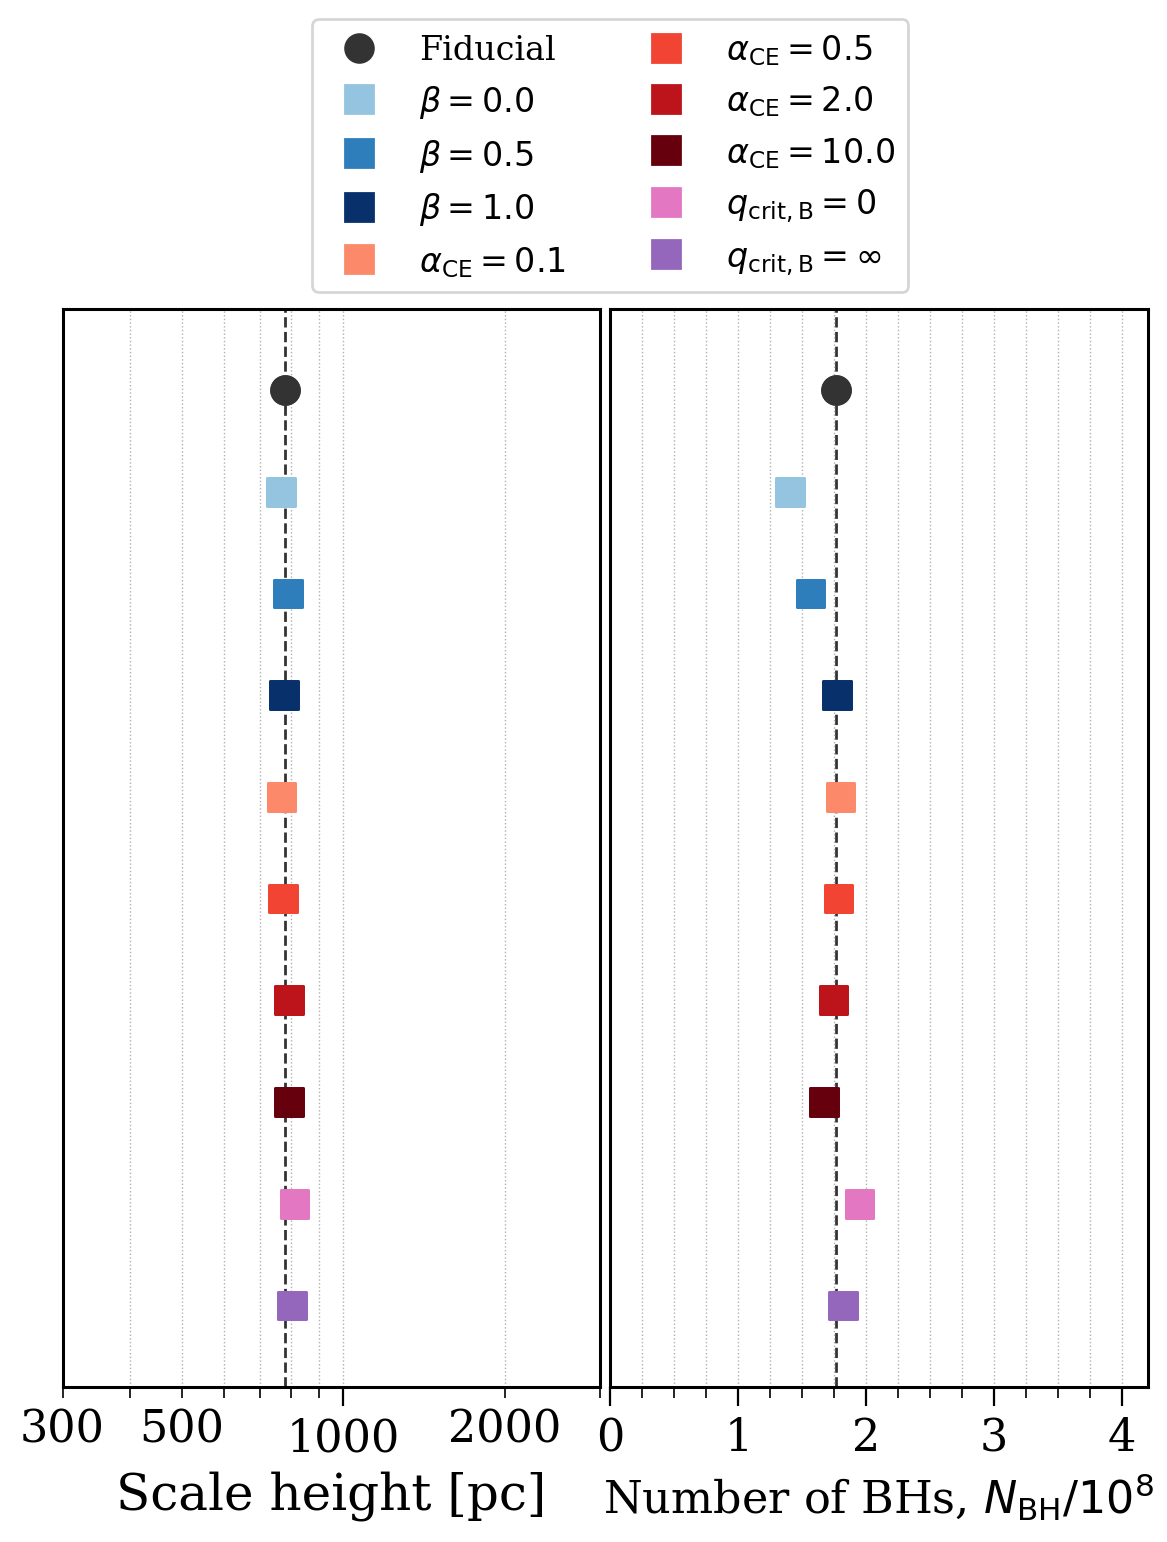

In [355]:
for label_set, groups_to_show, save_file in zip([main_labels, mt_labels], [groups[:-1], []], ["bh_summary_stats", "bh_summary_stats_mt"]):
    fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharey=True)

    fig.subplots_adjust(wspace=0.02)

    summary_plot(label_set, col="$h_z$ (pc)", fig=fig, ax=axes[0], show=False, legend_kwargs=None, groups_to_show=groups_to_show)
    summary_plot(label_set, col="$N_{\\rm BH} / 10^8$", fig=fig, ax=axes[1], show=False, legend_kwargs={"loc":"lower center", "fontsize":12, "ncol":2, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={"xscale": 'linear'}, groups_to_show=groups_to_show)

    label_these = [300, 500, 1000, 2000]
    formatter = mticker.FuncFormatter(lambda x, pos: f'{int(x)}' if x in label_these else '')
    axes[0].xaxis.set_minor_formatter(formatter)
    axes[0].xaxis.set_major_formatter(formatter)

    axes[0].set_xlabel("Scale height [pc]", fontsize=18)

    axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
    axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
    axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.25))

    axes[0].set_xlim(300, 3000)
    axes[1].set_xlim(0, 4.2)

    plt.savefig(f"../plots/{save_file}.pdf", format='pdf', bbox_inches='tight')

    plt.show()

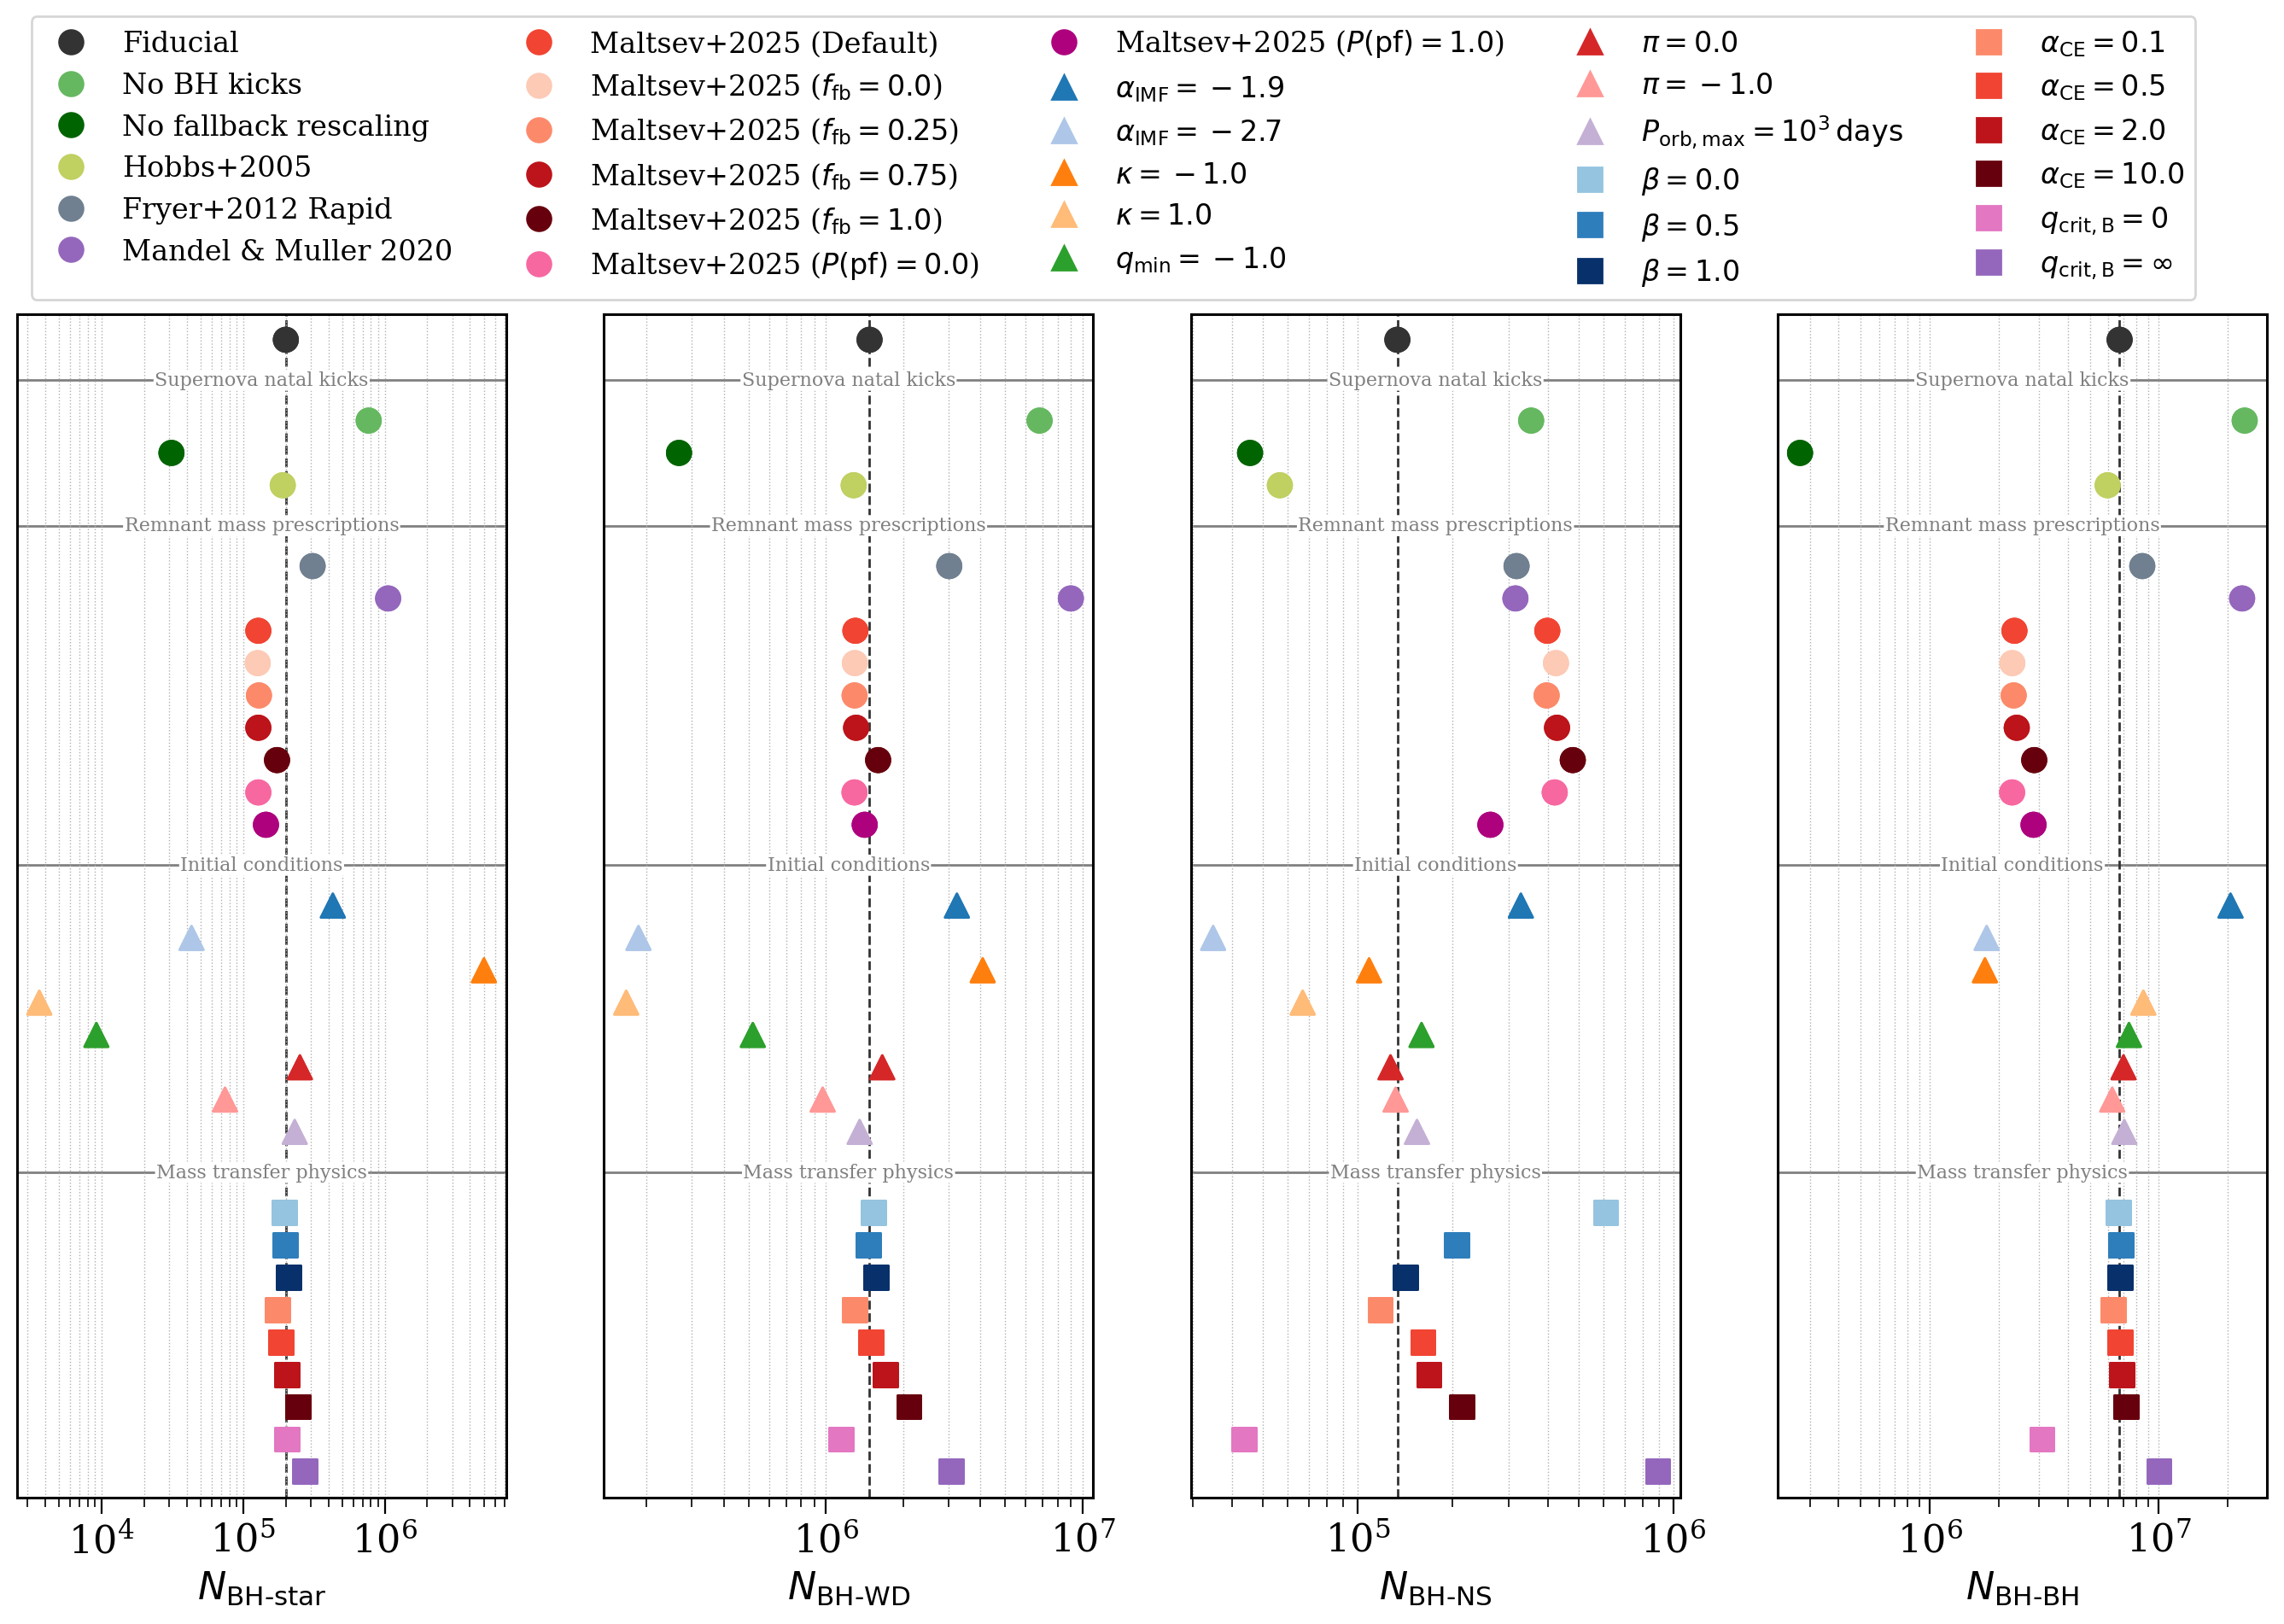

In [356]:
reload(constants)

fig, axes = plt.subplots(1, 4, figsize=(17, 9), sharey=True)

# main labels without the 2nd entry
main_labels_no_singles = [label for label in main_labels if (label != r"$f_{\rm bin} = 0.0$" and label != "Time-evolving potential")]
main_labels_no_singles += [label for label in mt_labels if label != r"$f_{\rm bin} = 1.0$"]
labels_inds = np.array([labels.index(label) for label in main_labels_no_singles])

for col, ax, norm in zip(
    [r"$N_{\rm BH\text{-}star} / 10^4$", r"$N_{\rm BH\text{-}WD} / 10^5$", r"$N_{\rm BH\text{-}NS} / 10^5$", r"$N_{\rm BH\text{-}BH} / 10^6$"],
    axes,
    [1e4, 1e5, 1e5, 1e6]
):

    summary_plot(main_labels_no_singles, col=col, fig=fig, ax=ax, show=False,
                 legend_kwargs={"loc":"lower left", "fontsize":12, "ncol":5, "bbox_to_anchor":(0.0, 1.0)} if ax == axes[0] else None,
                 norm=norm, groups_to_show=[g for g in groups if g["title"] != "Time-evolving potential" and g["title"] != "Binary fraction"])

    ax.set_xlabel(col.split("/")[0] + "$", fontsize=16)


plt.savefig("../plots/bh_summary_stats_bound.pdf", format='pdf', bbox_inches='tight')

plt.show()

$f_{\rm bin} = 1.0$ 308


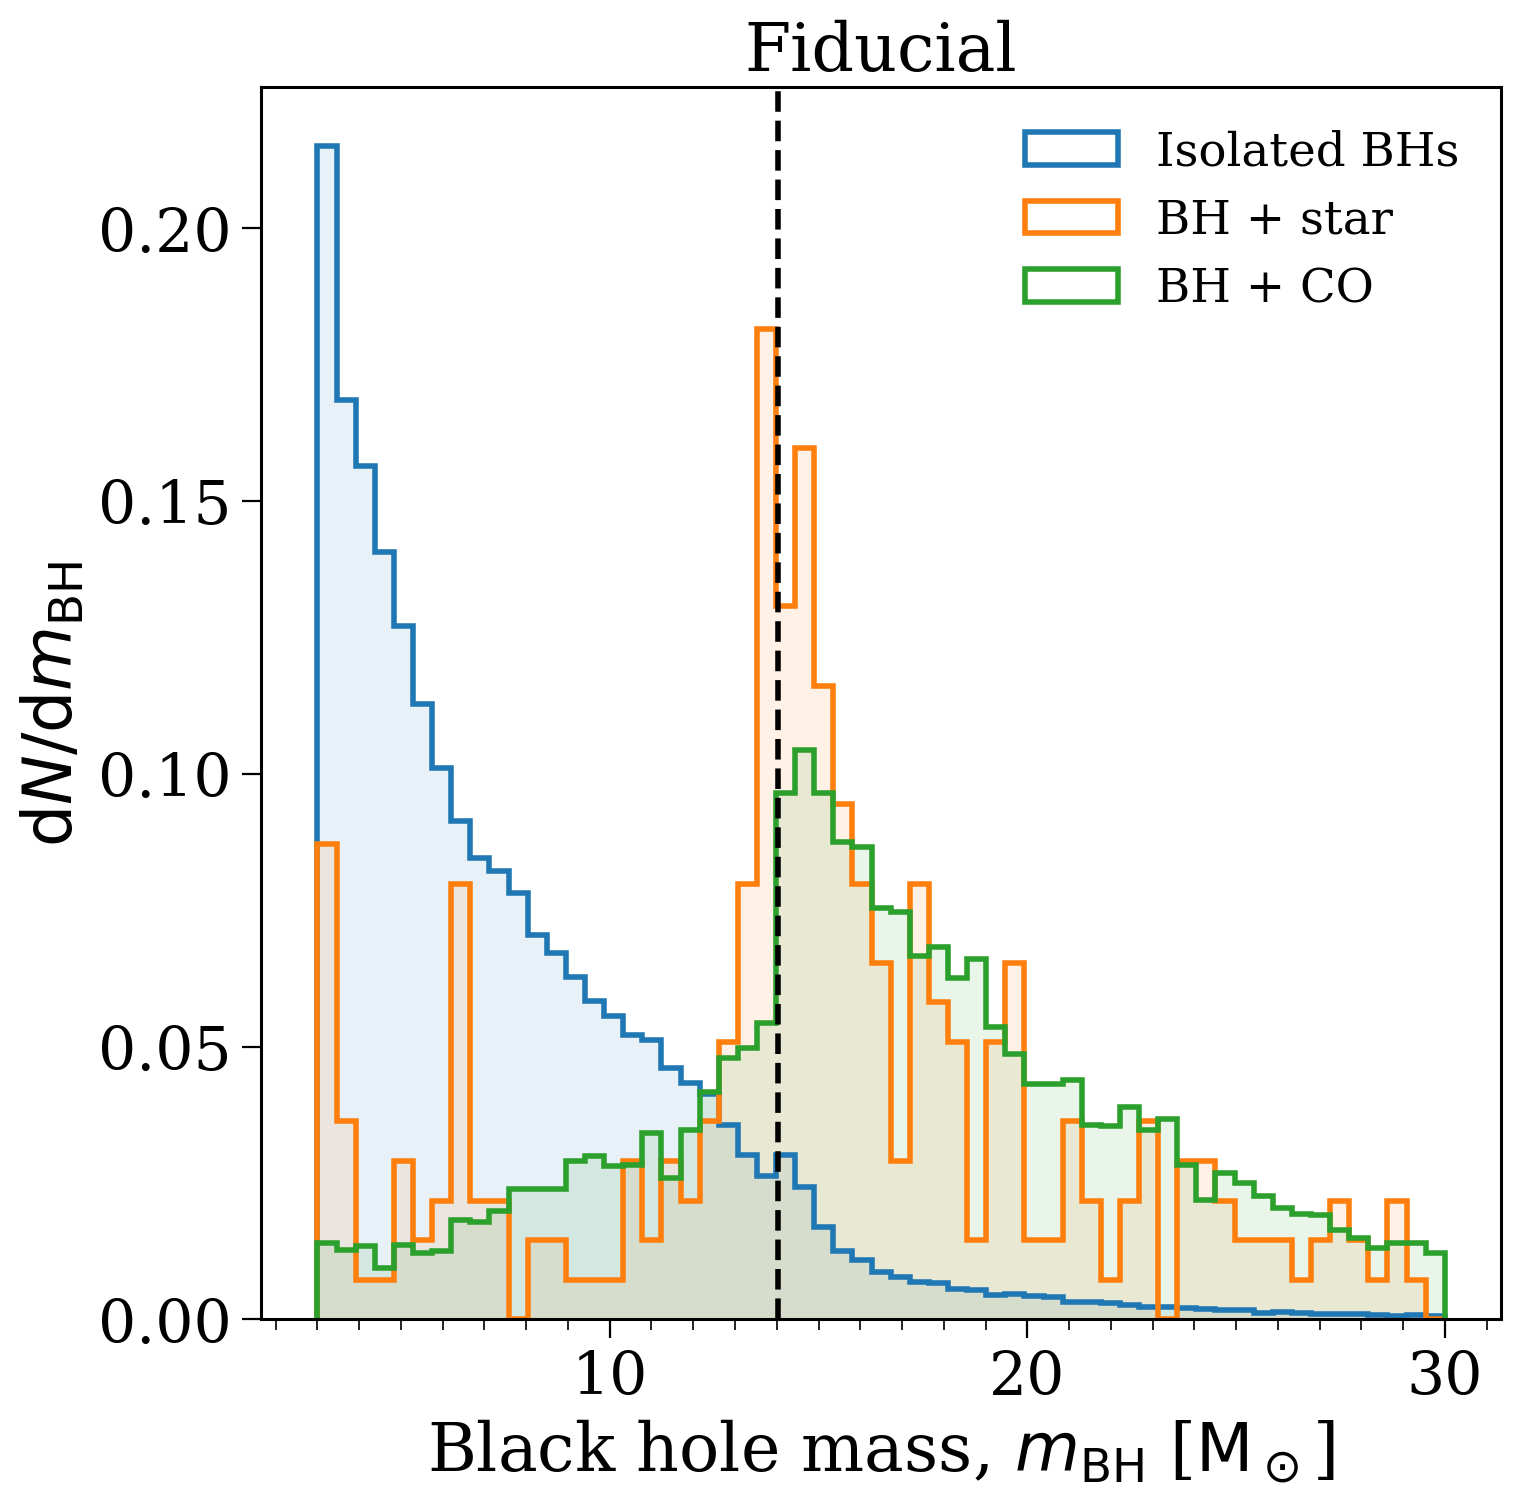

No BH kicks 1184


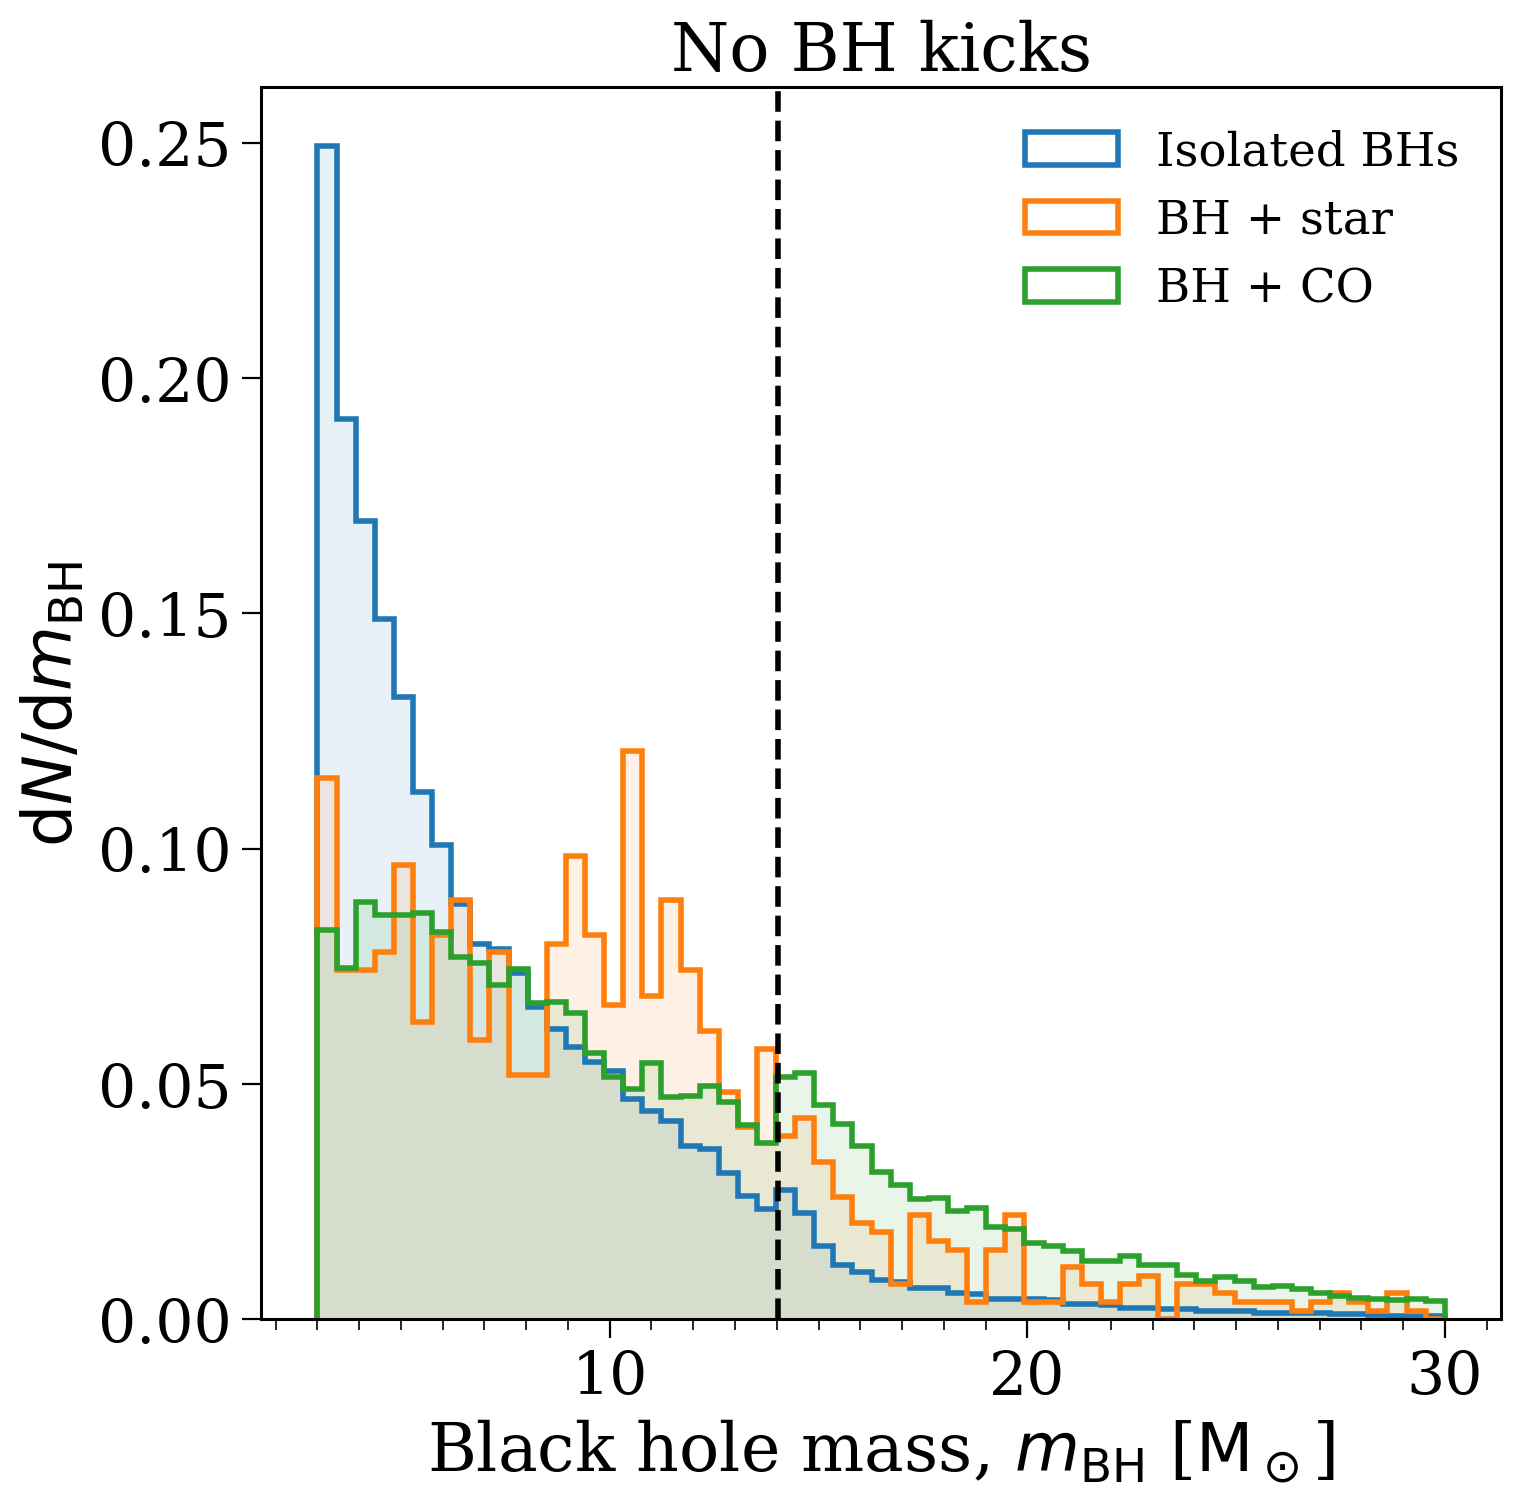

No fallback rescaling 48


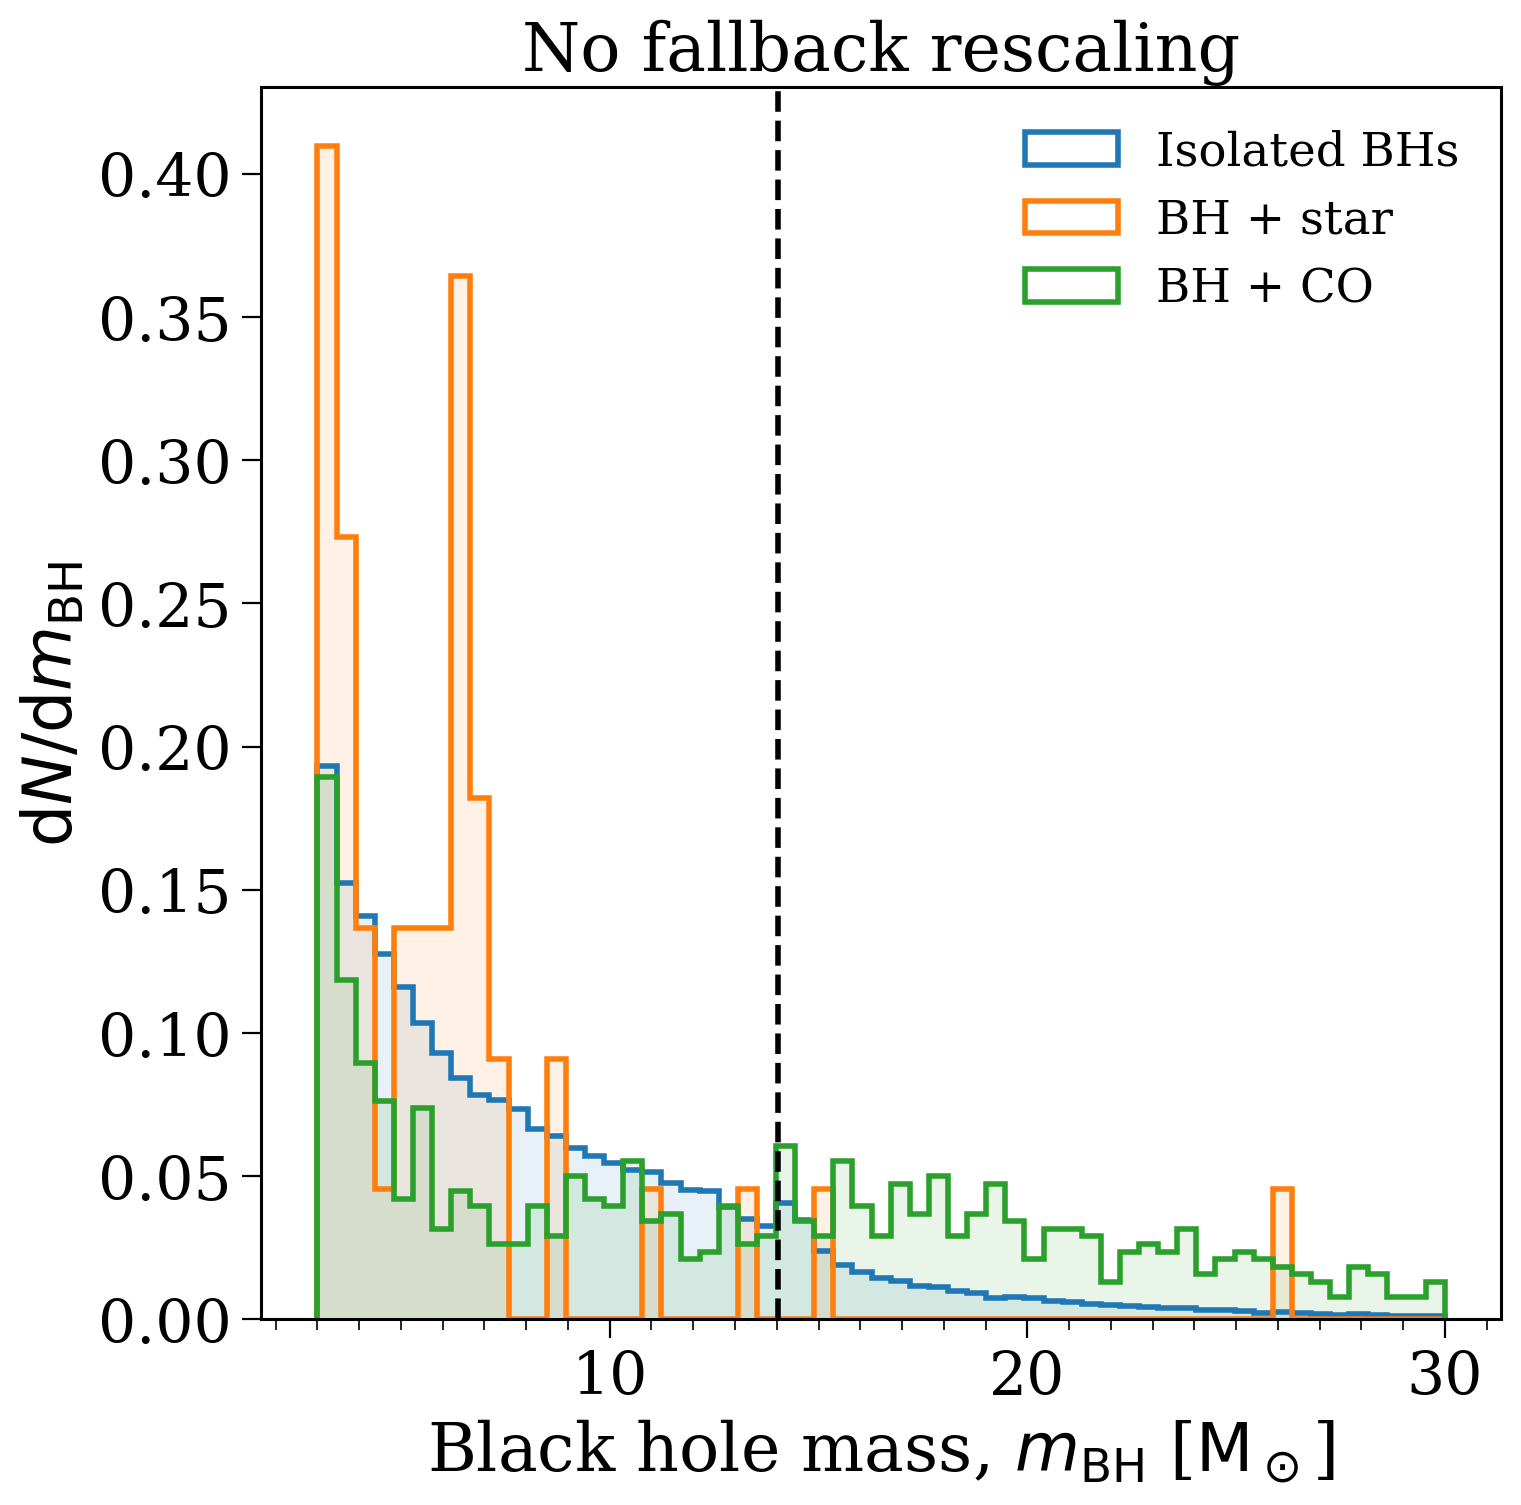

Hobbs+2005 293


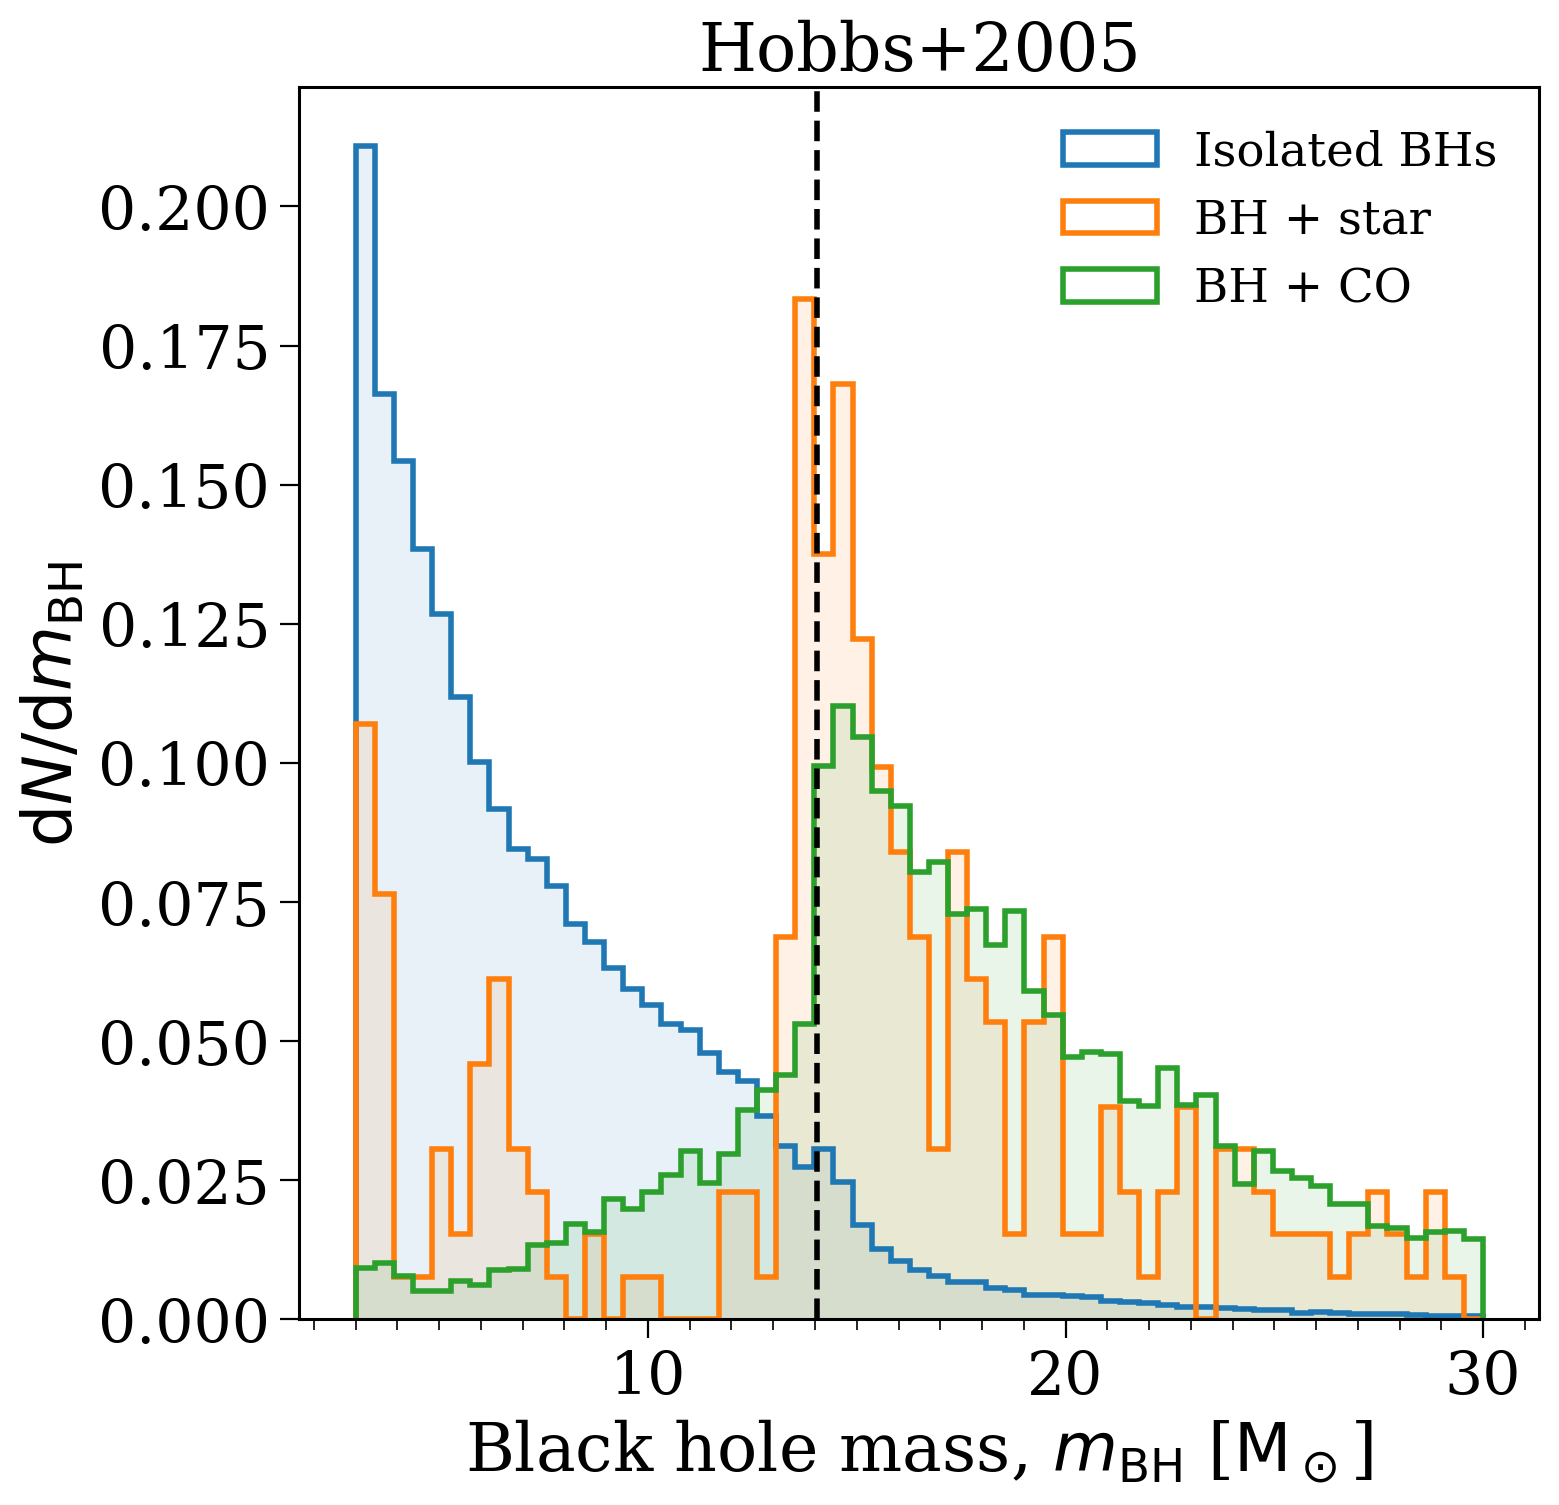

Fryer+2012 Rapid 476


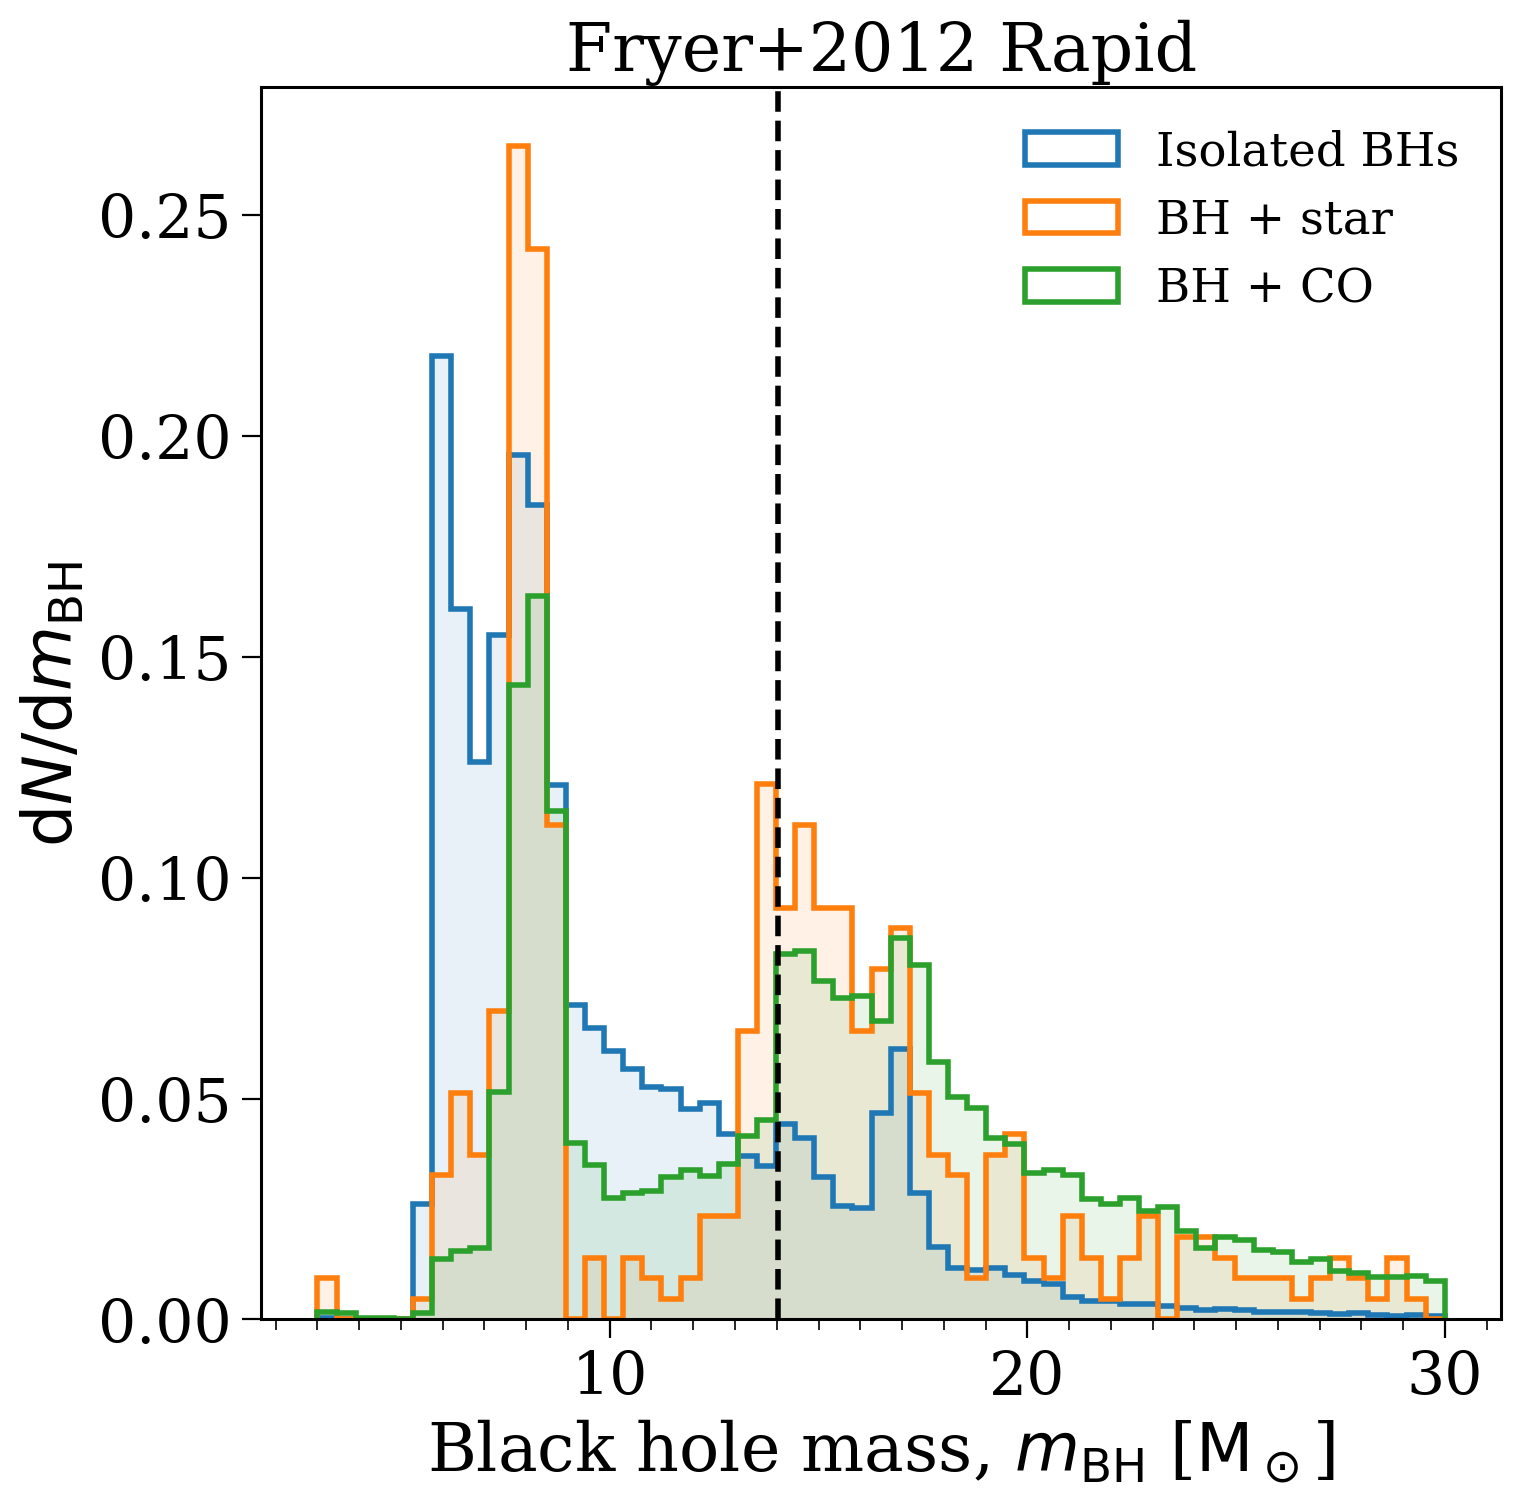

Mandel\&Muller2020 1624


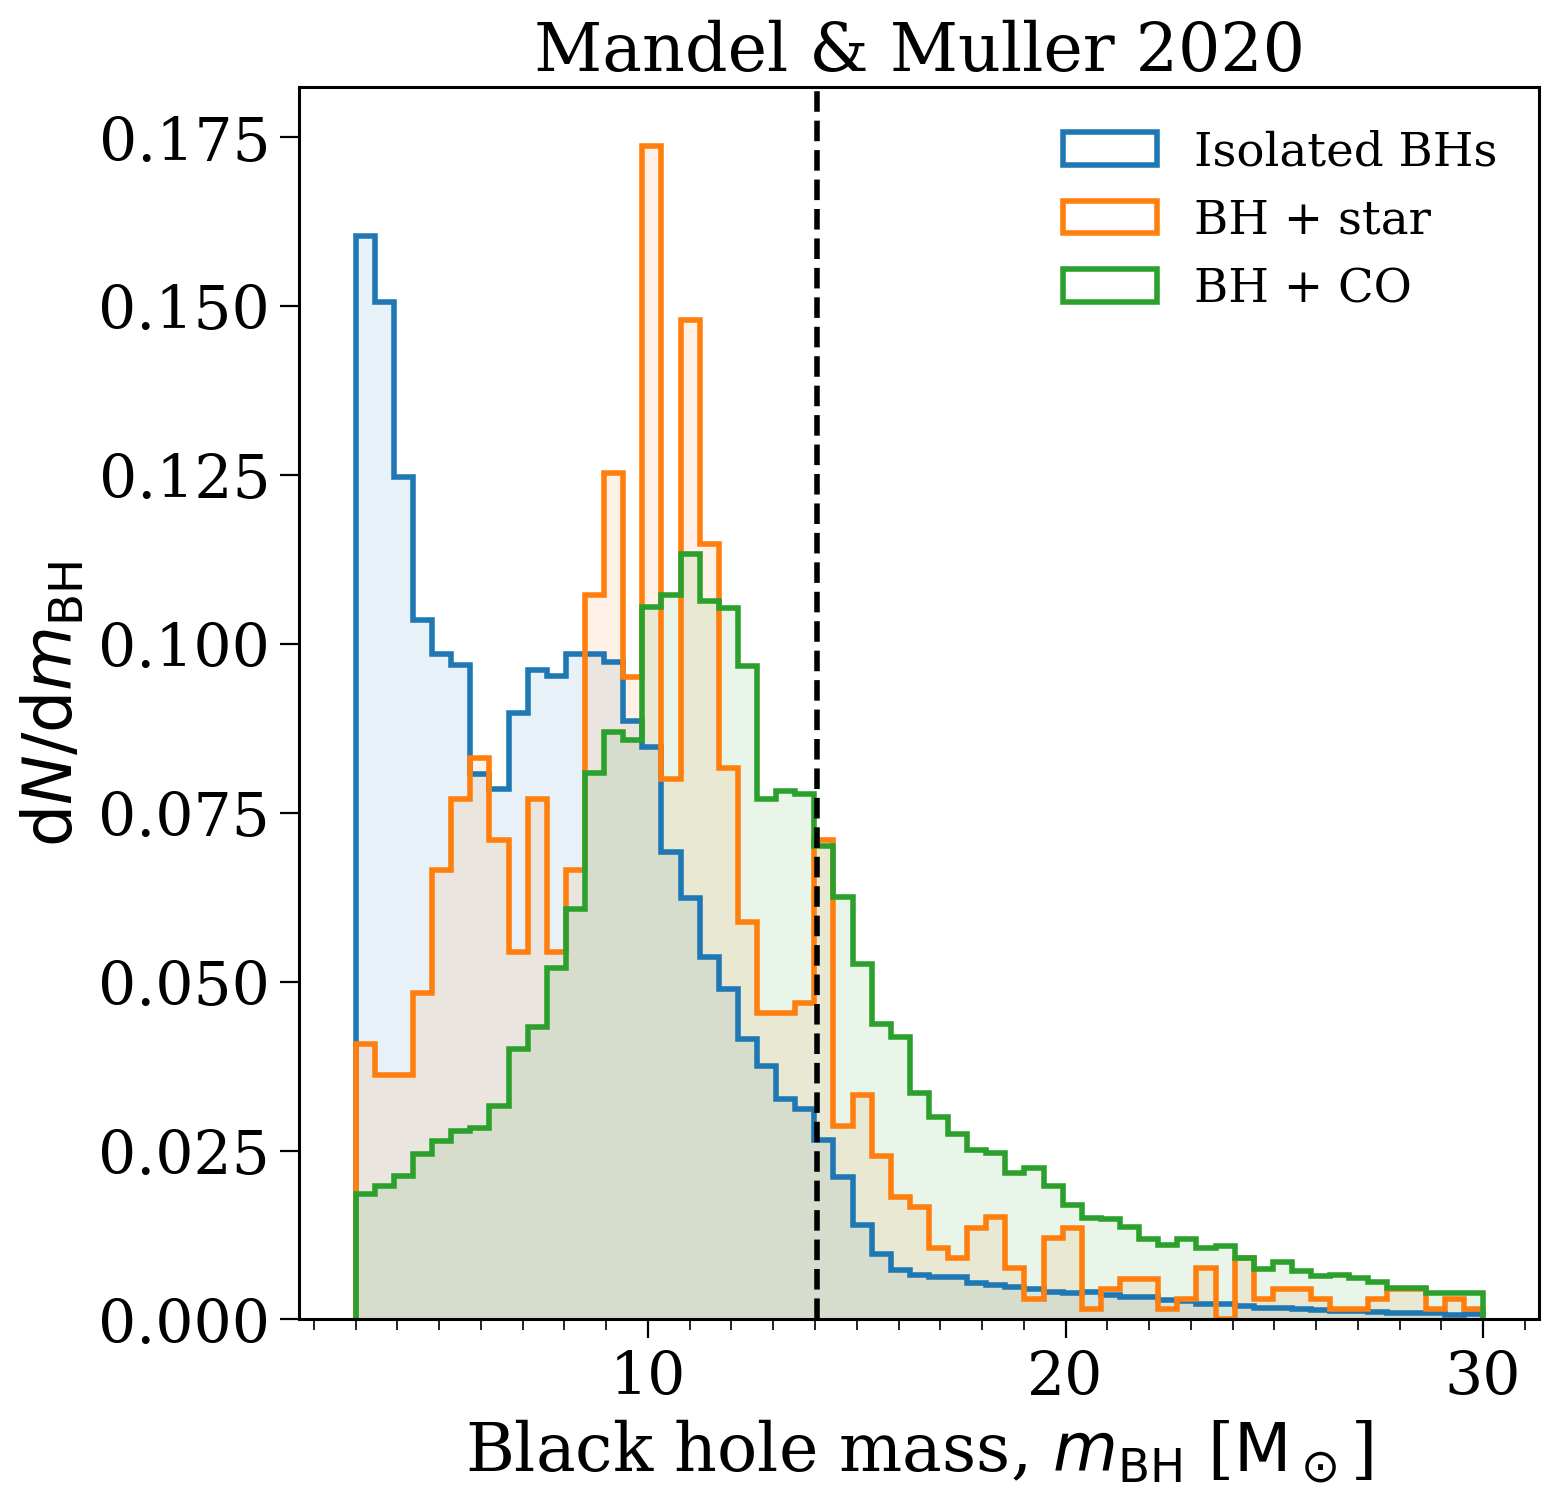

Maltsev+2025 197


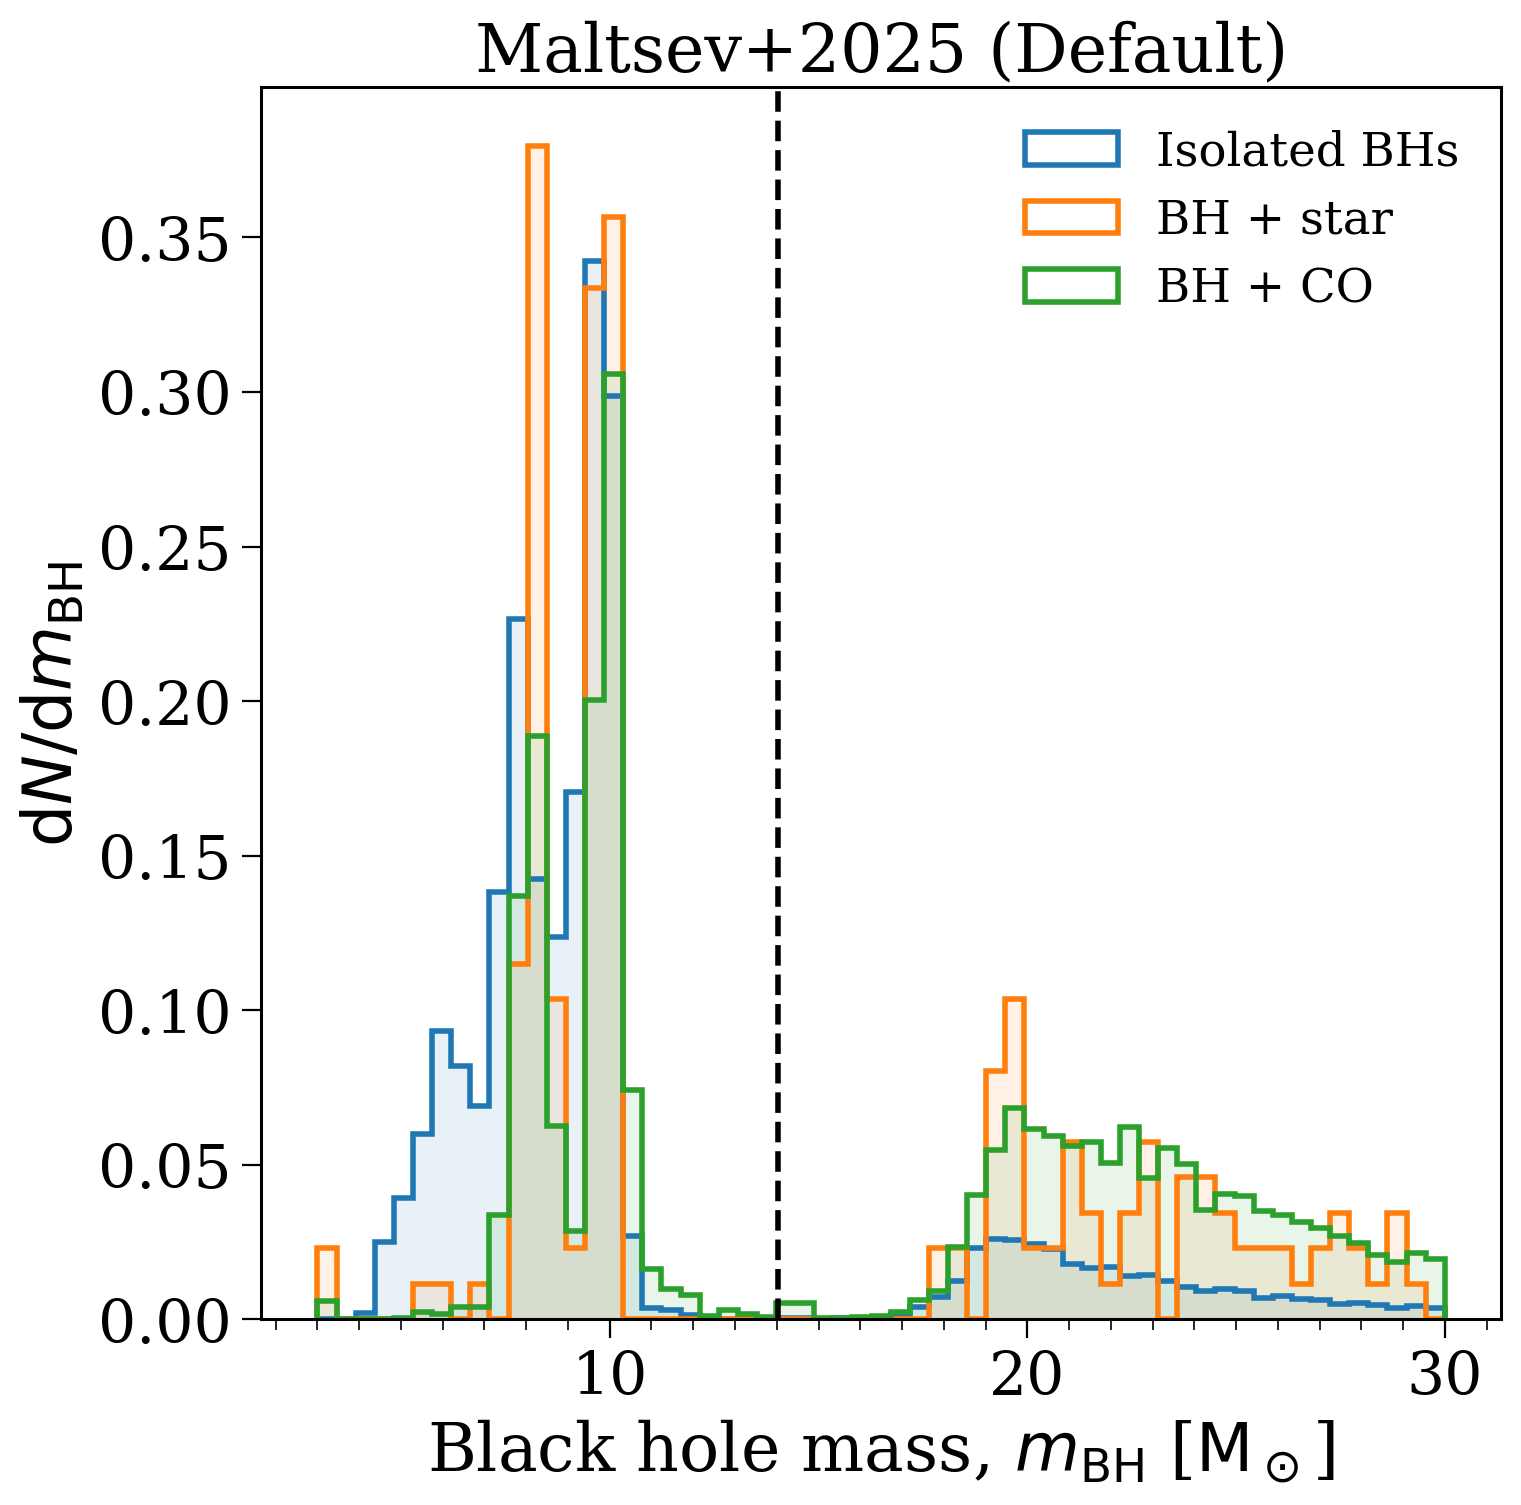

$f_{\rm fb} = 0.0$ 195


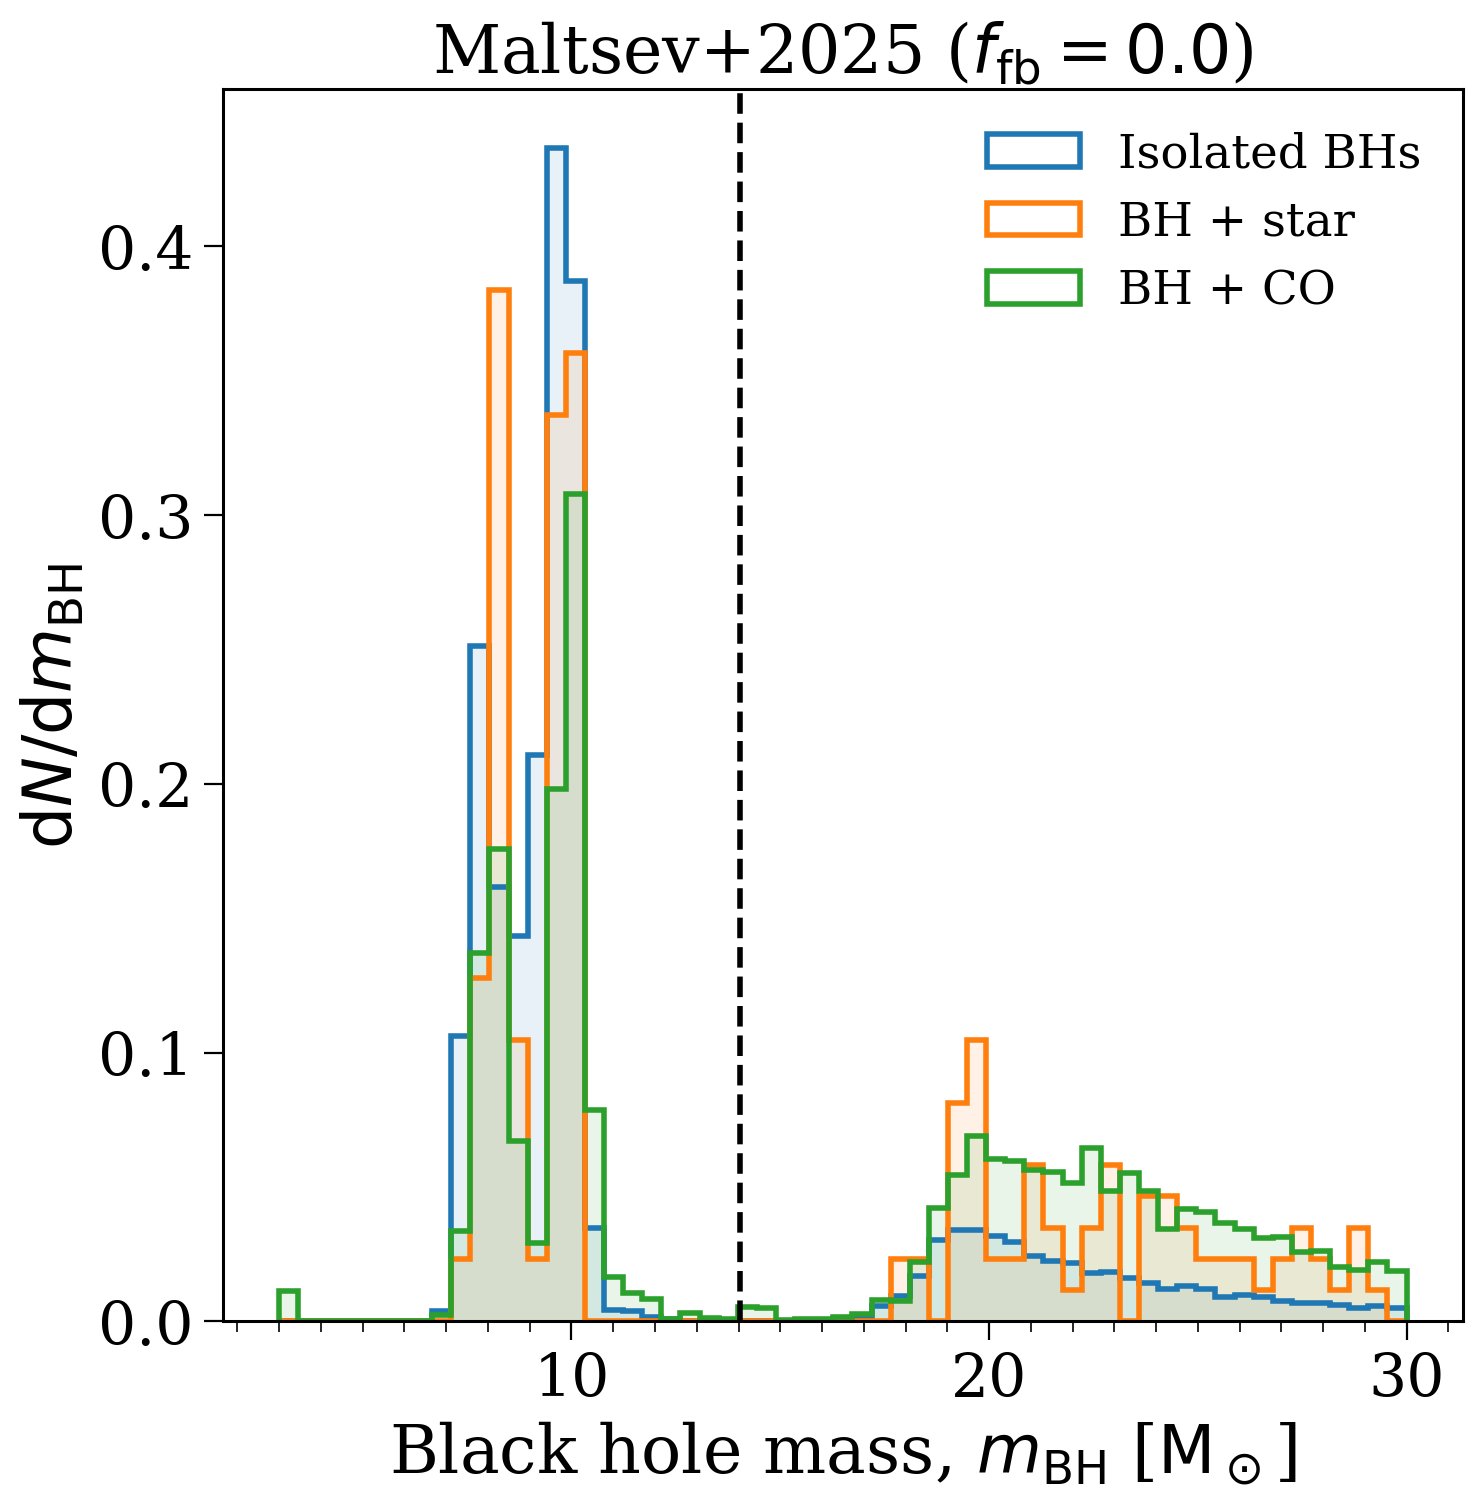

$f_{\rm fb} = 0.25$ 199


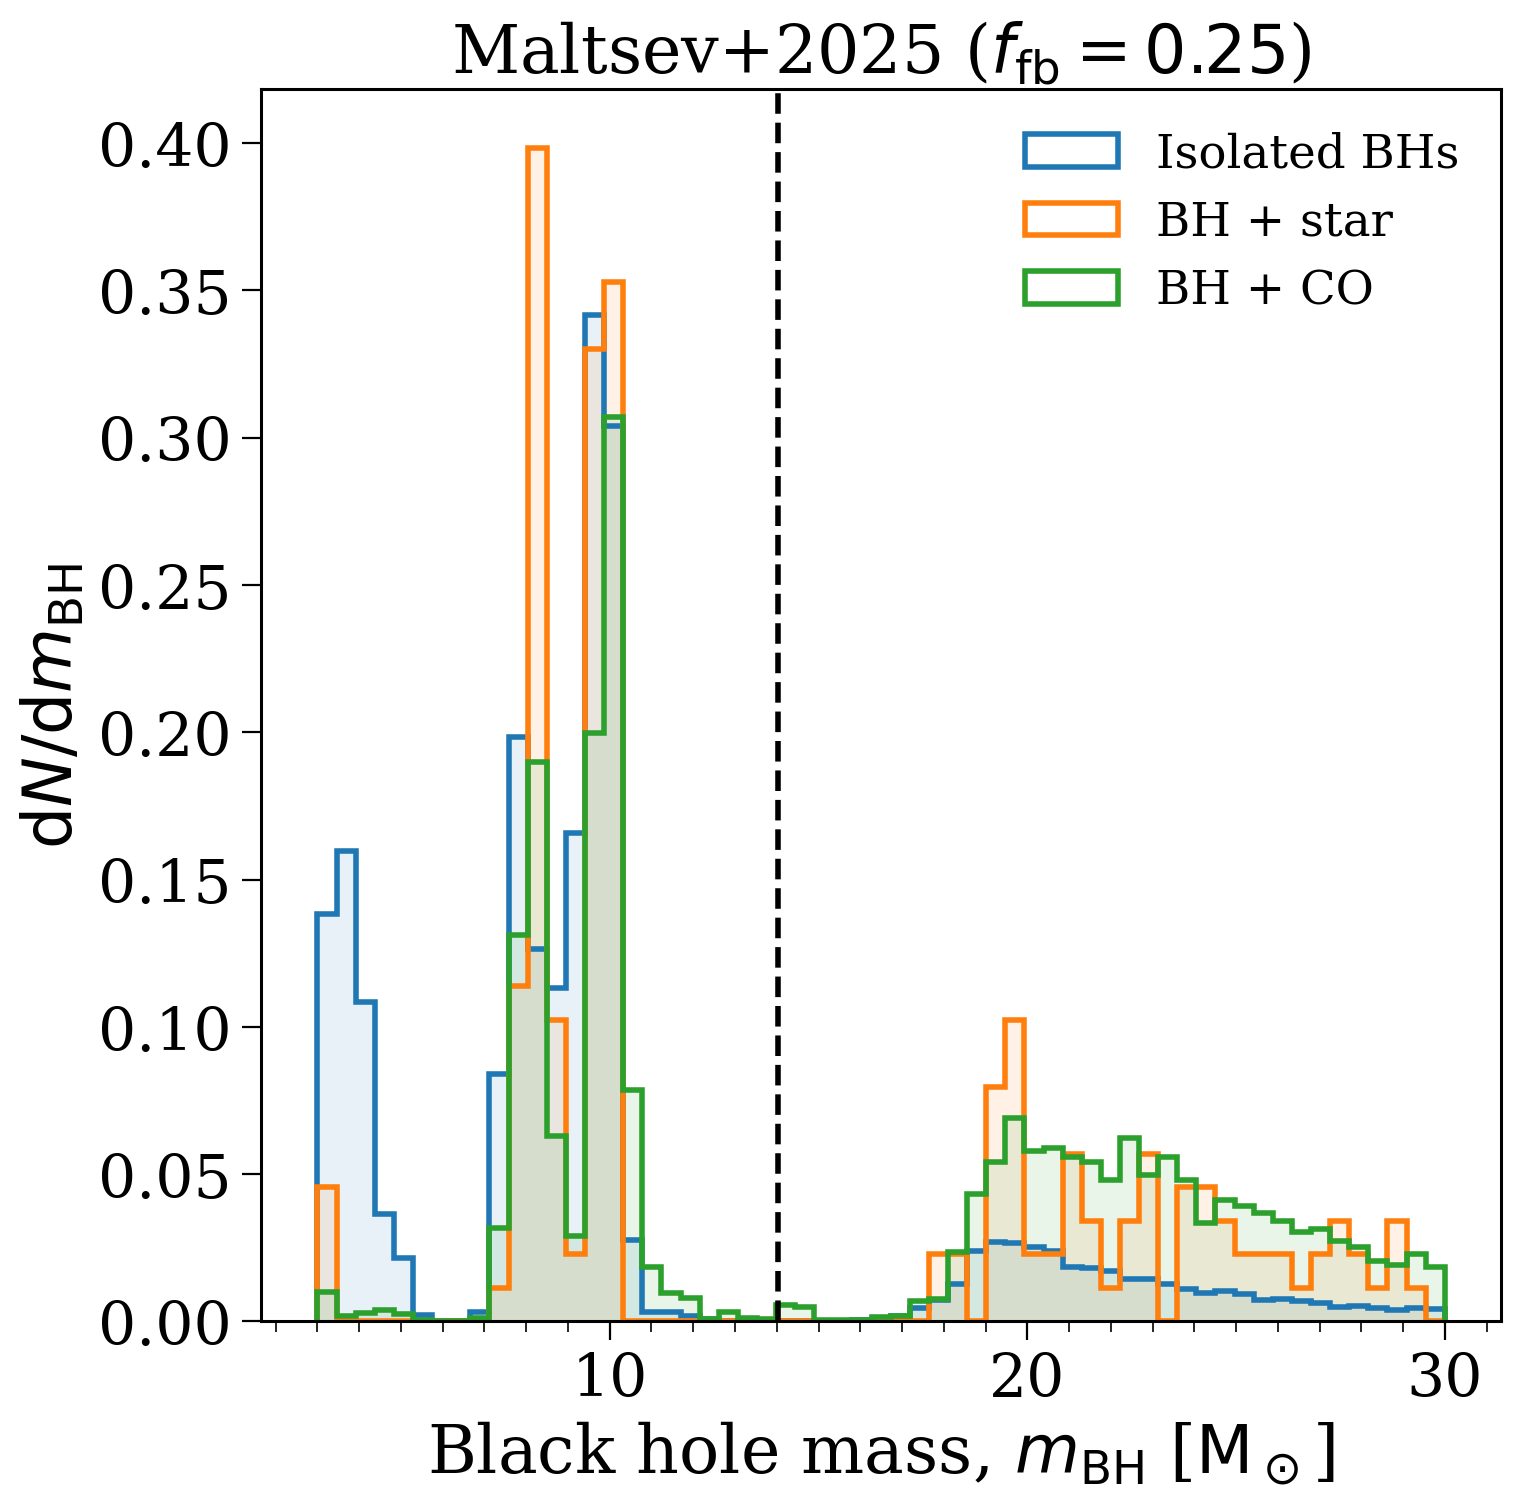

$f_{\rm fb} = 0.75$ 197


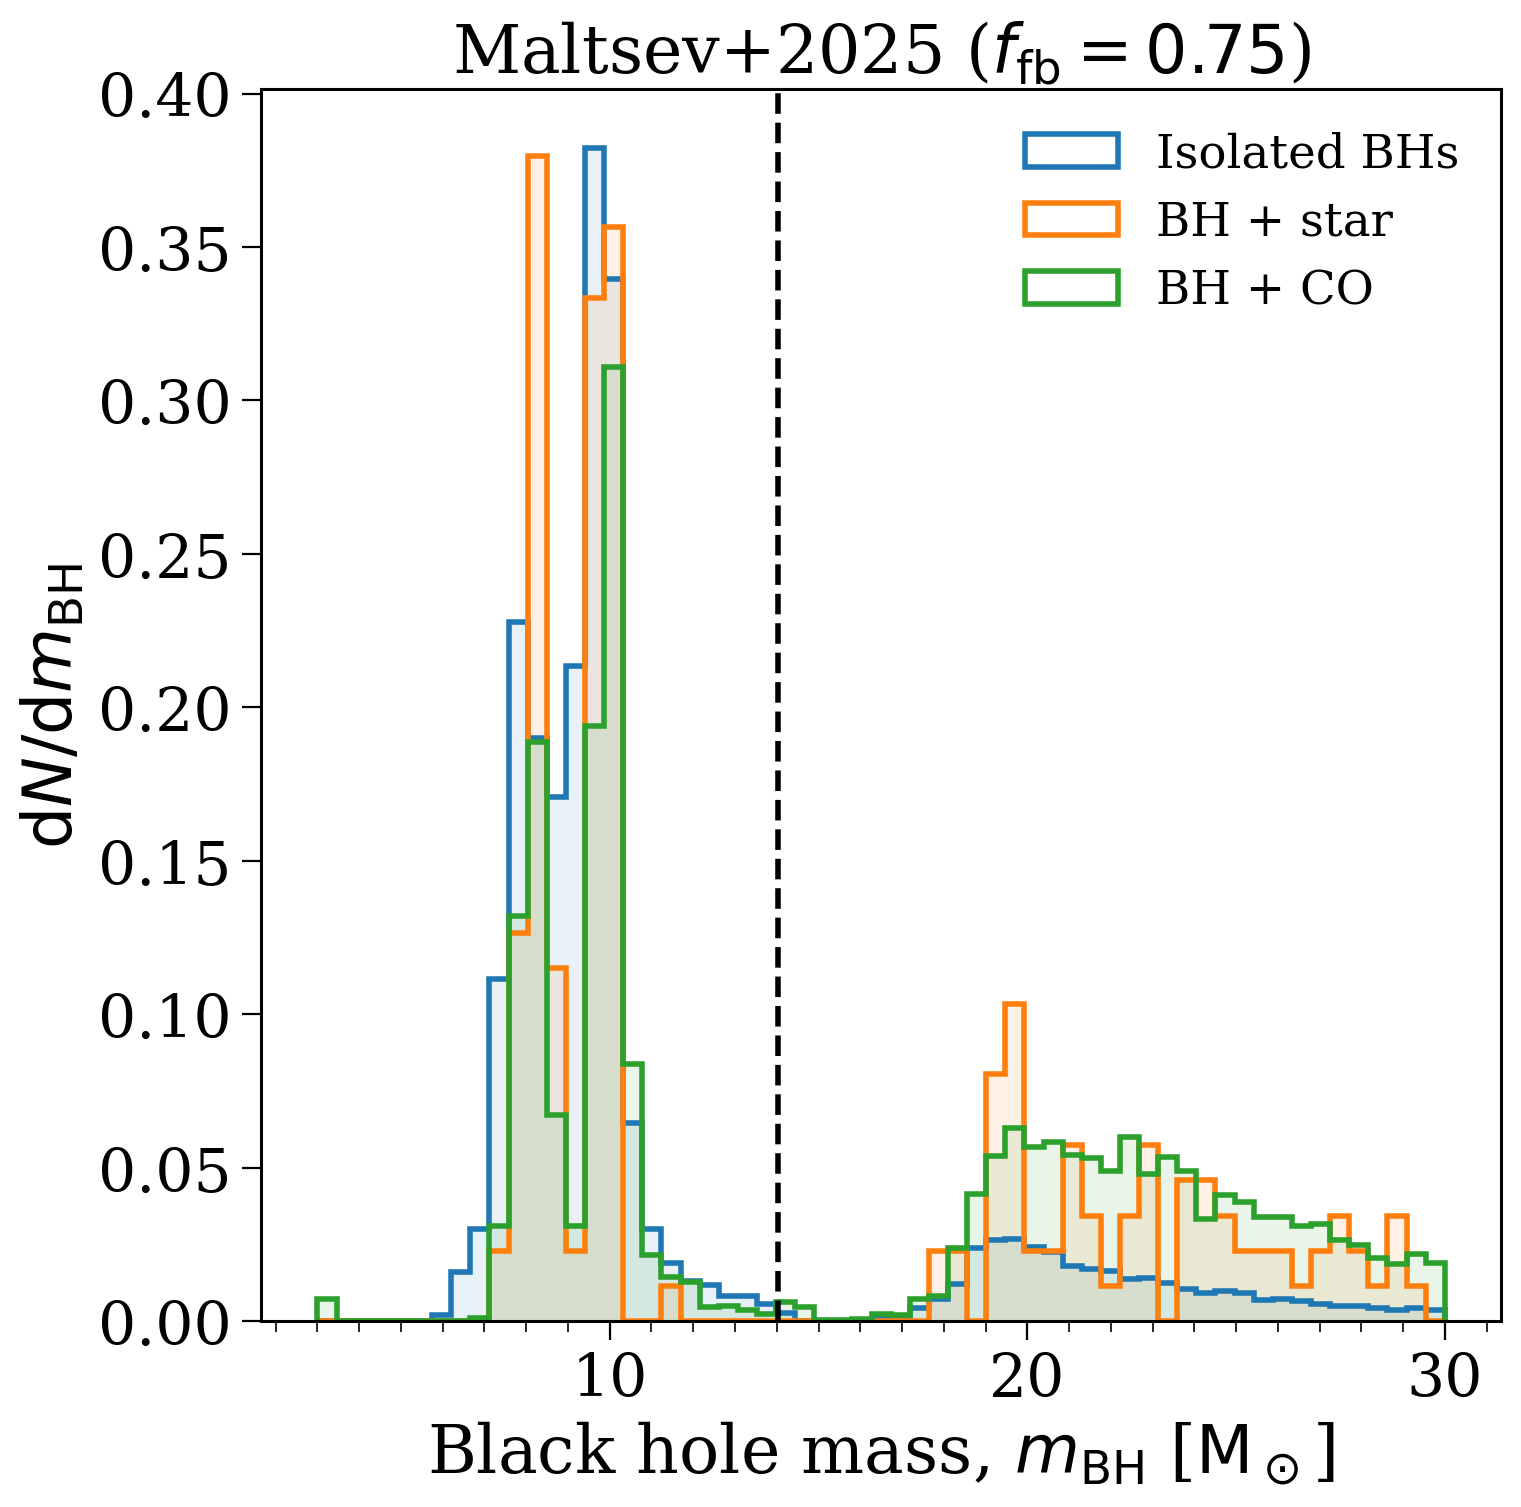

$f_{\rm fb} = 1.0$ 267


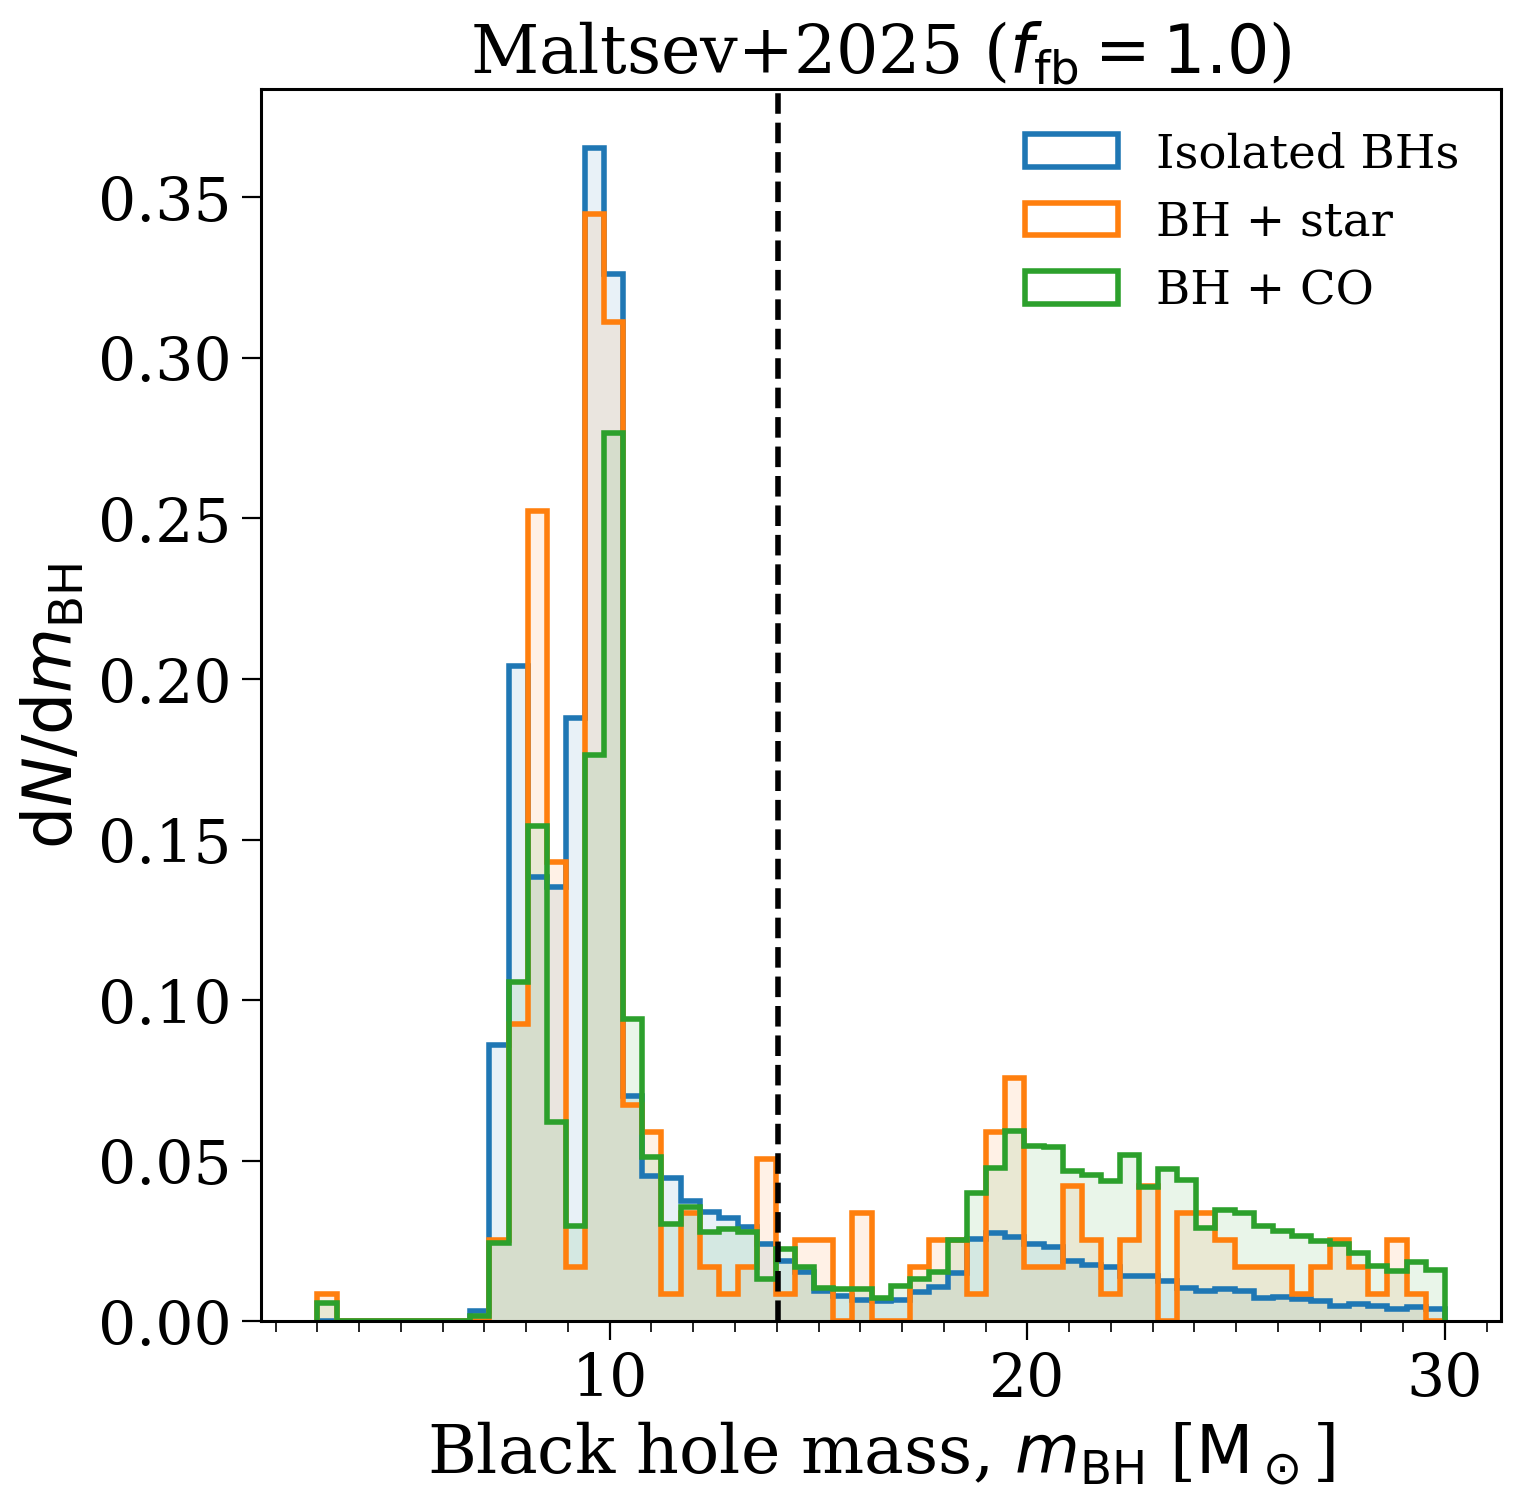

$P({\rm pf}) = 0.0$ 197


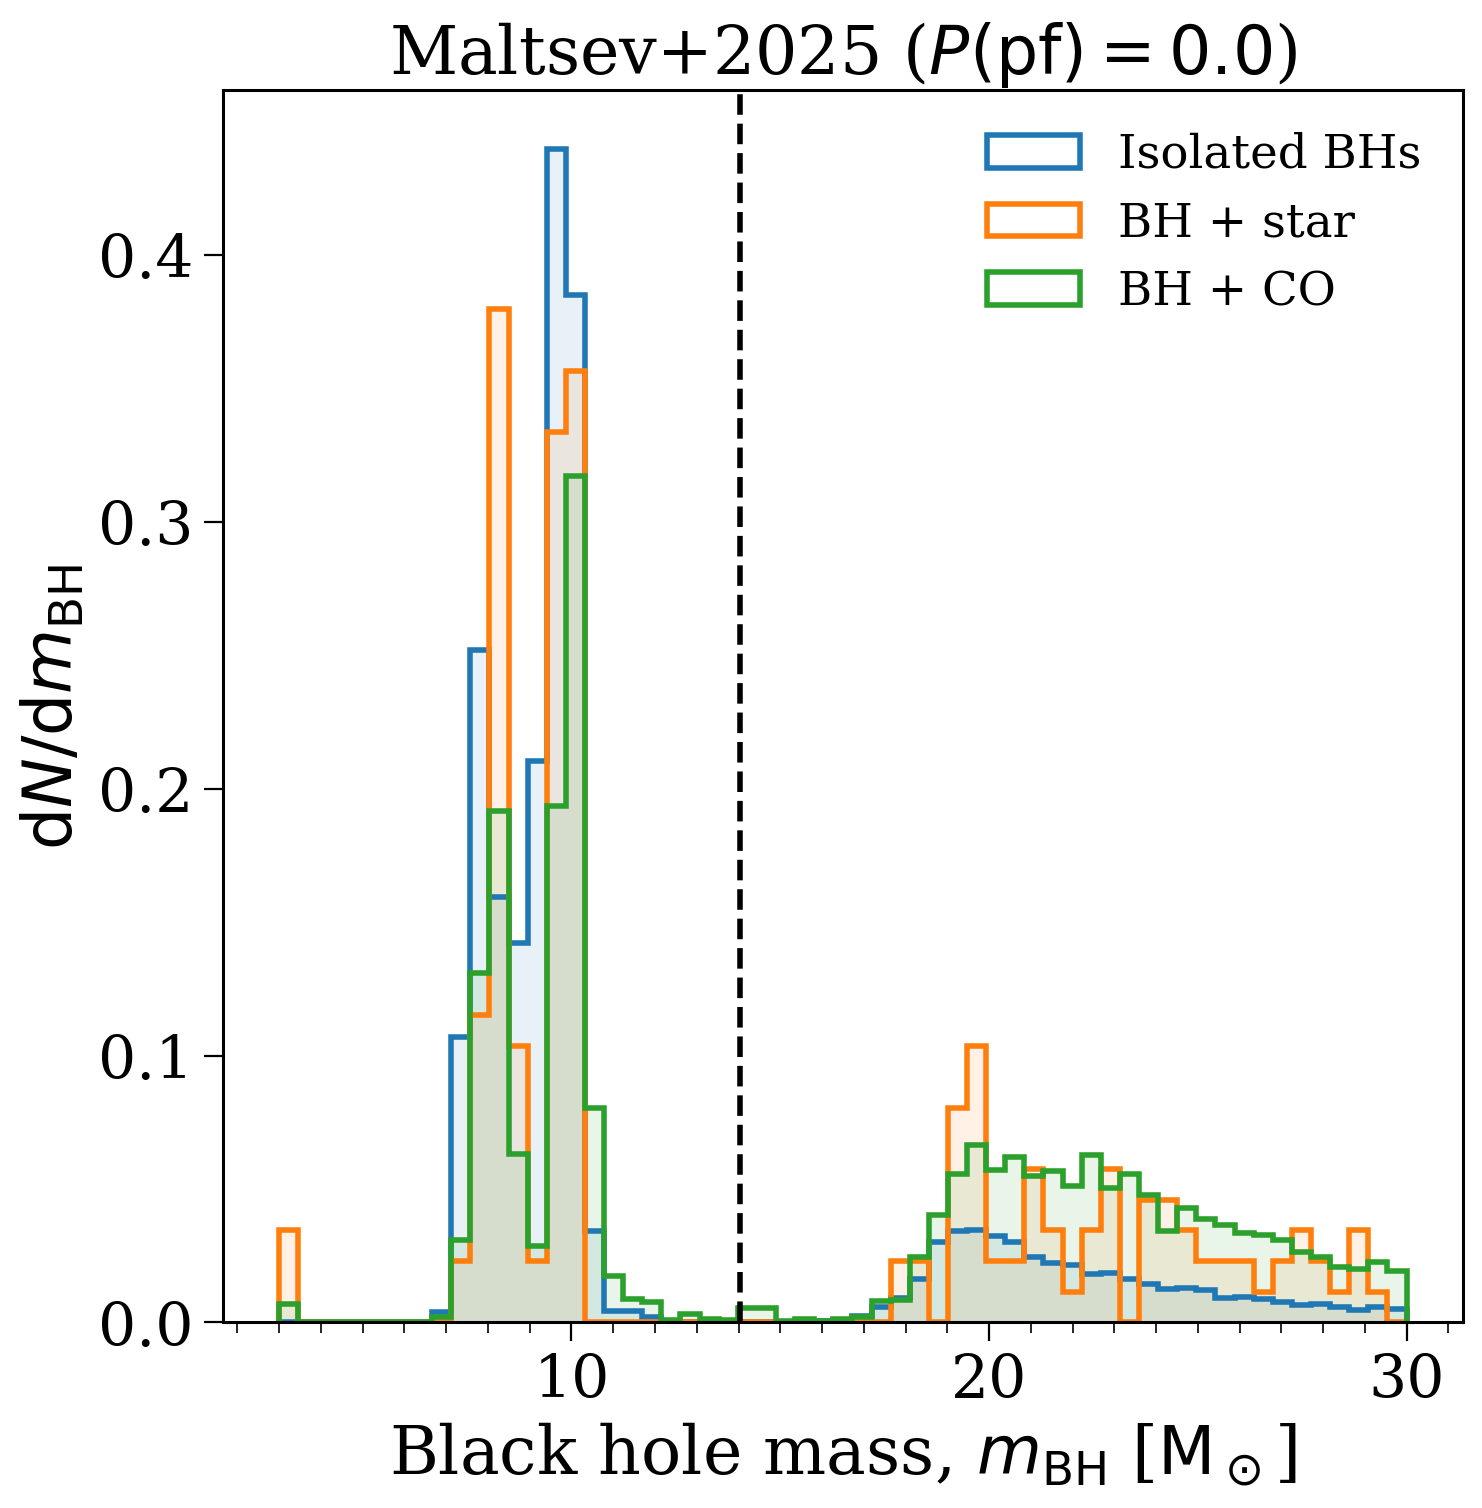

$P({\rm pf}) = 1.0$ 223


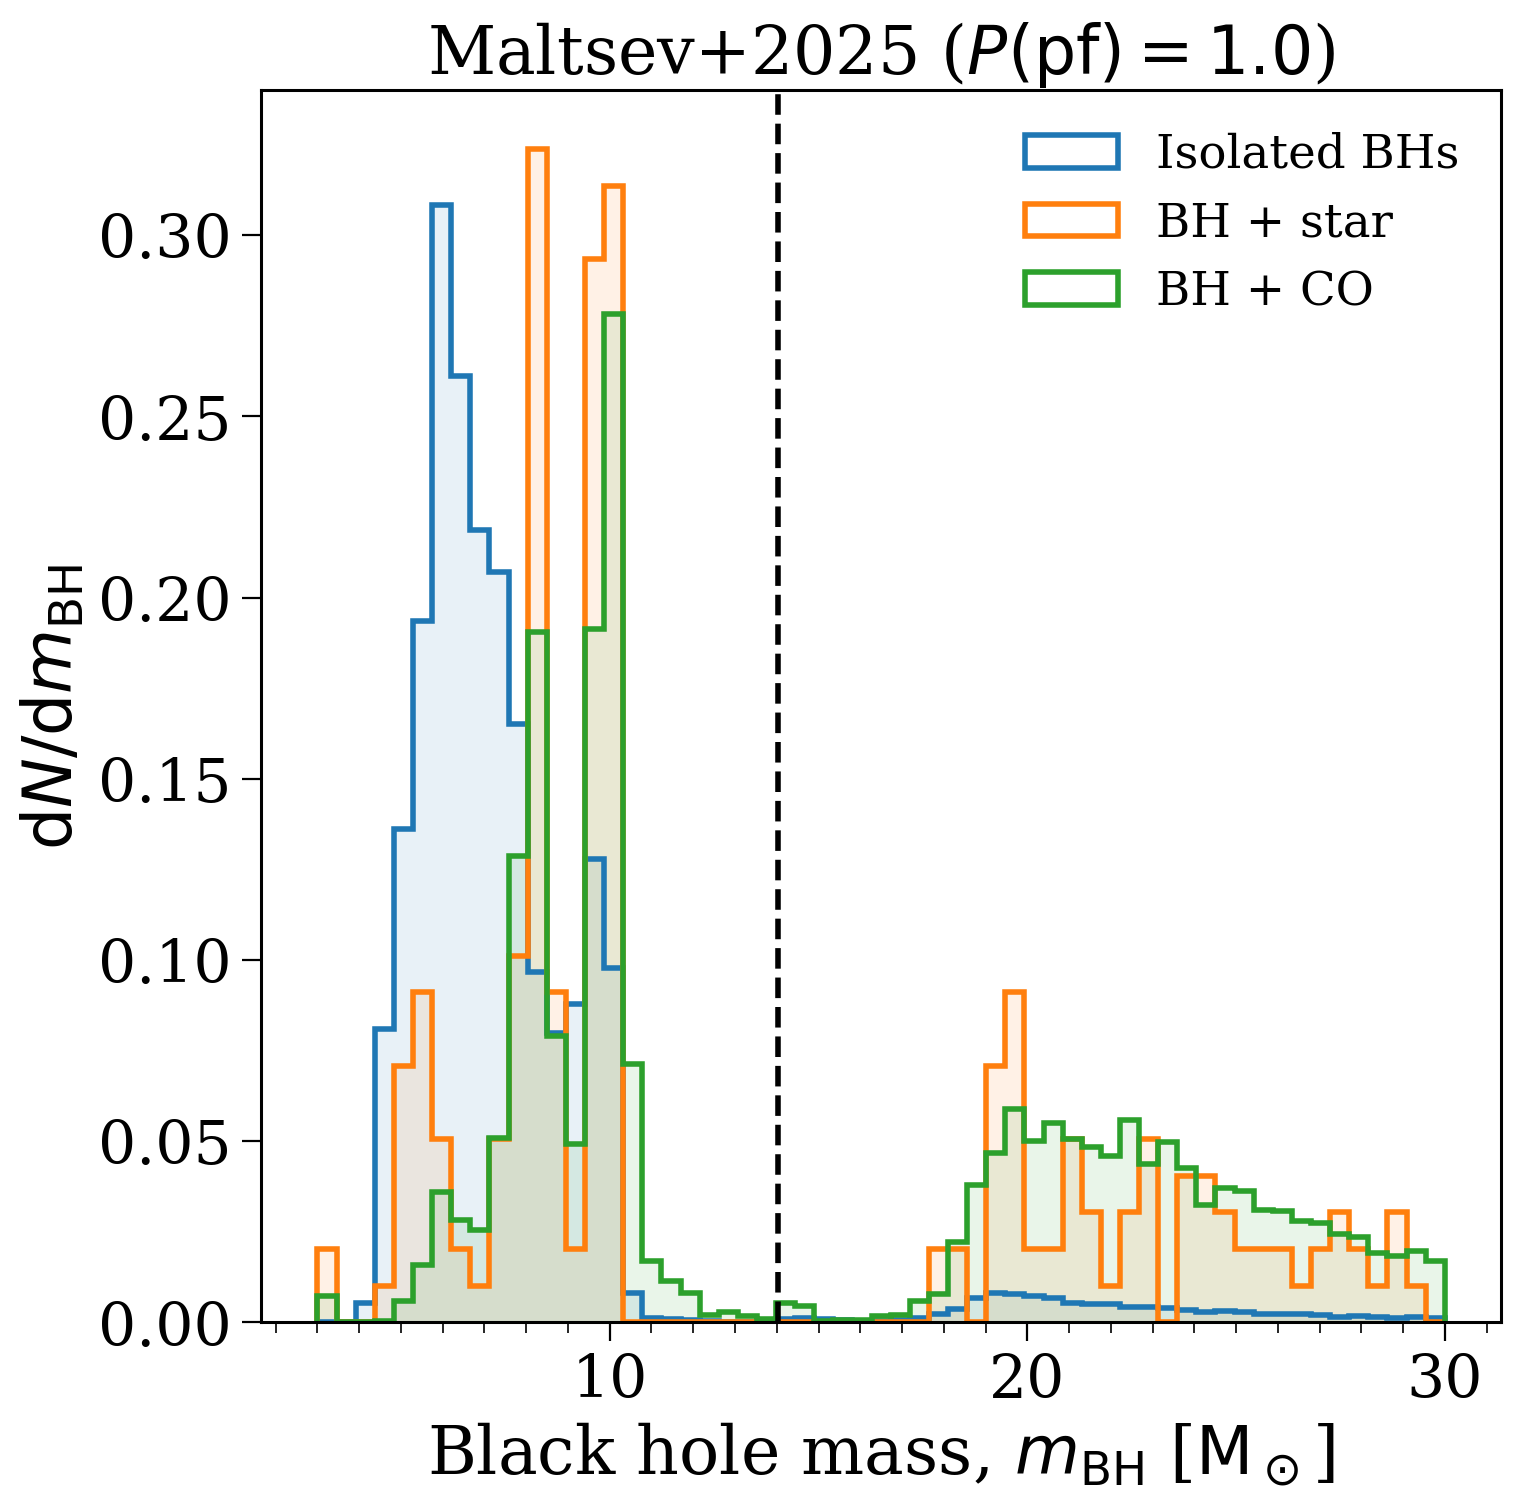

$\alpha_{\rm IMF} = -1.9$ 1141


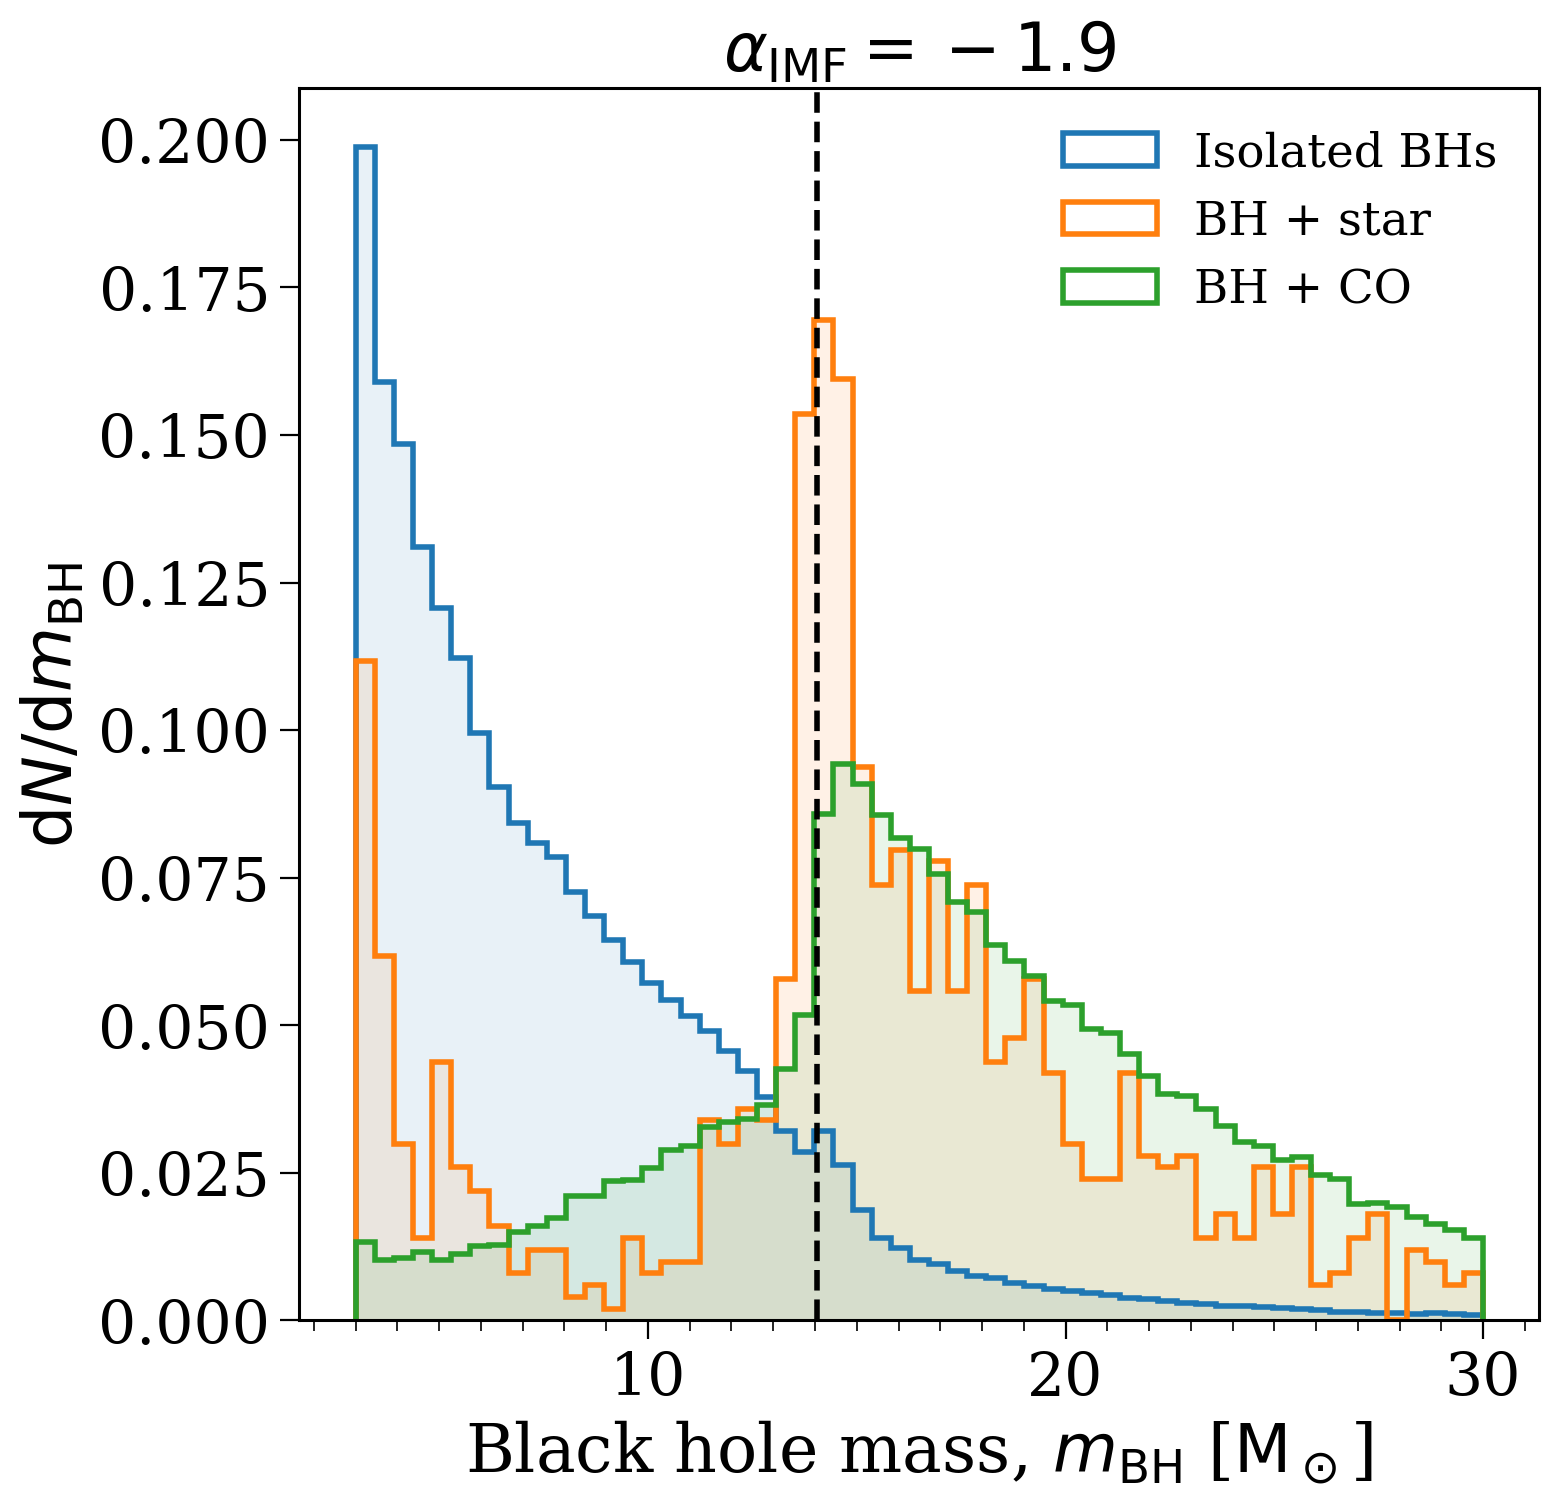

$\alpha_{\rm IMF} = -2.7$ 51


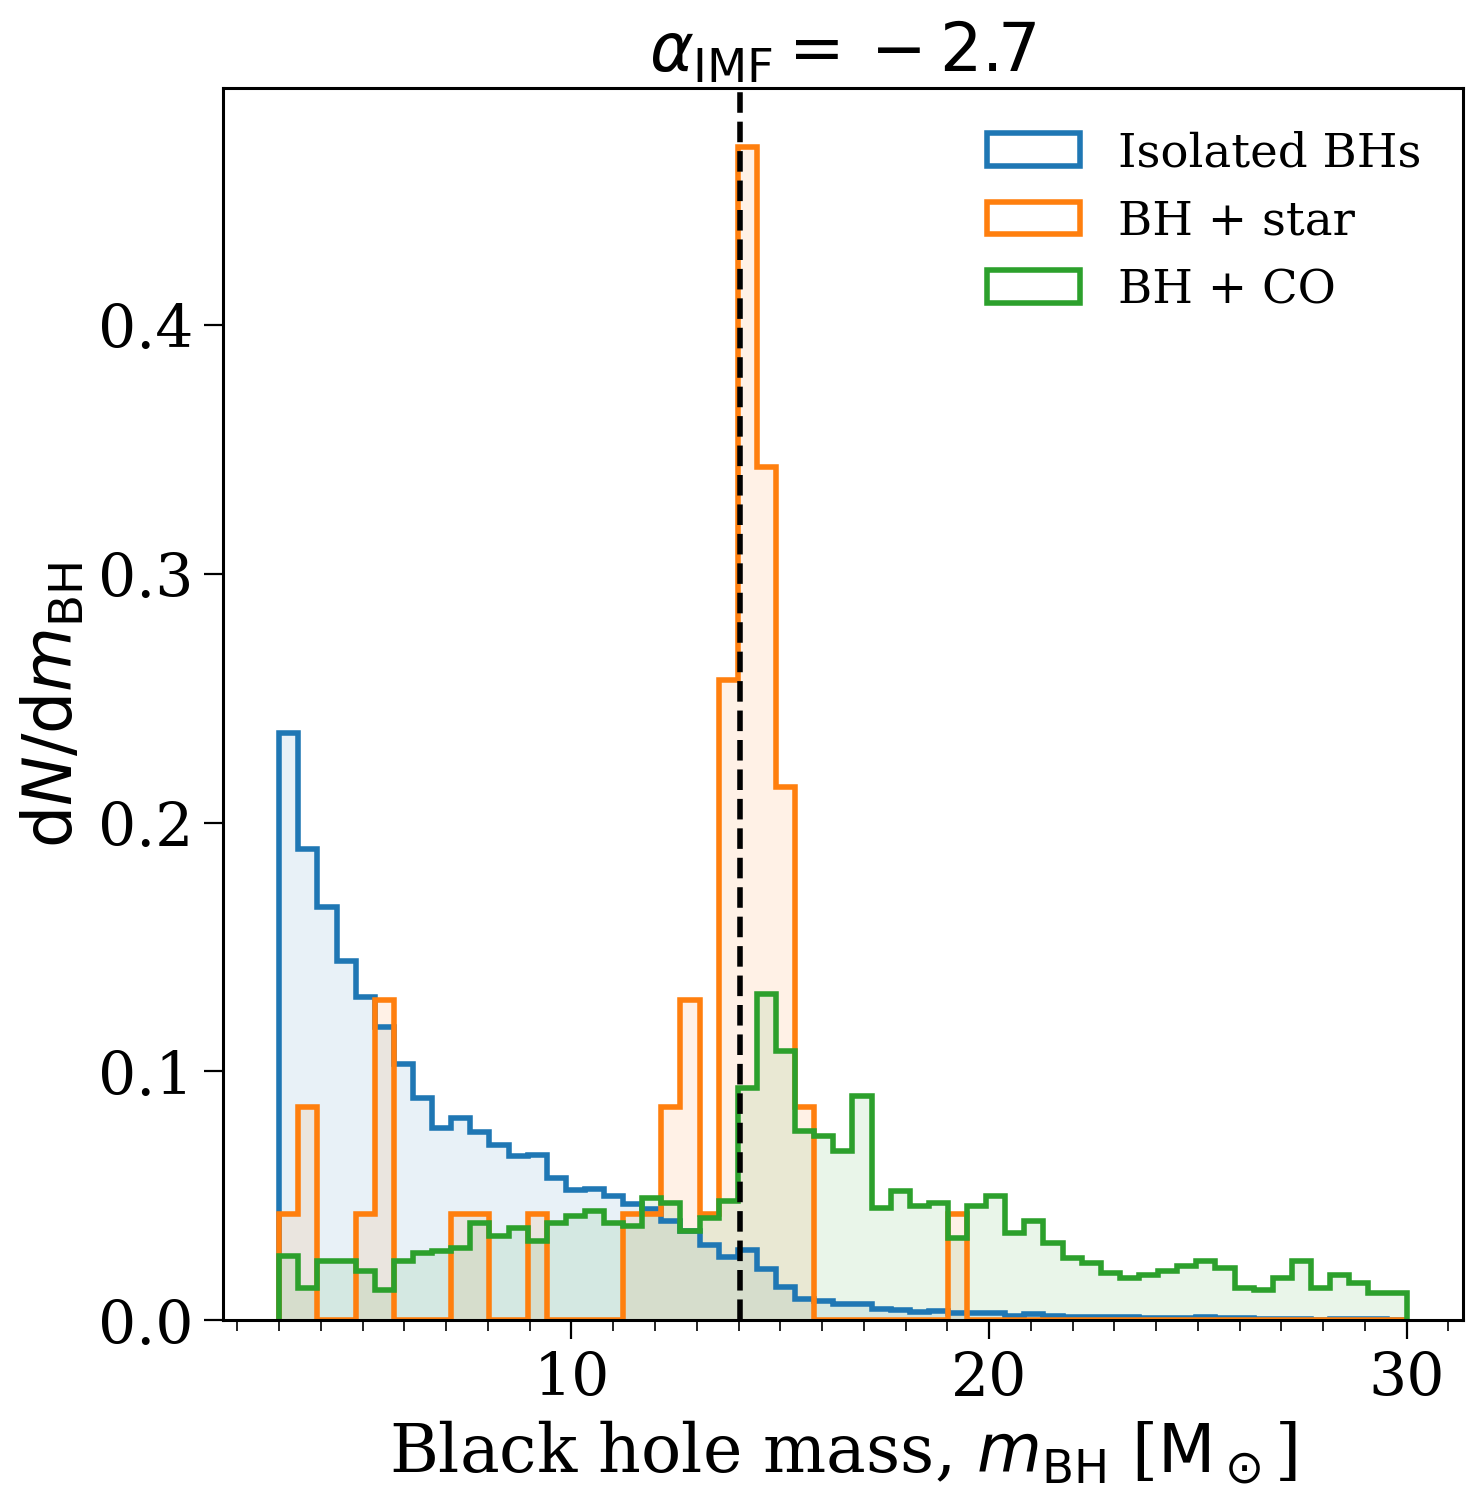

$\kappa = -1.0$ 6747


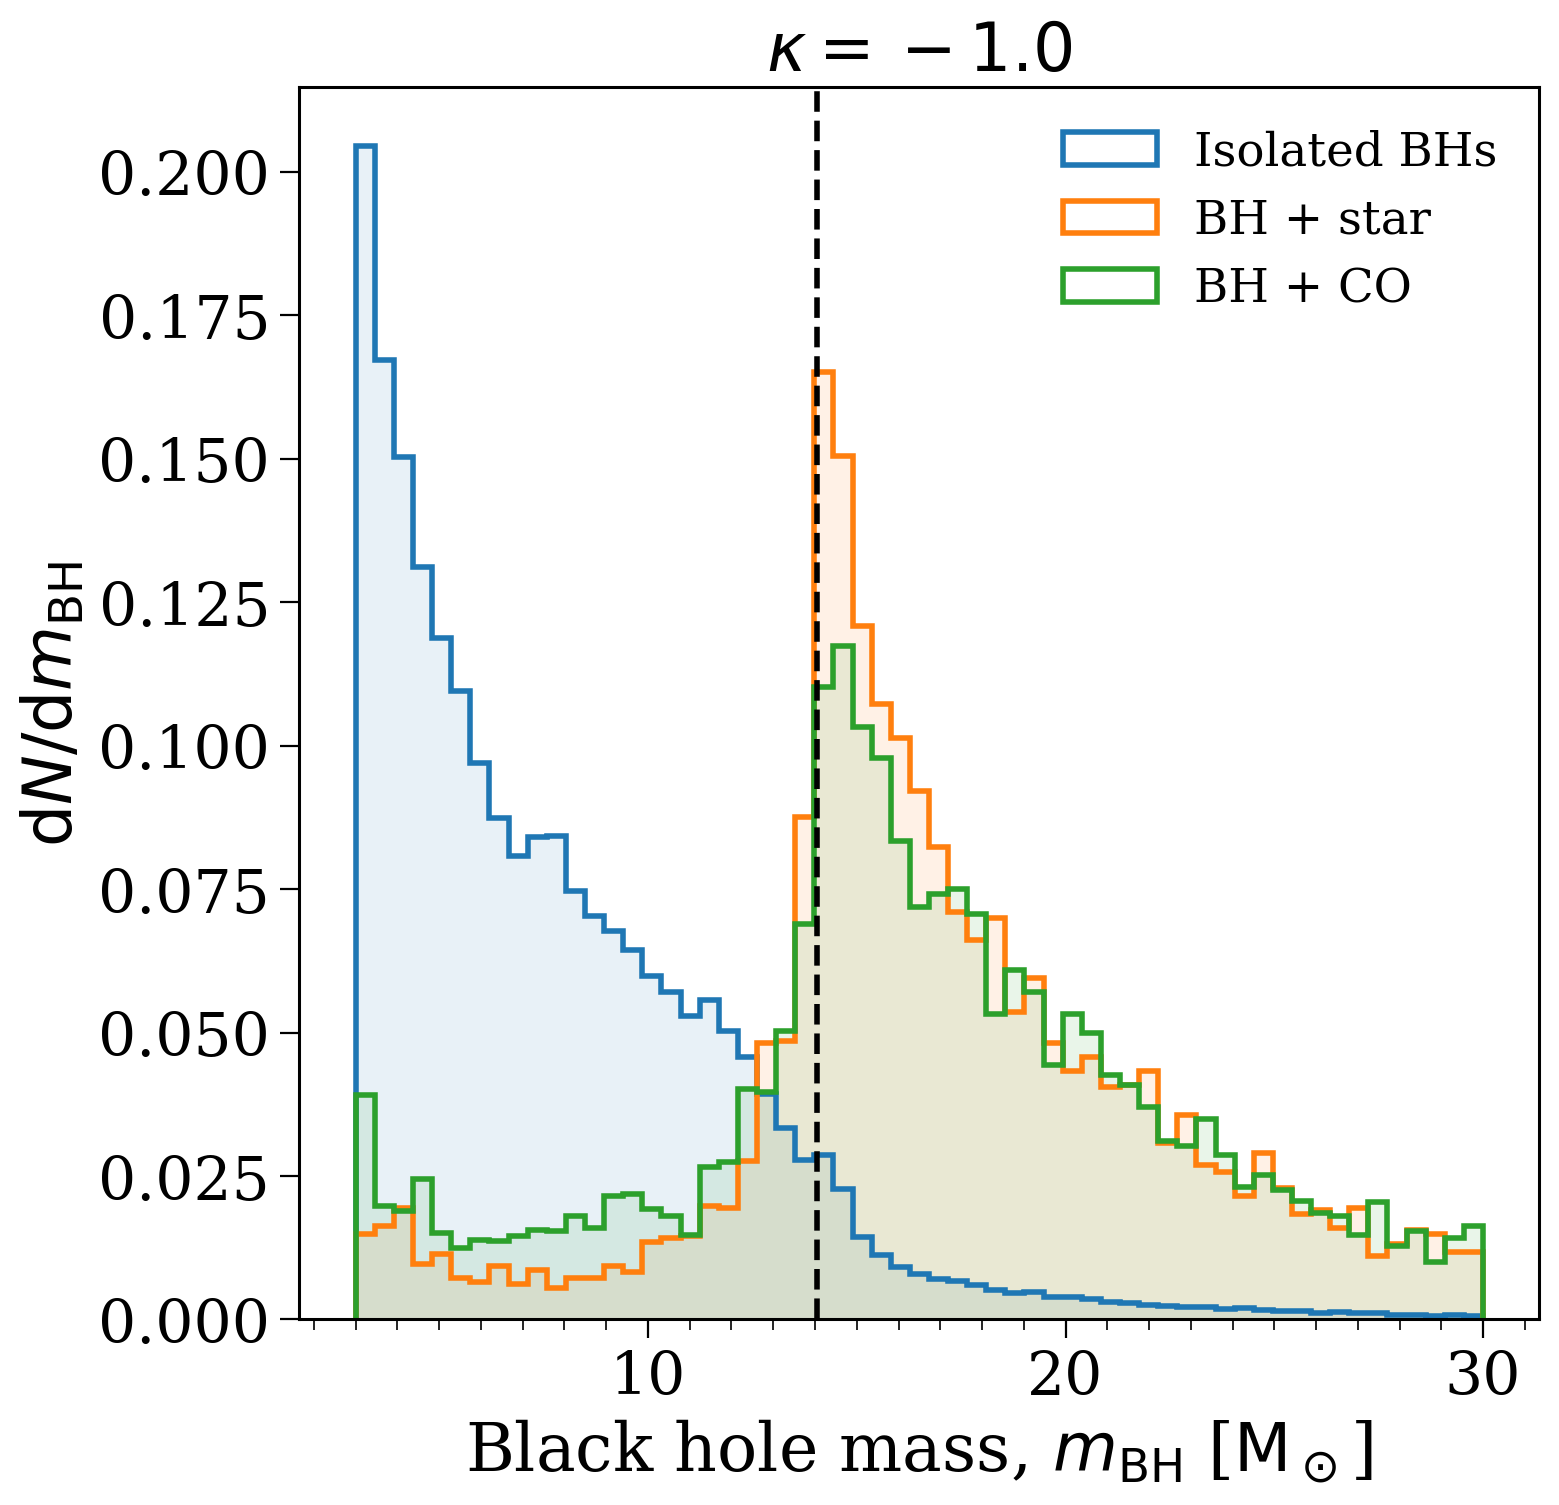

$\kappa = 1.0$ 6


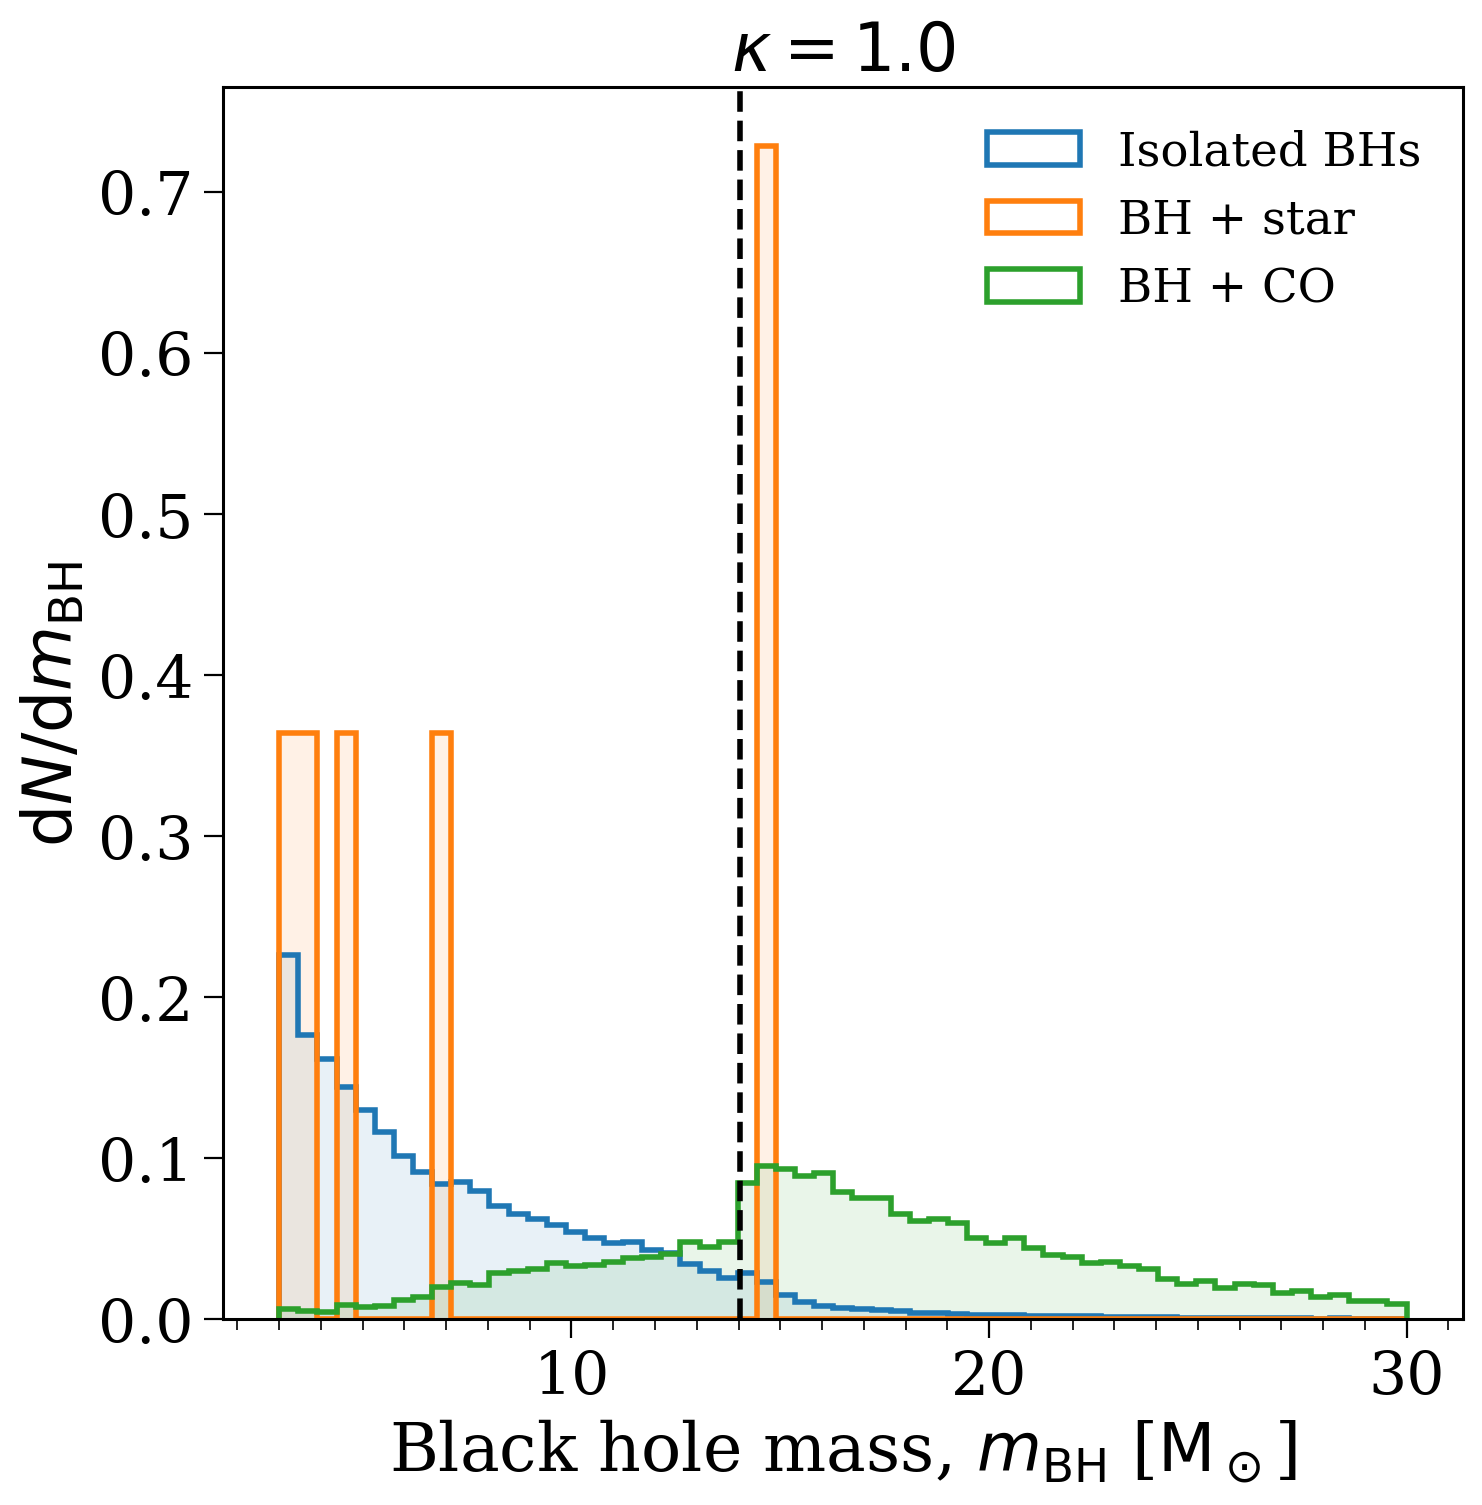

$q_{\rm min} = -1.0$ 28


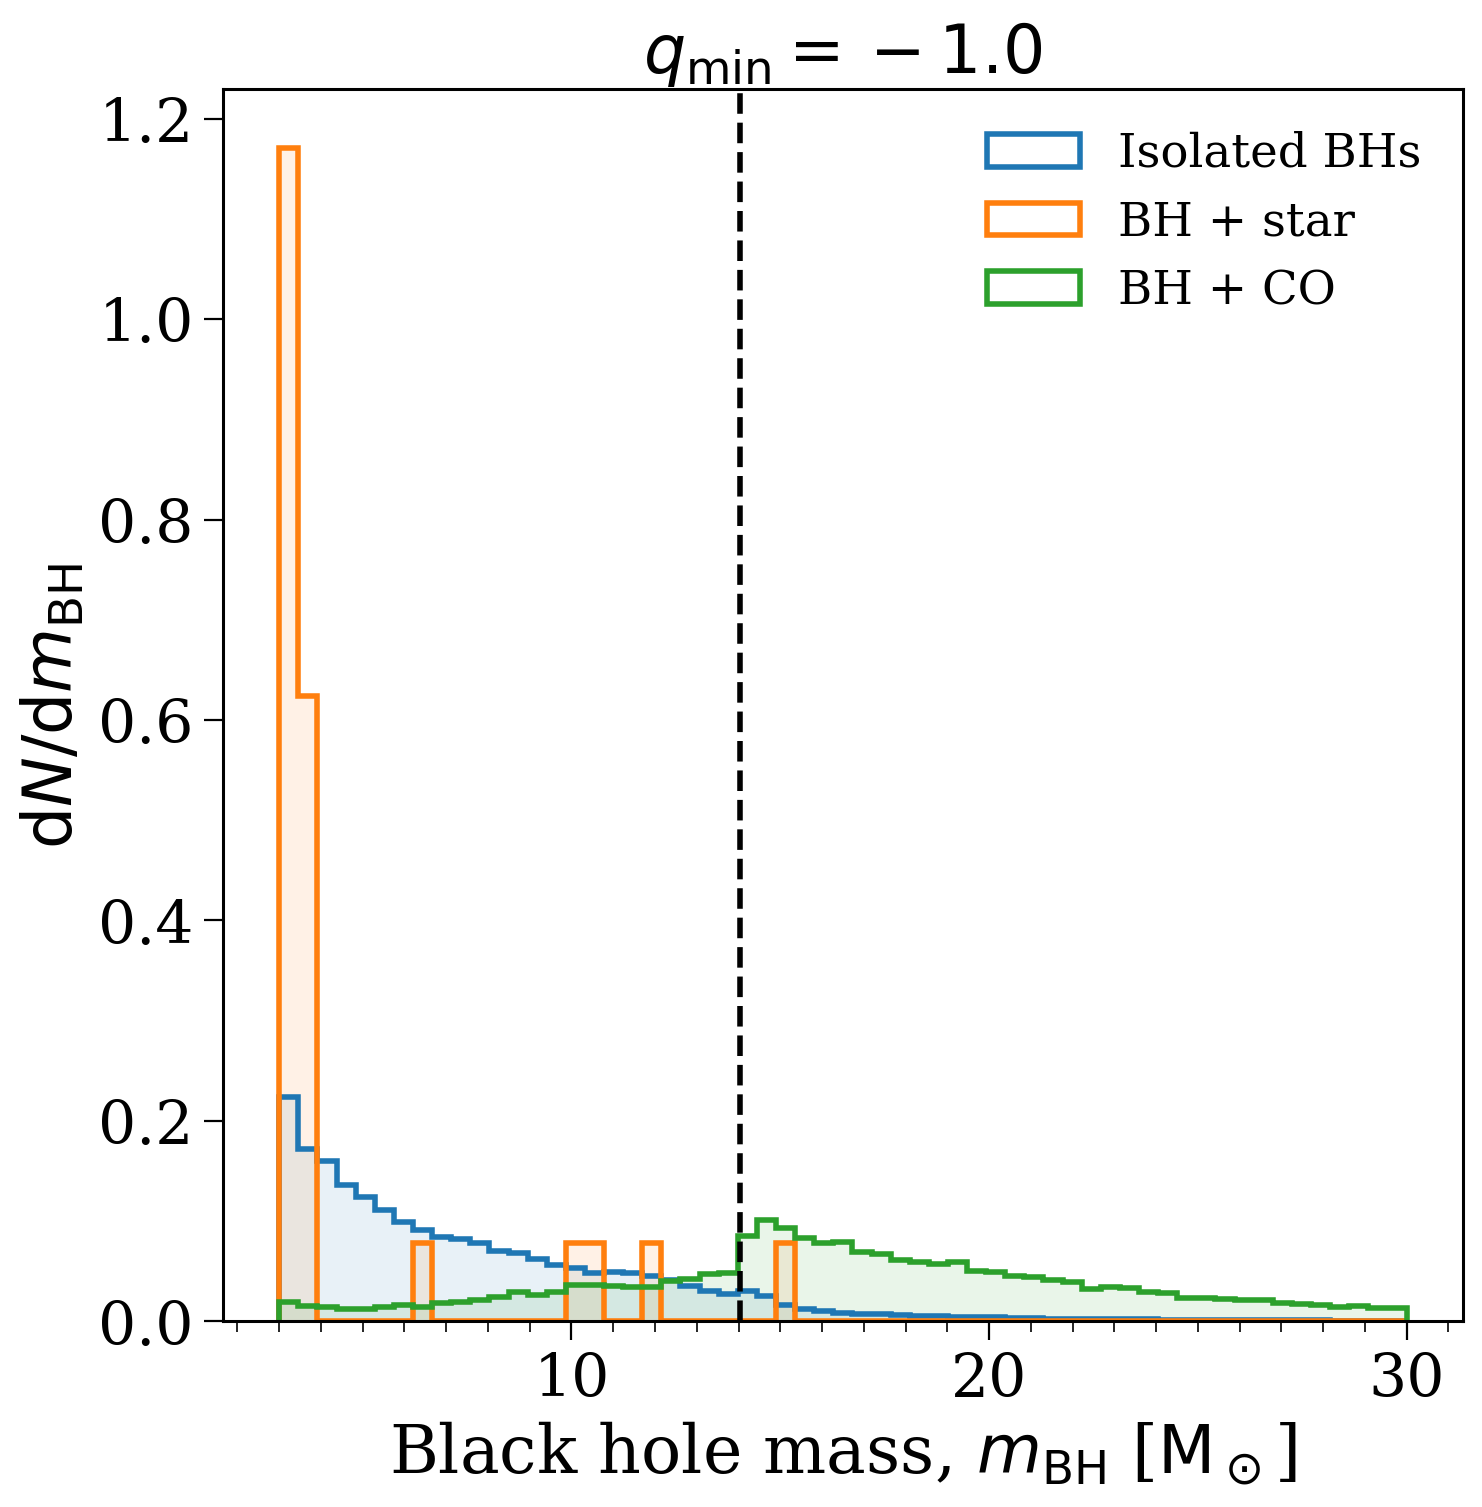

$\pi = 0.0$ 385


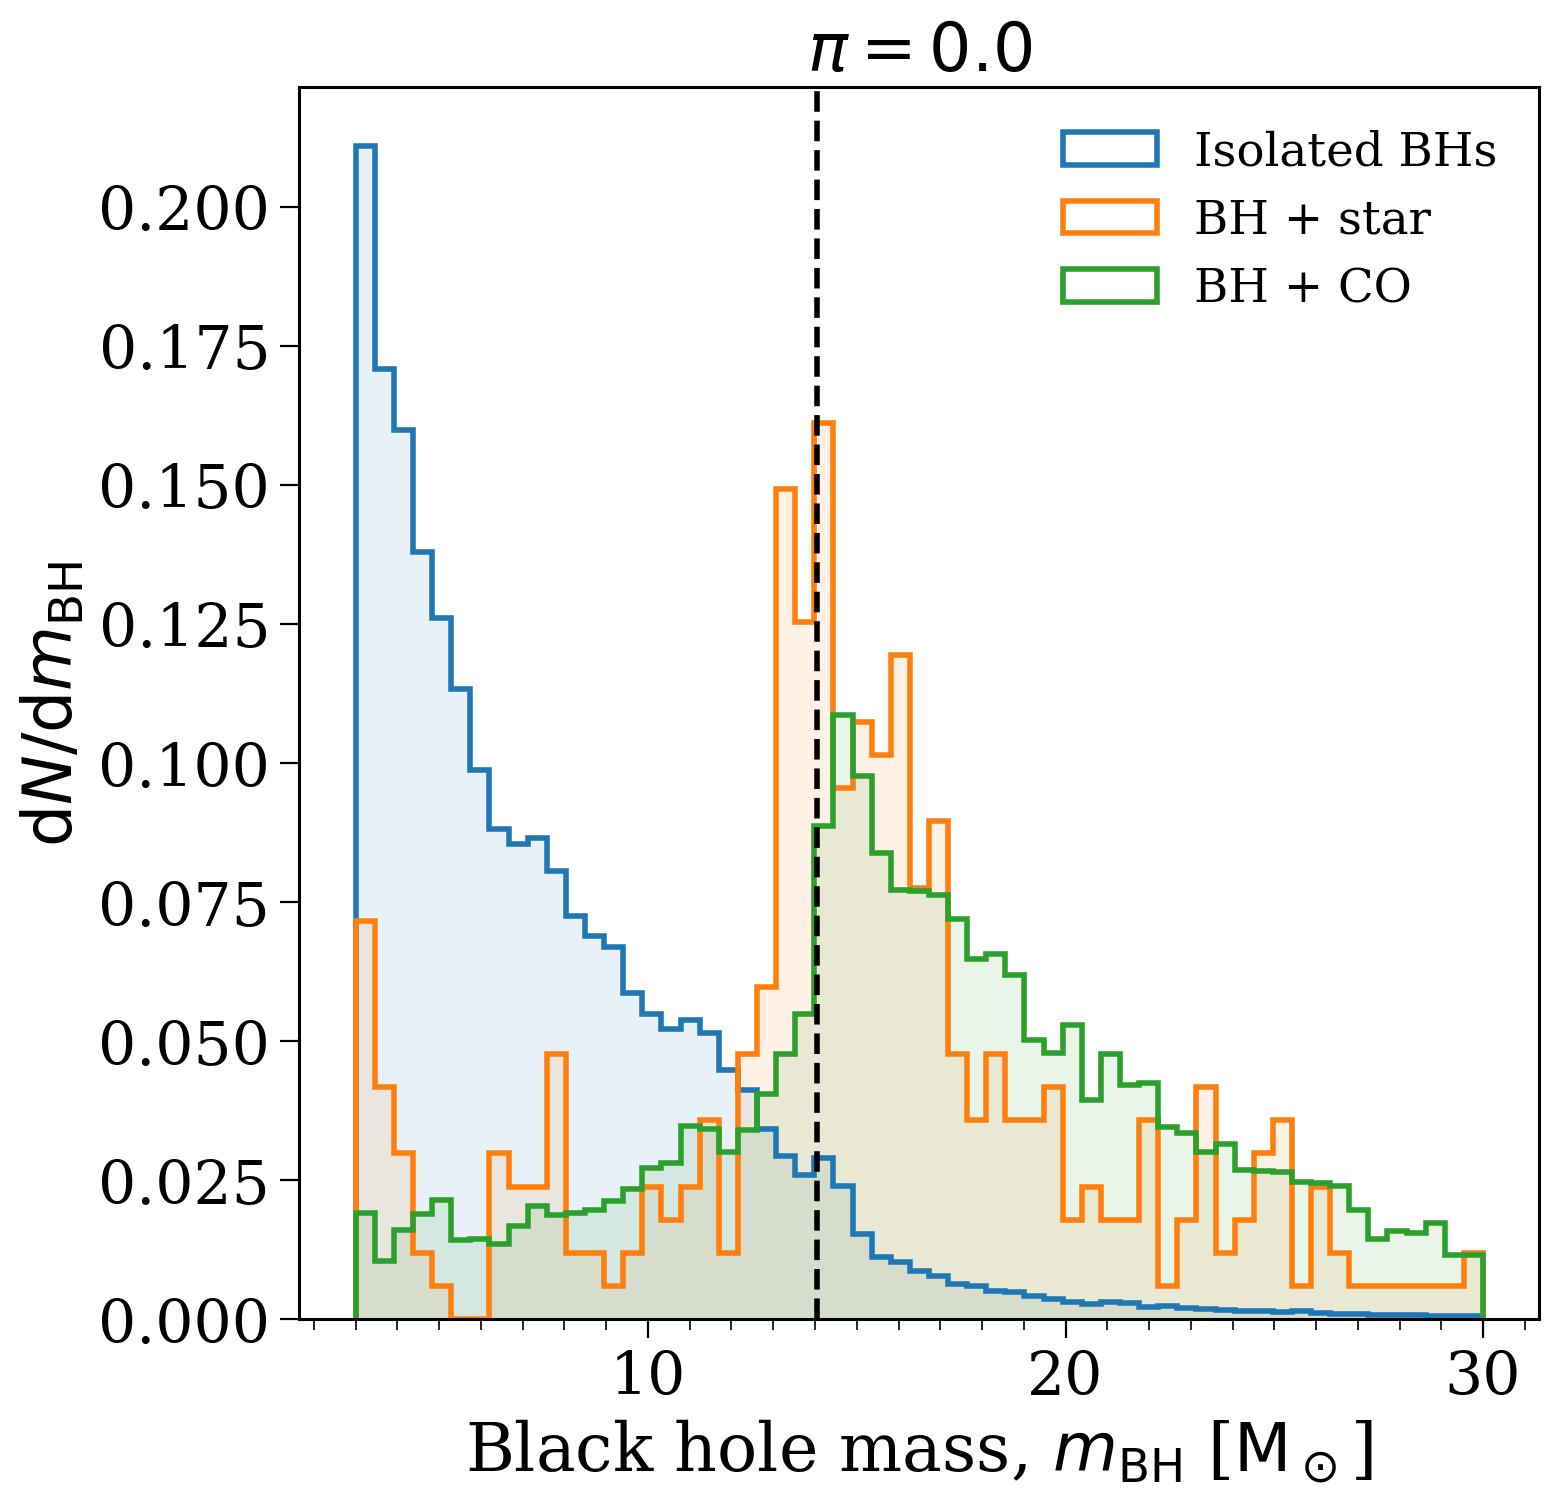

$\pi = -1.0$ 115


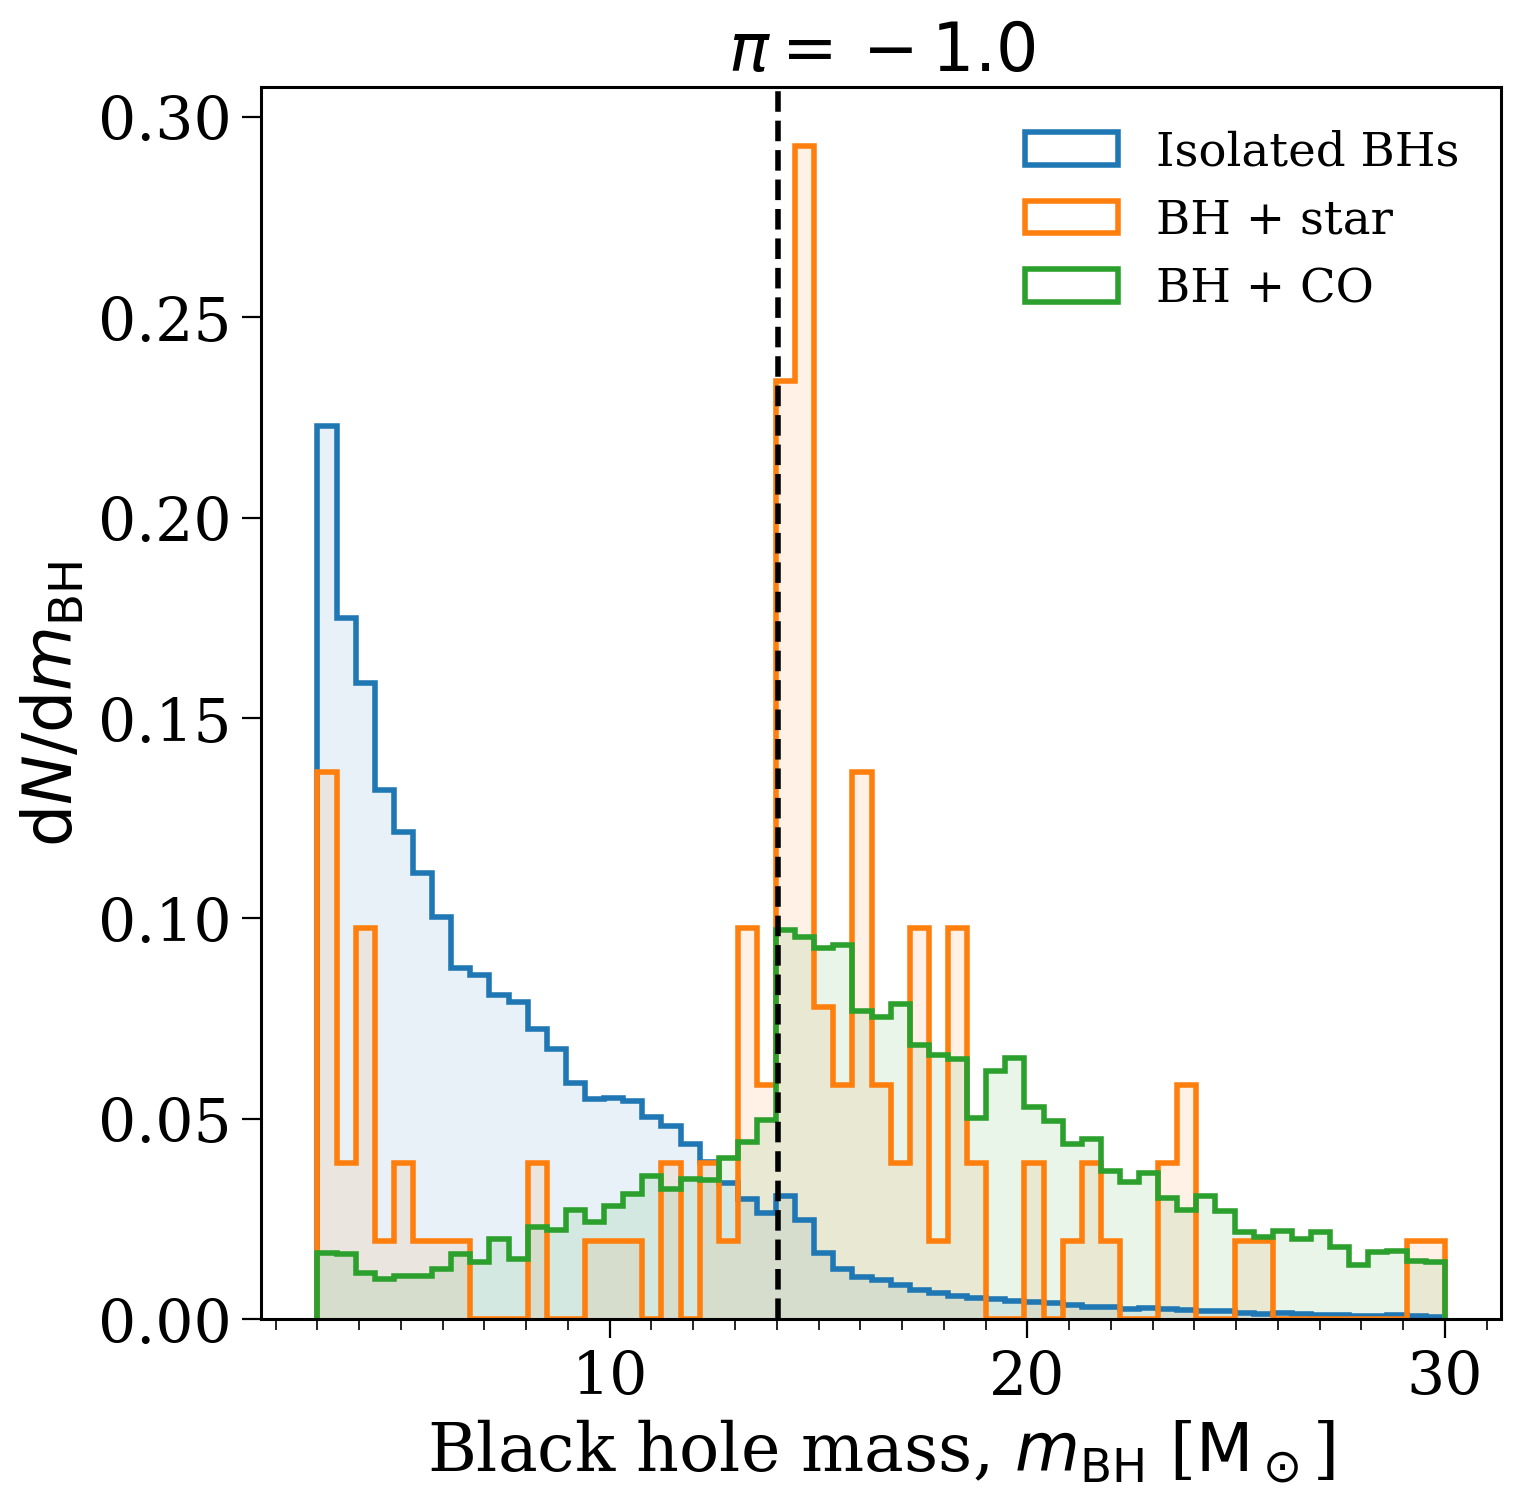

$P_{\rm orb, max} = 10^3\,{\rm days}$ 355


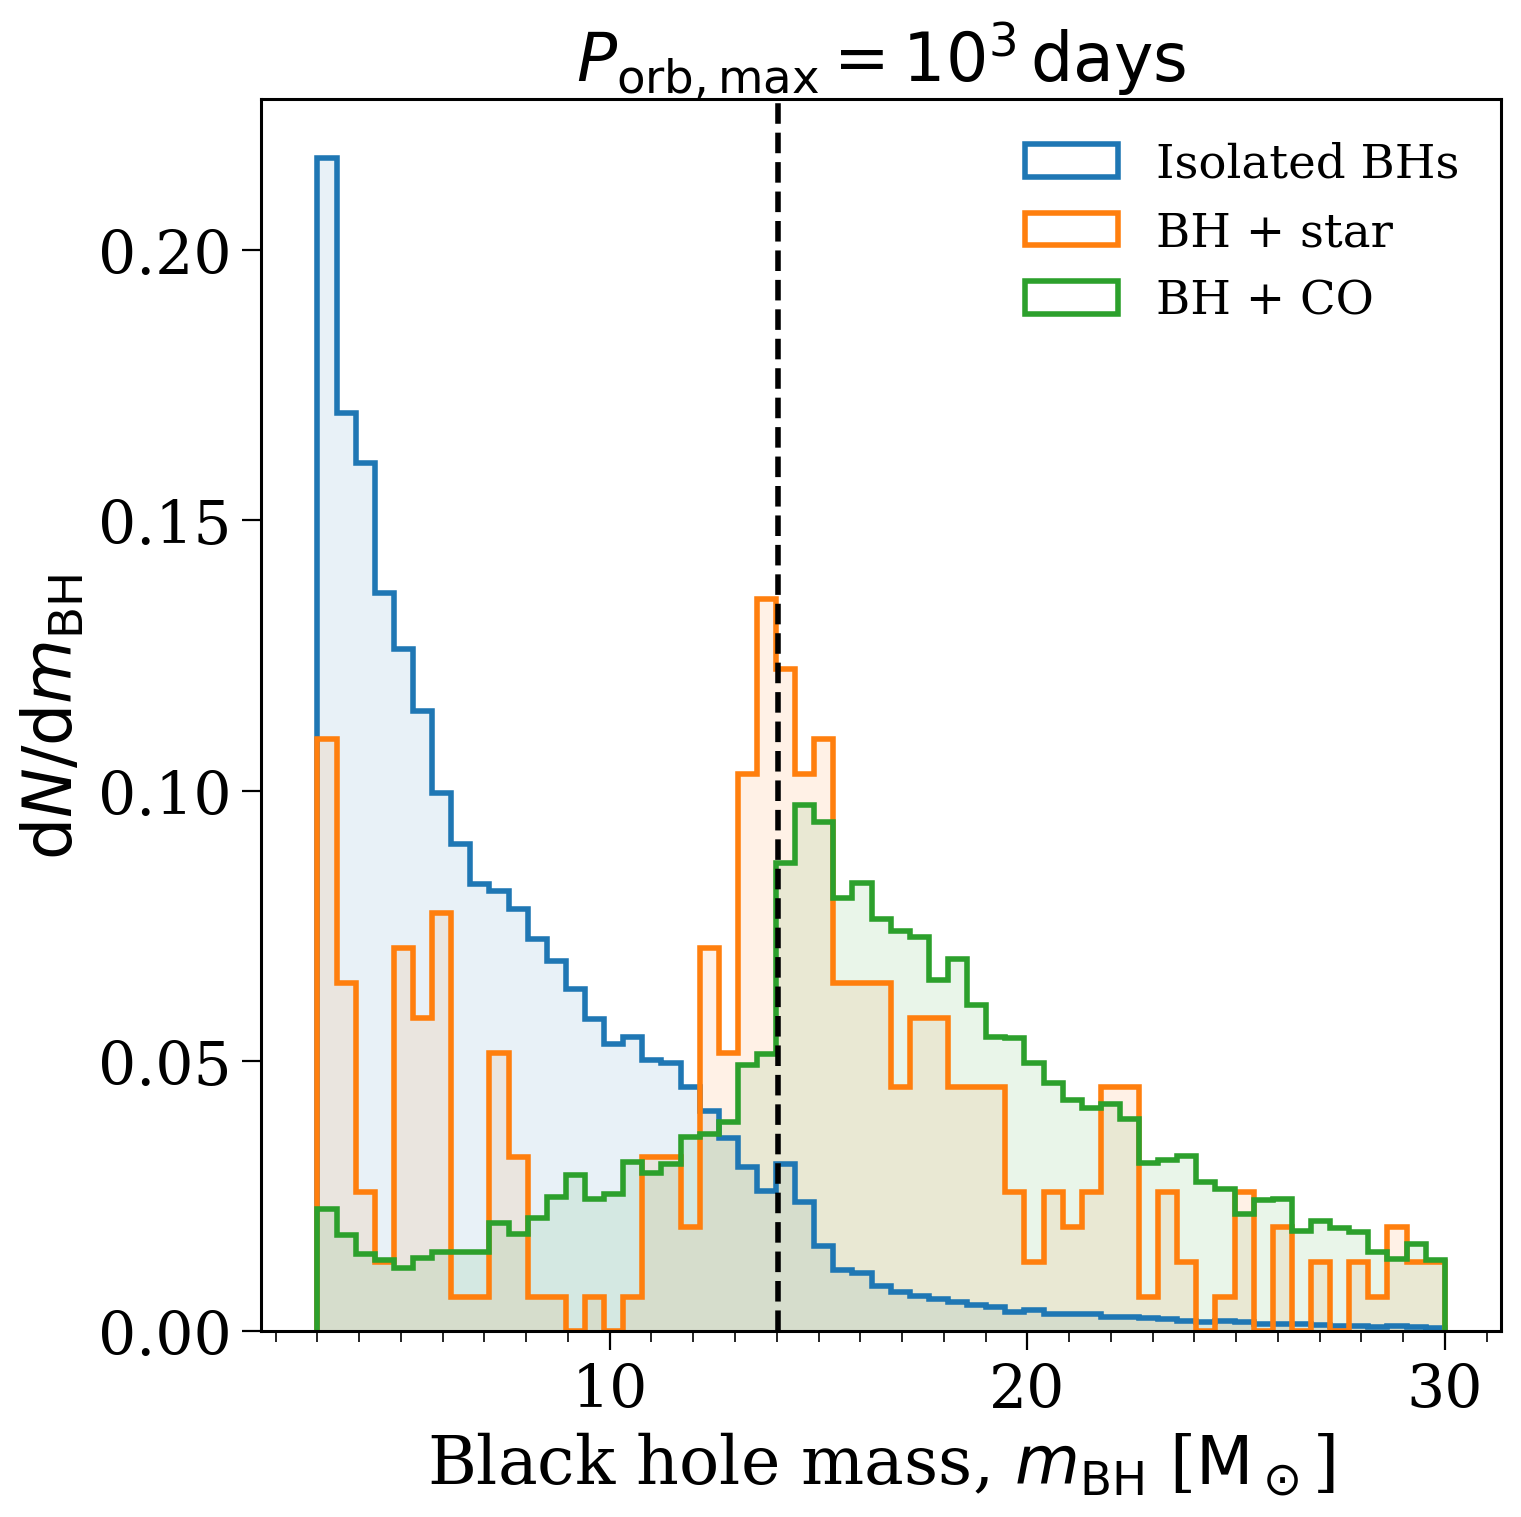

$\beta = 0.0$ 300


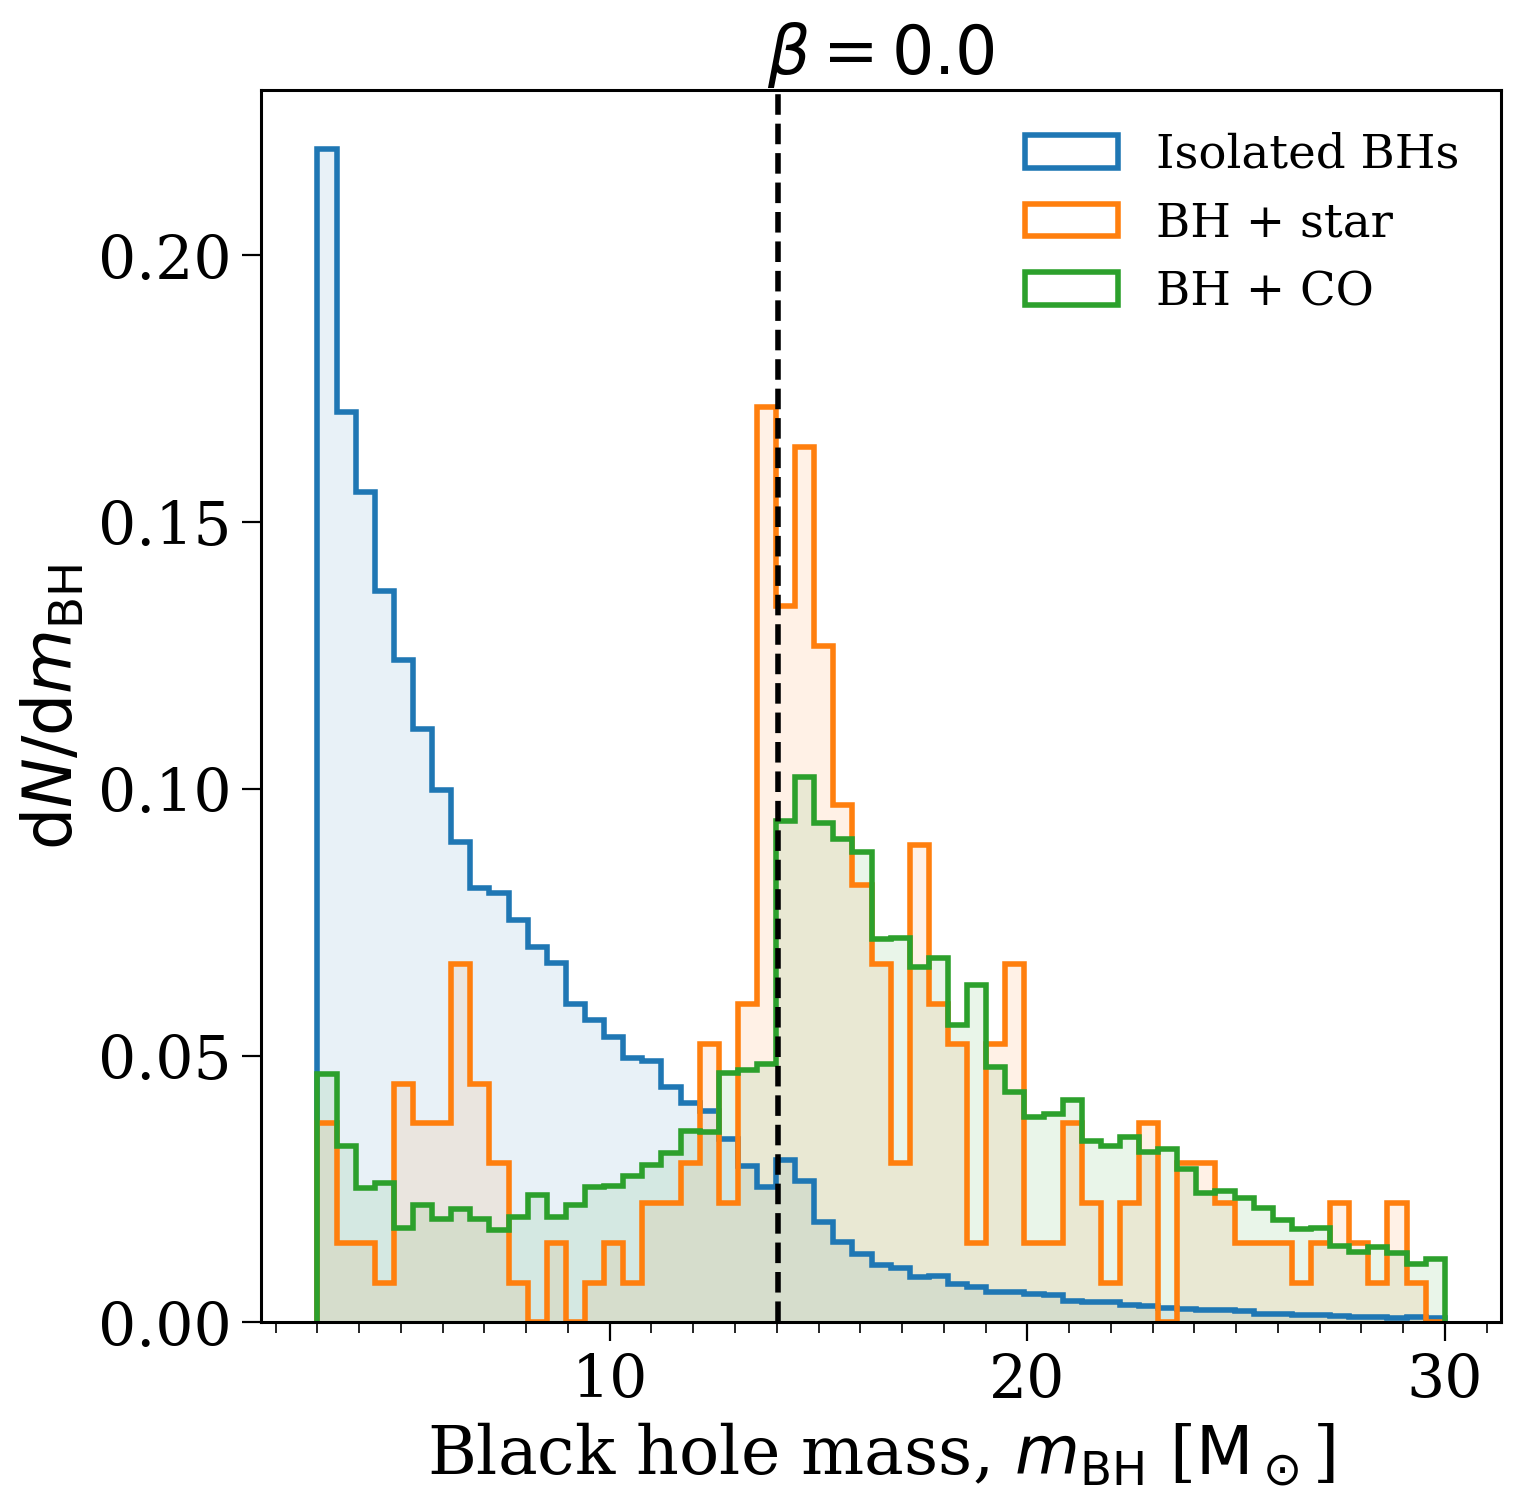

$\beta = 0.5$ 305


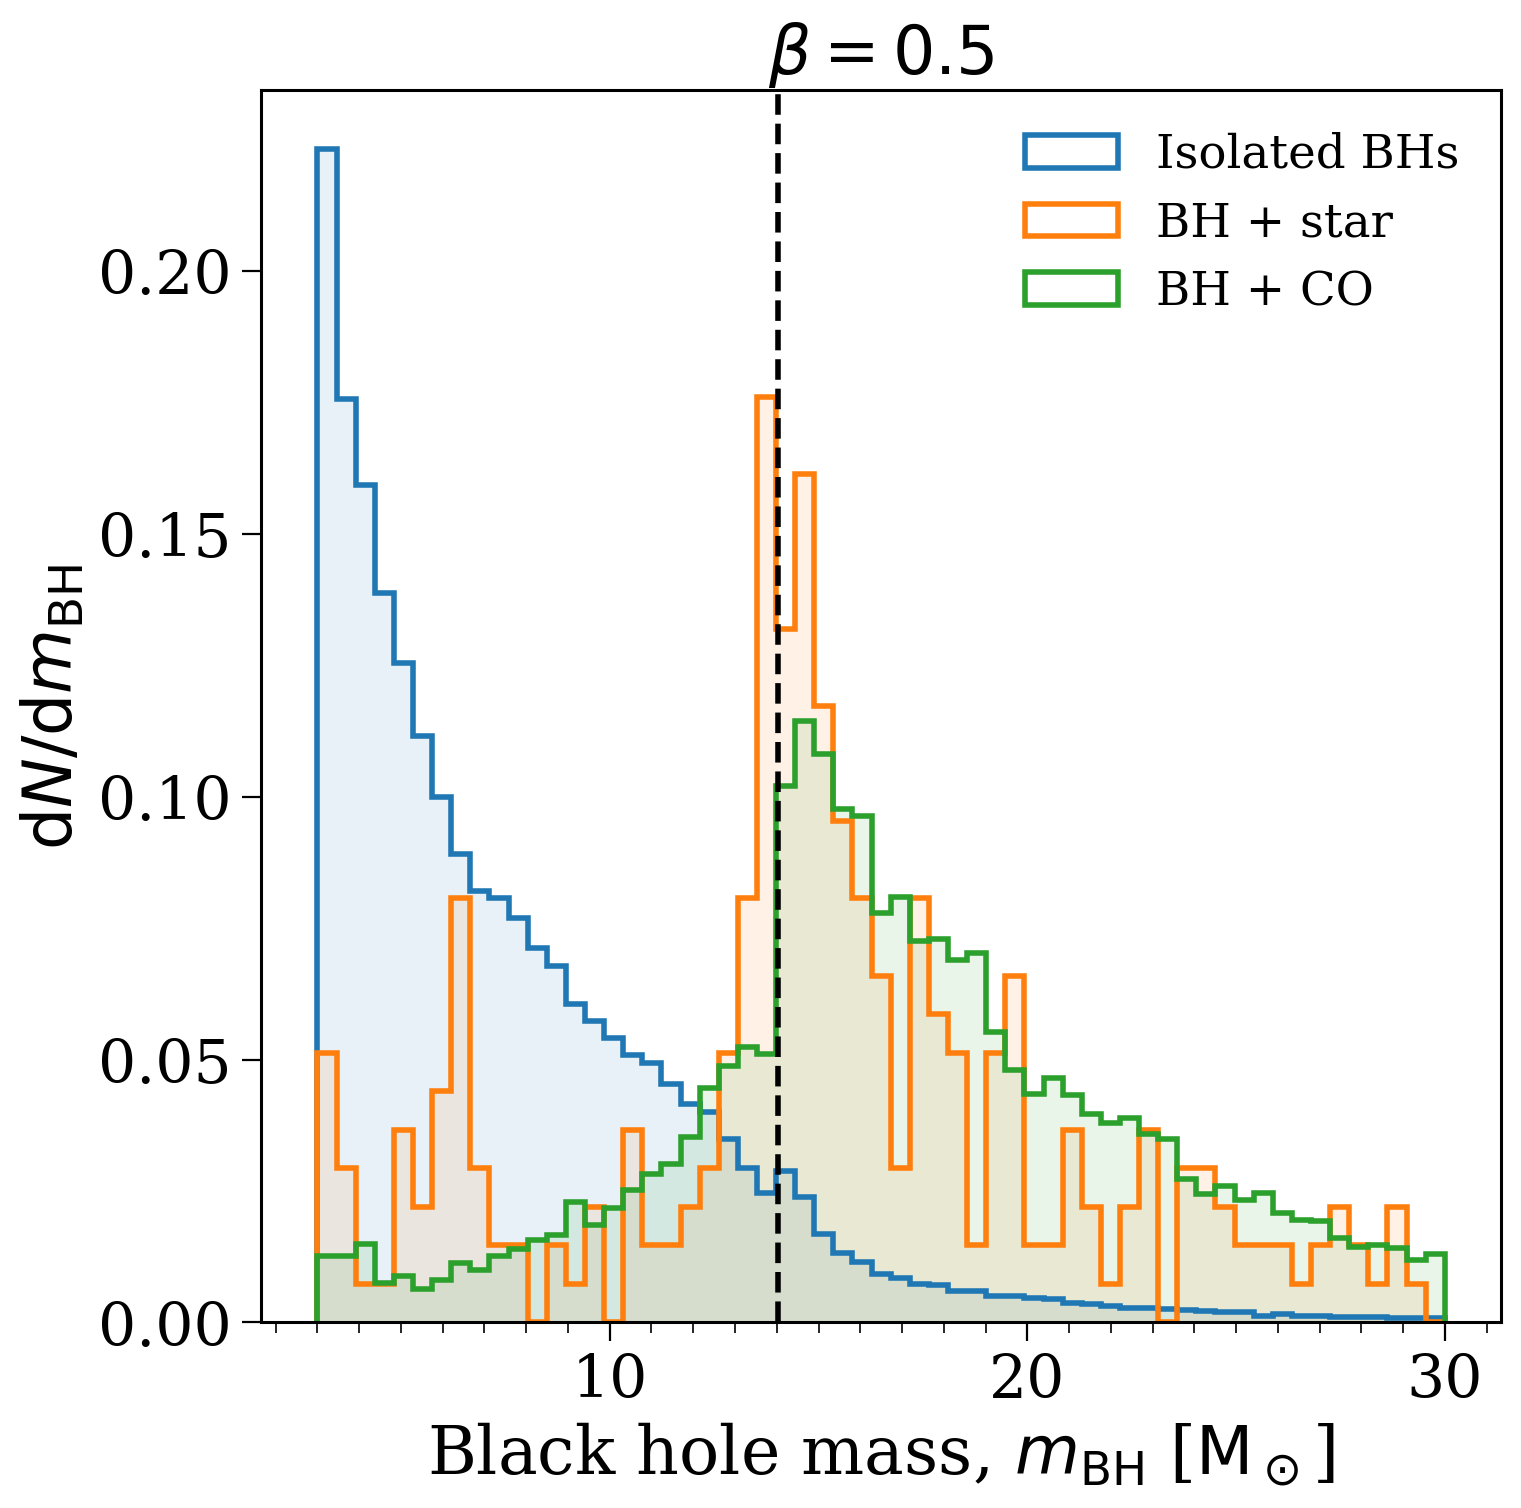

$\beta = 1.0$ 321


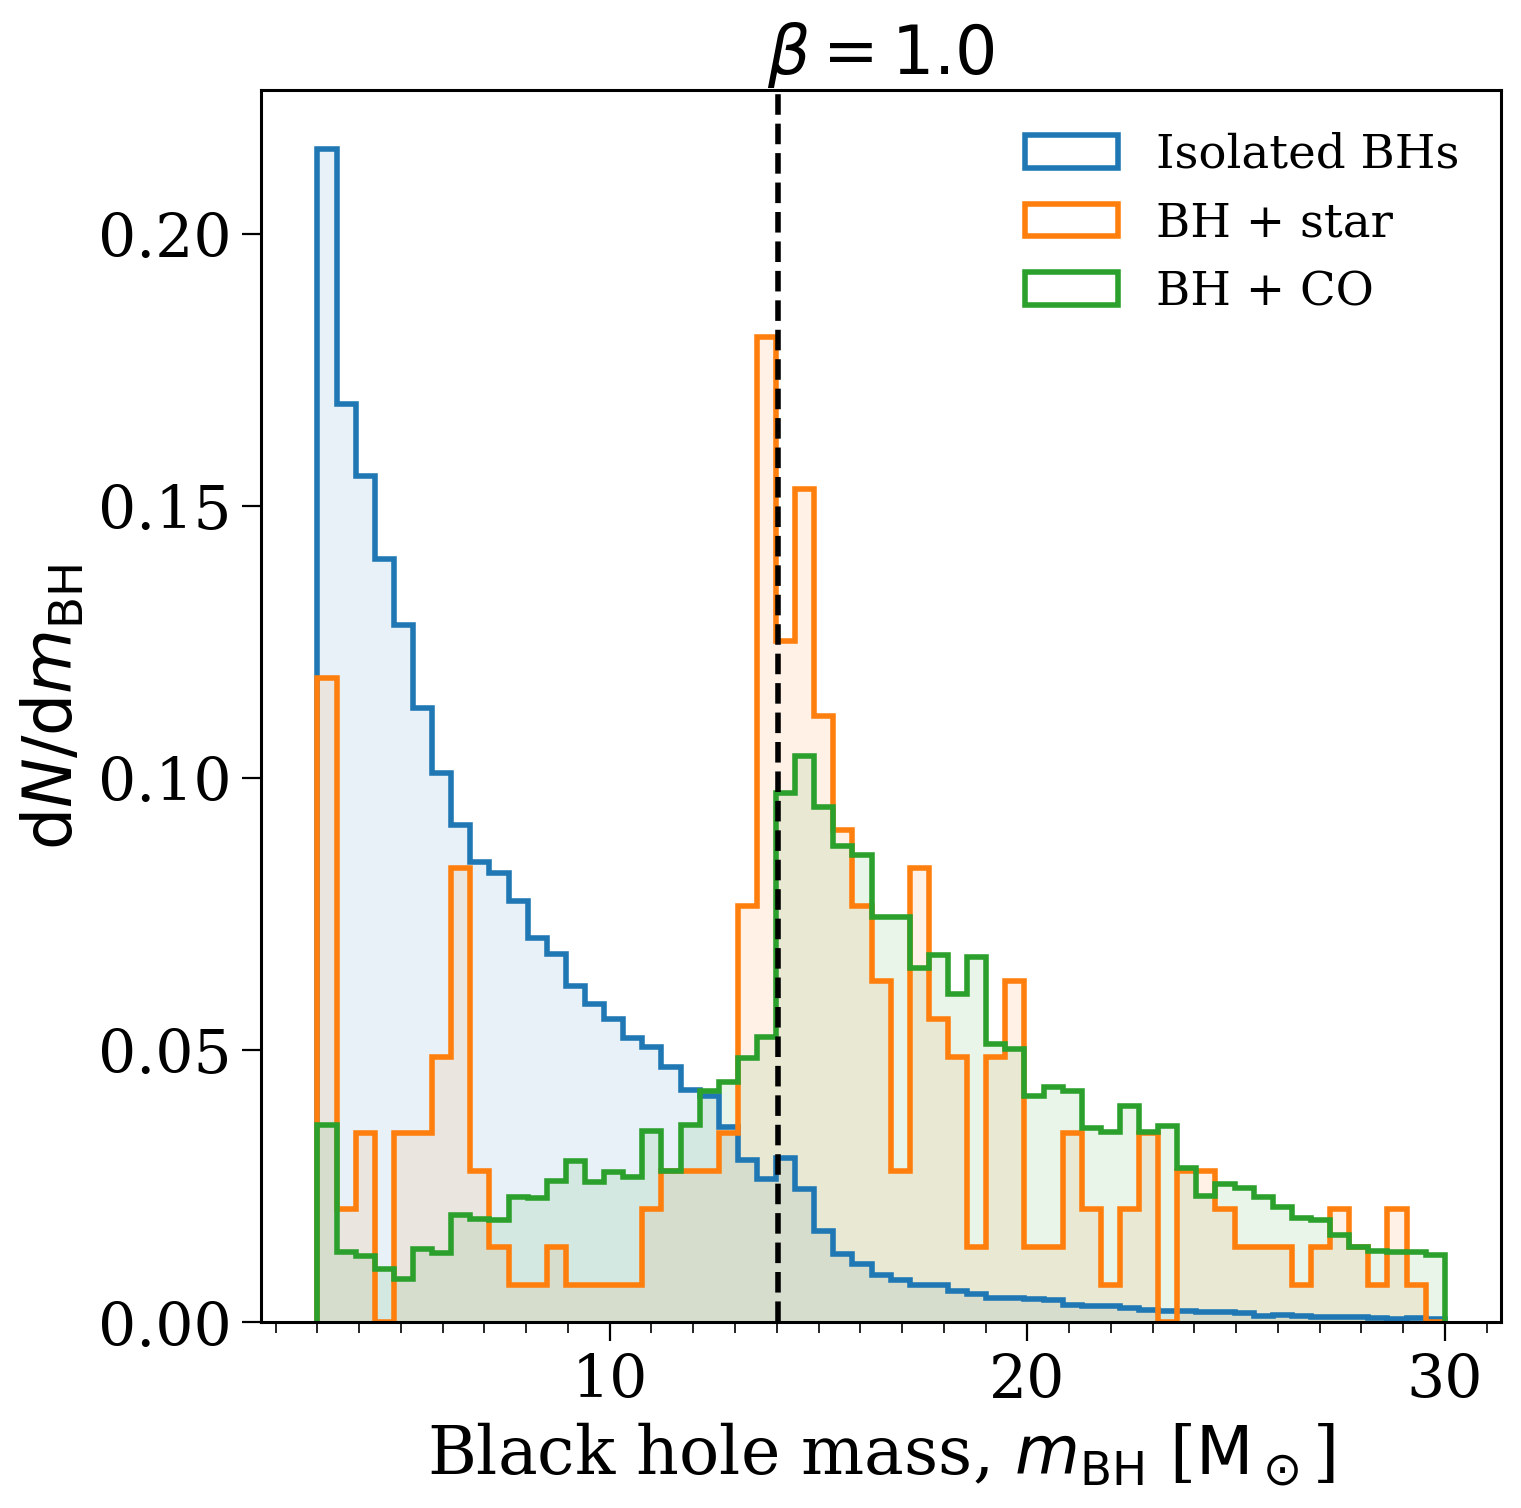

$\alpha_{\rm CE} = 0.1$ 270


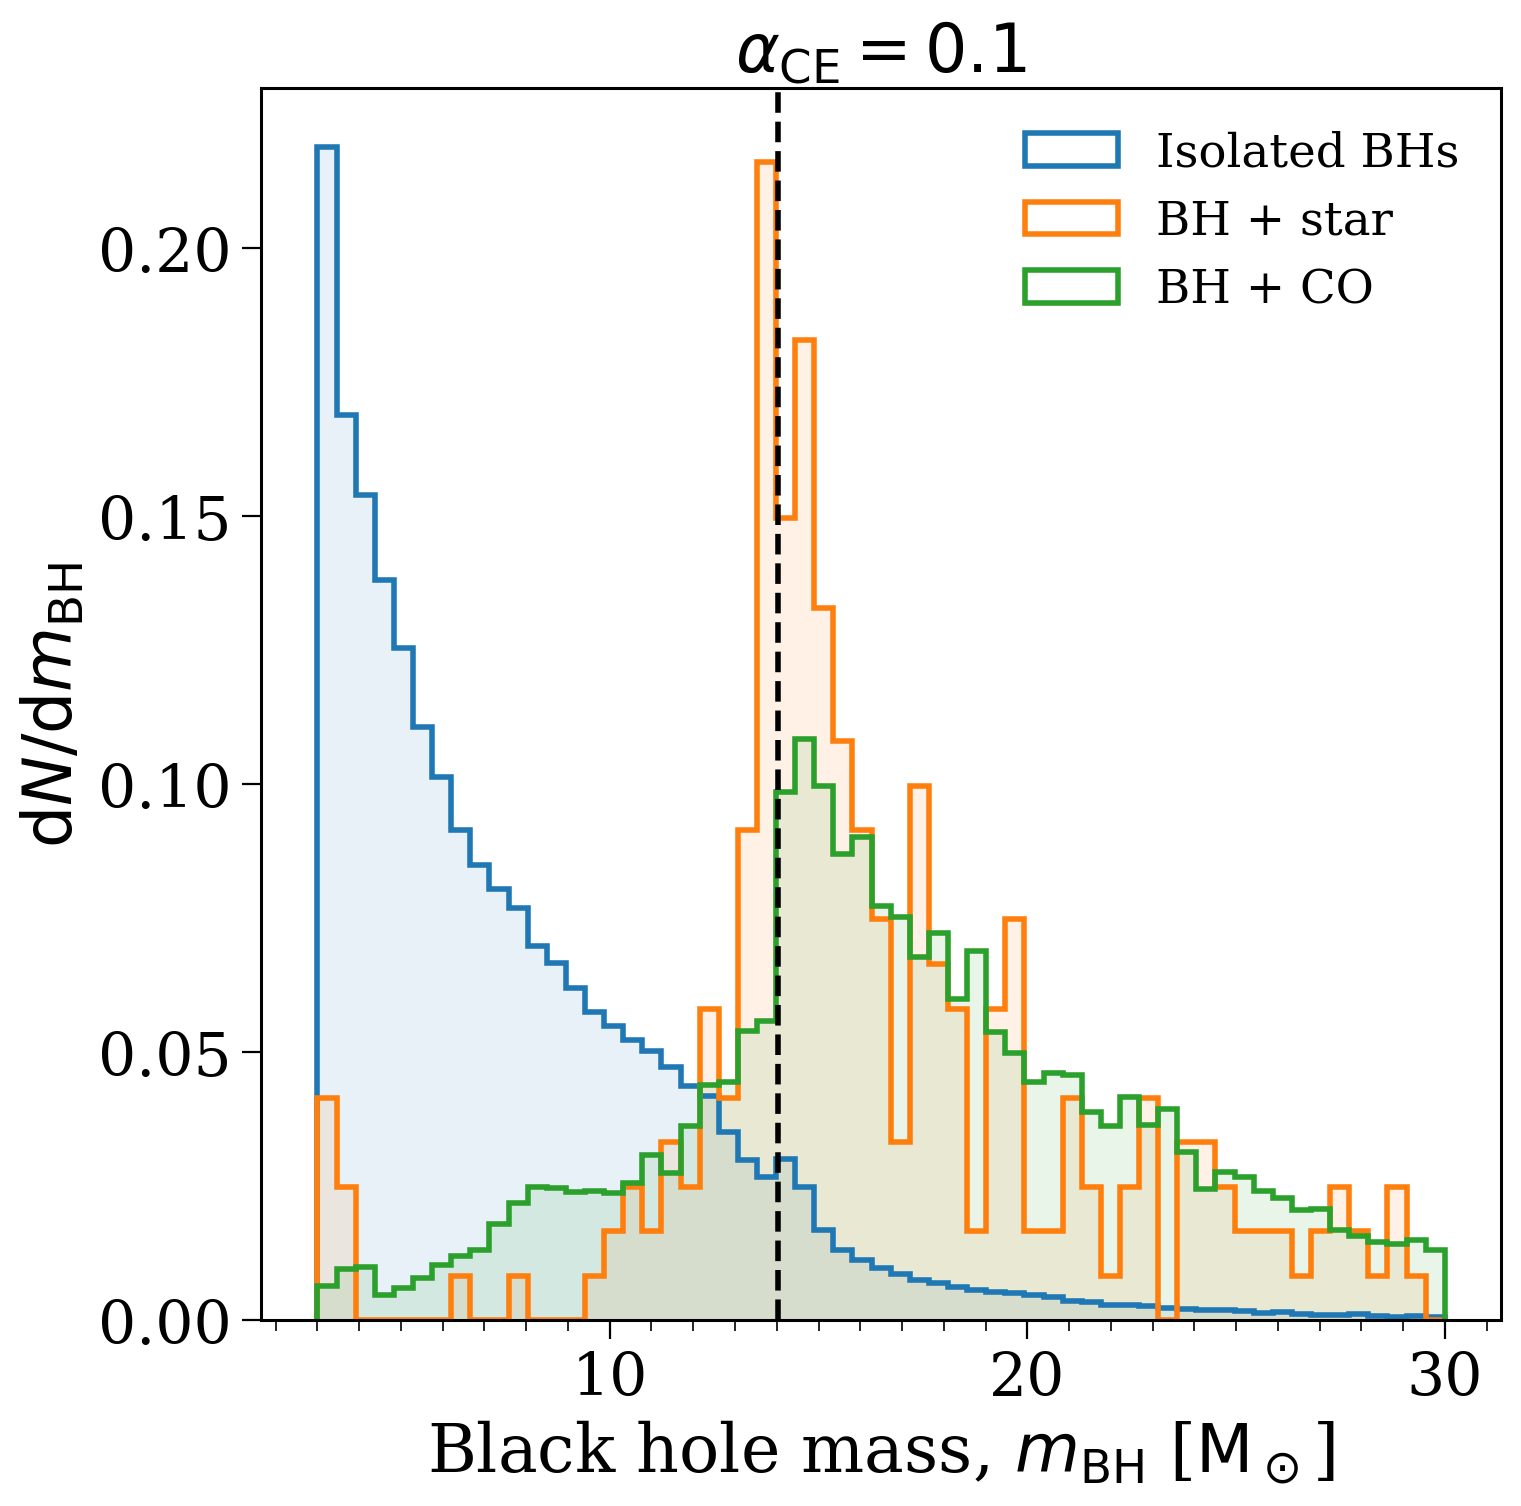

$\alpha_{\rm CE} = 0.5$ 285


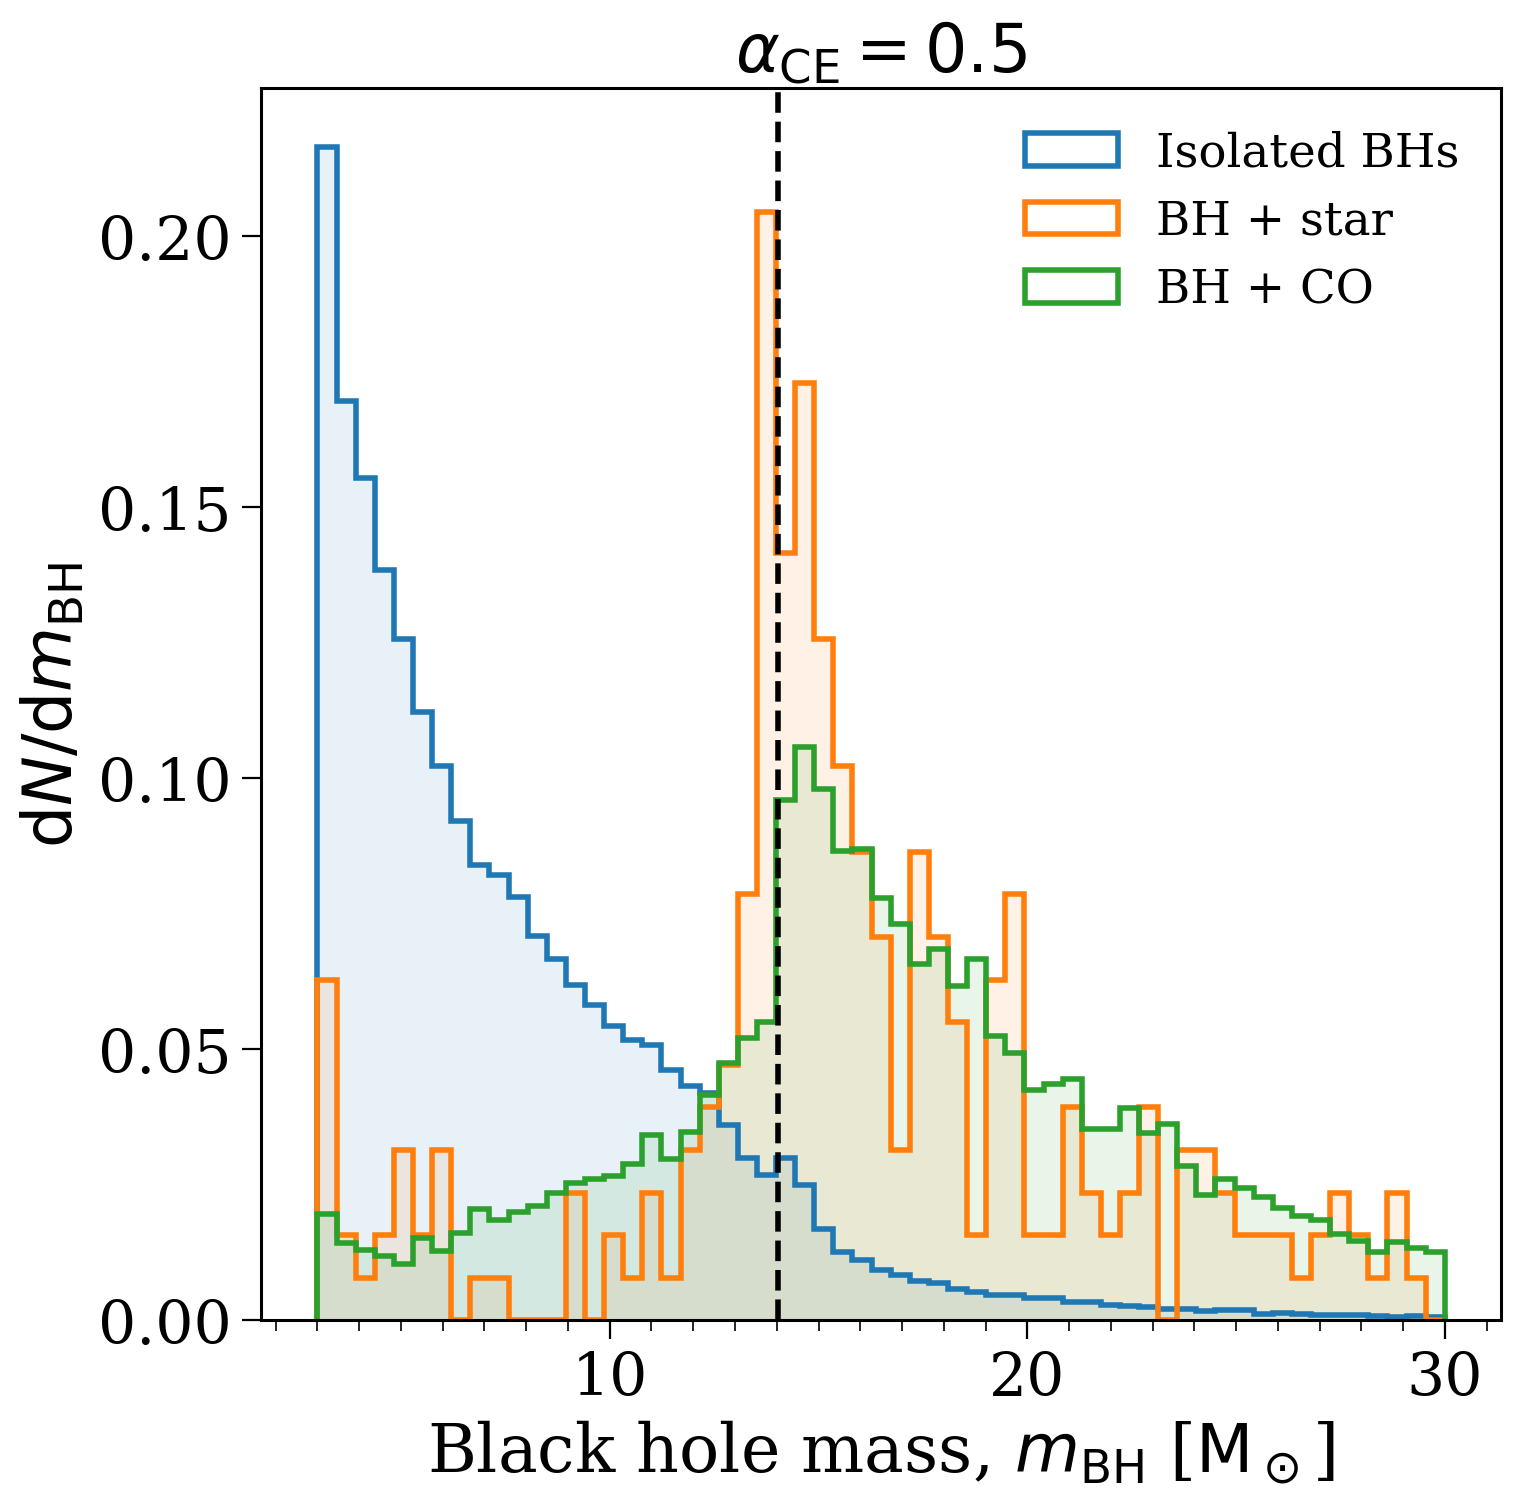

$\alpha_{\rm CE} = 2.0$ 314


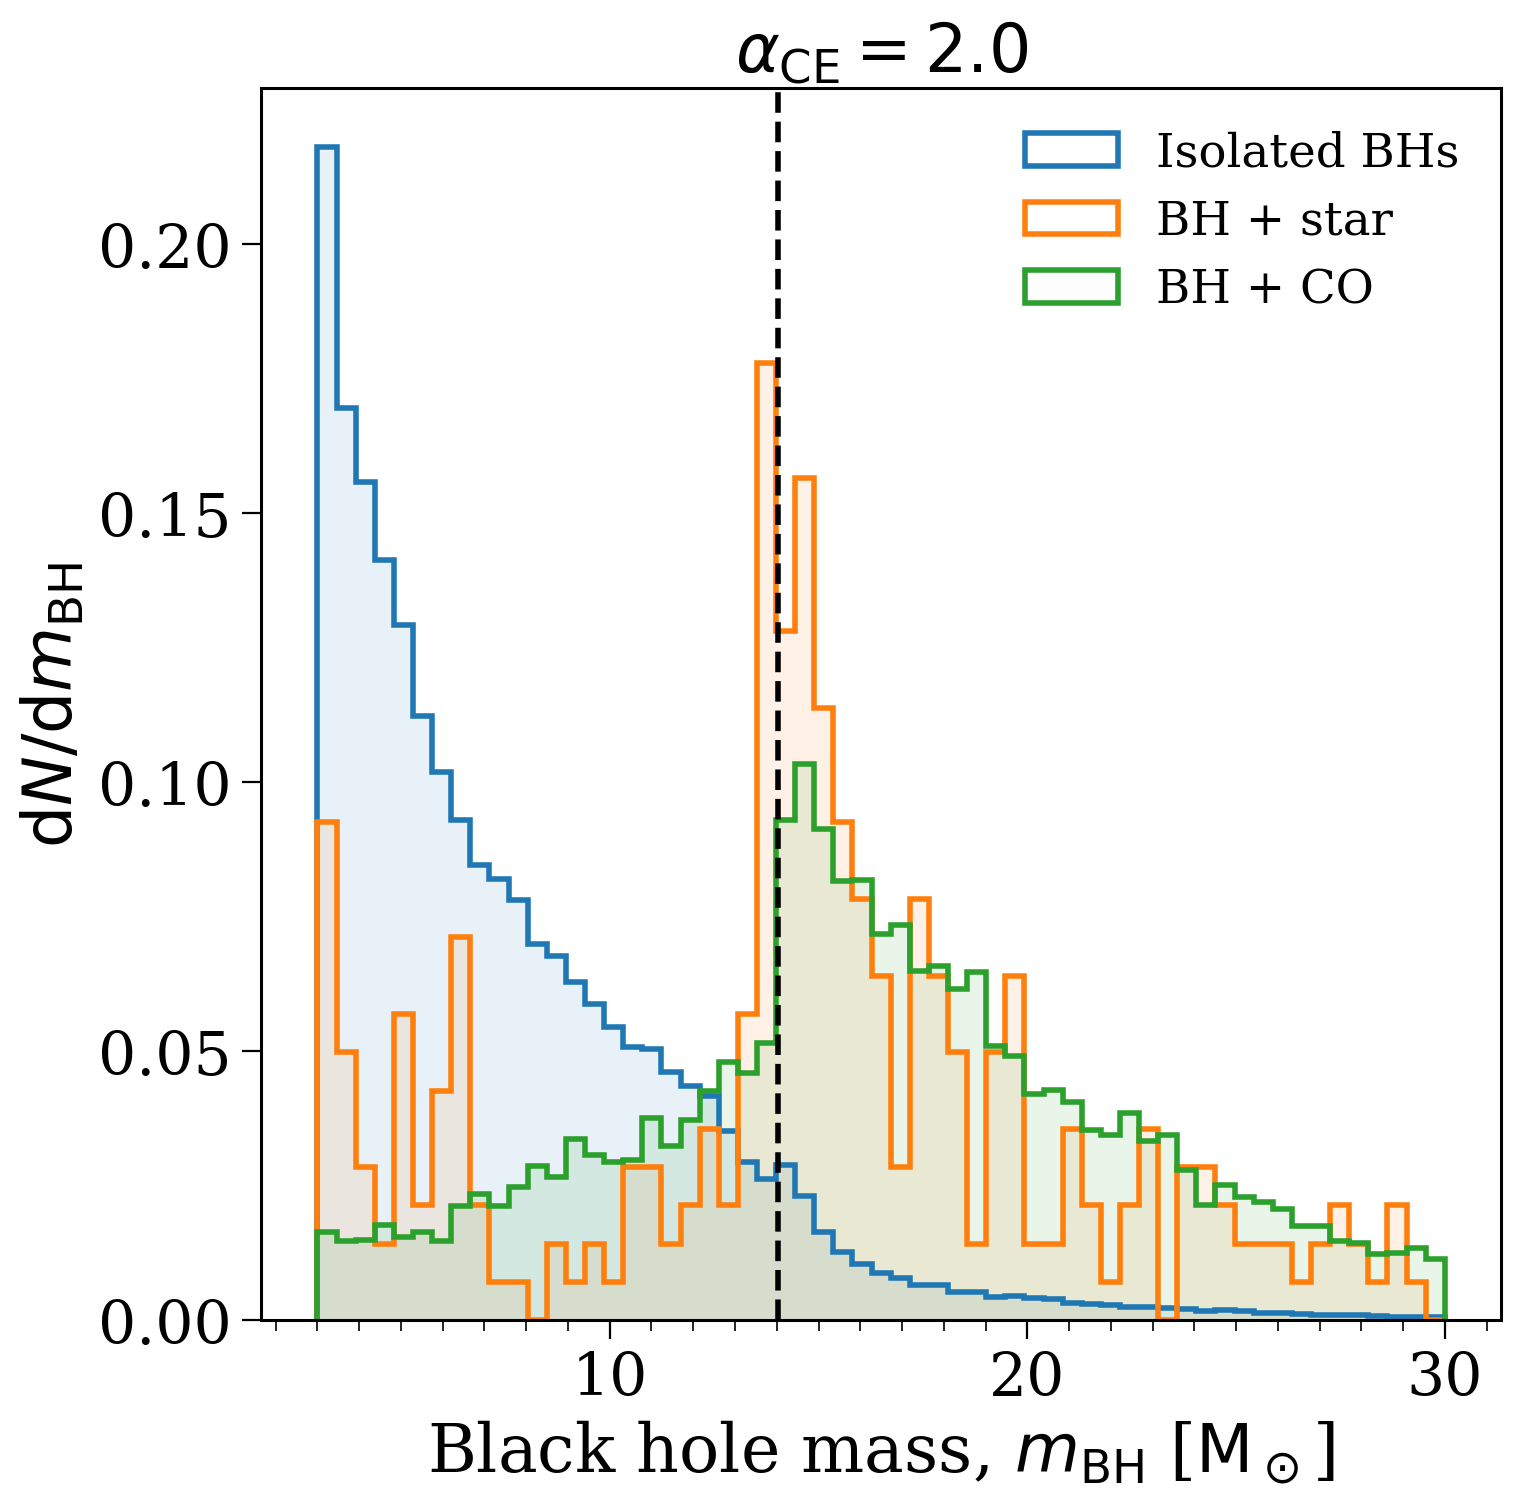

$\alpha_{\rm CE} = 10.0$ 375


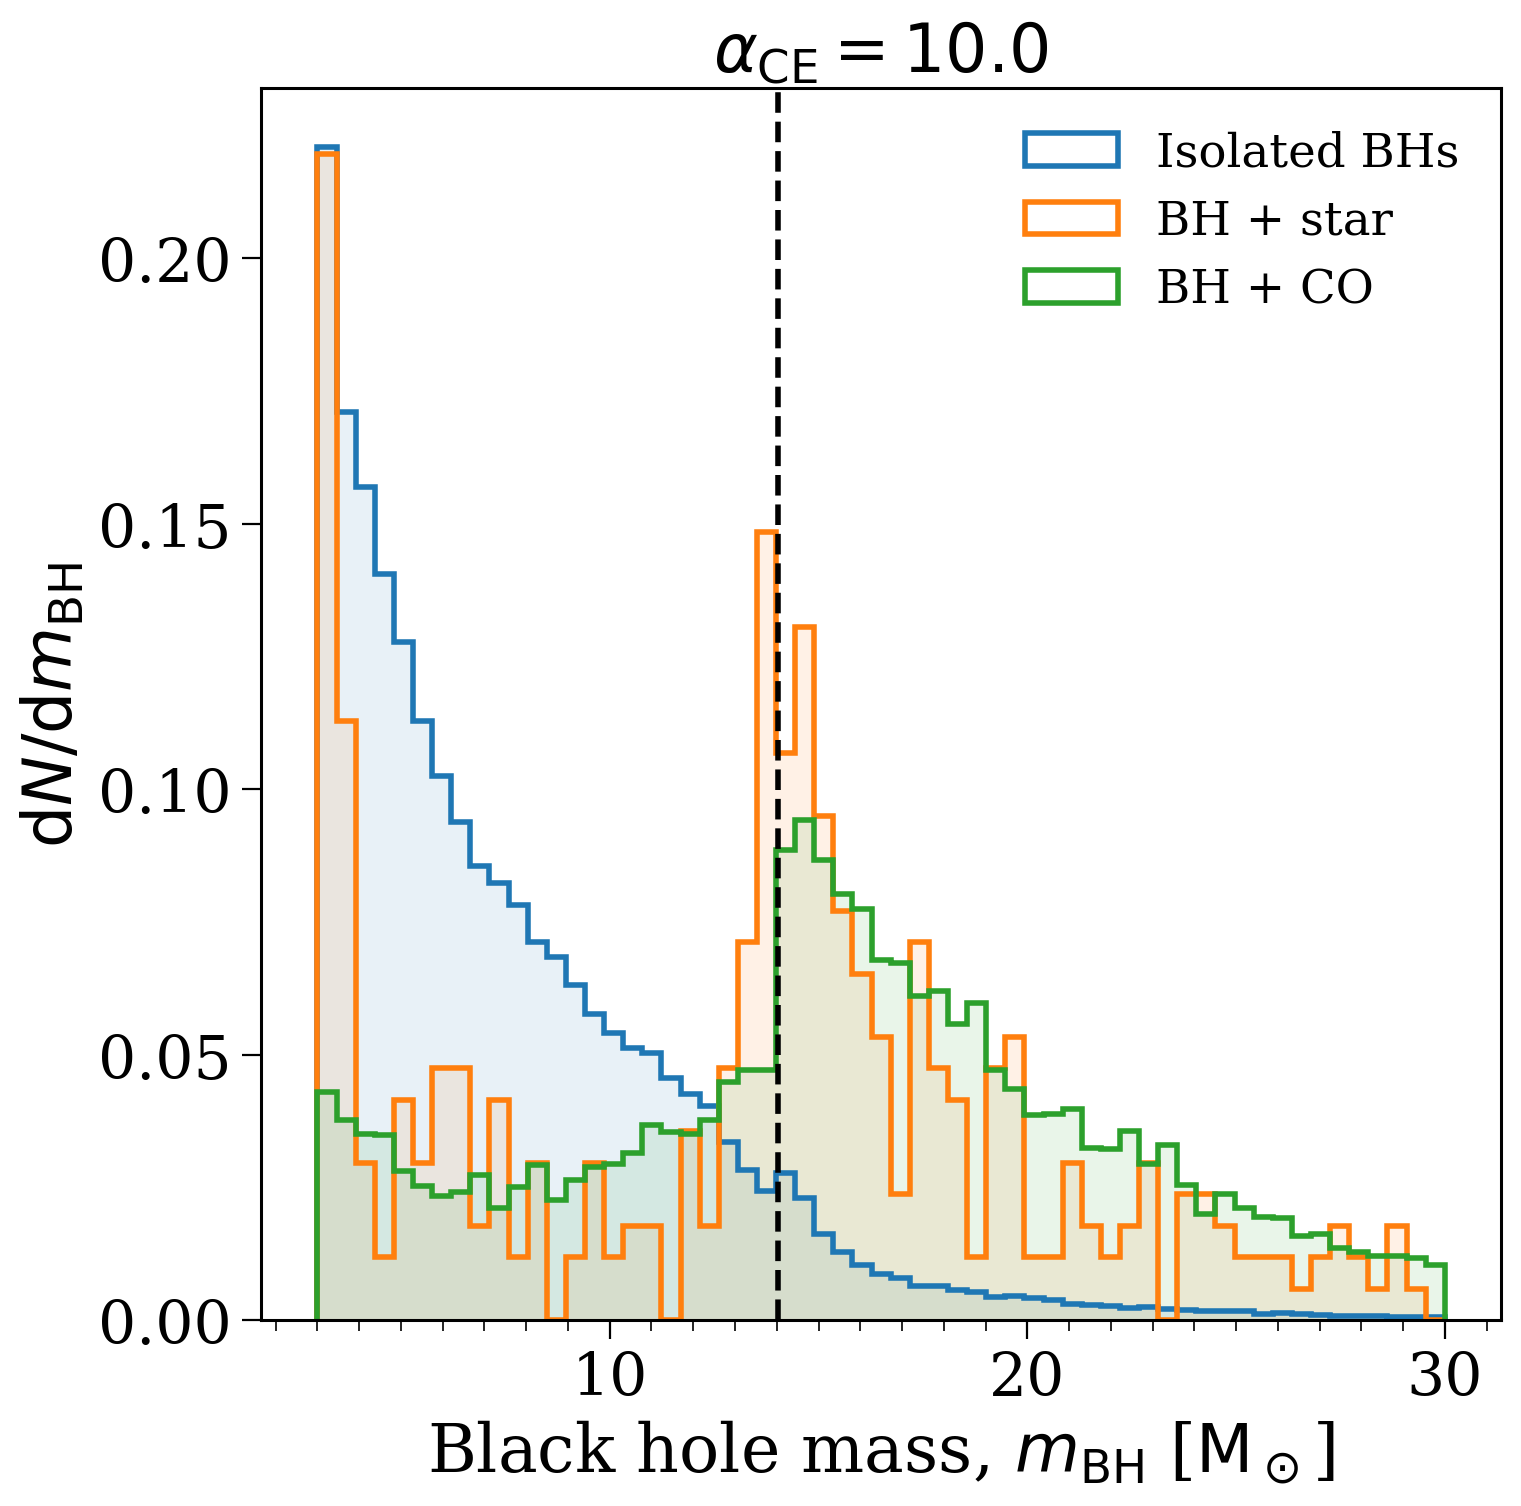

$q_{\rm crit, B} = 0$ 315


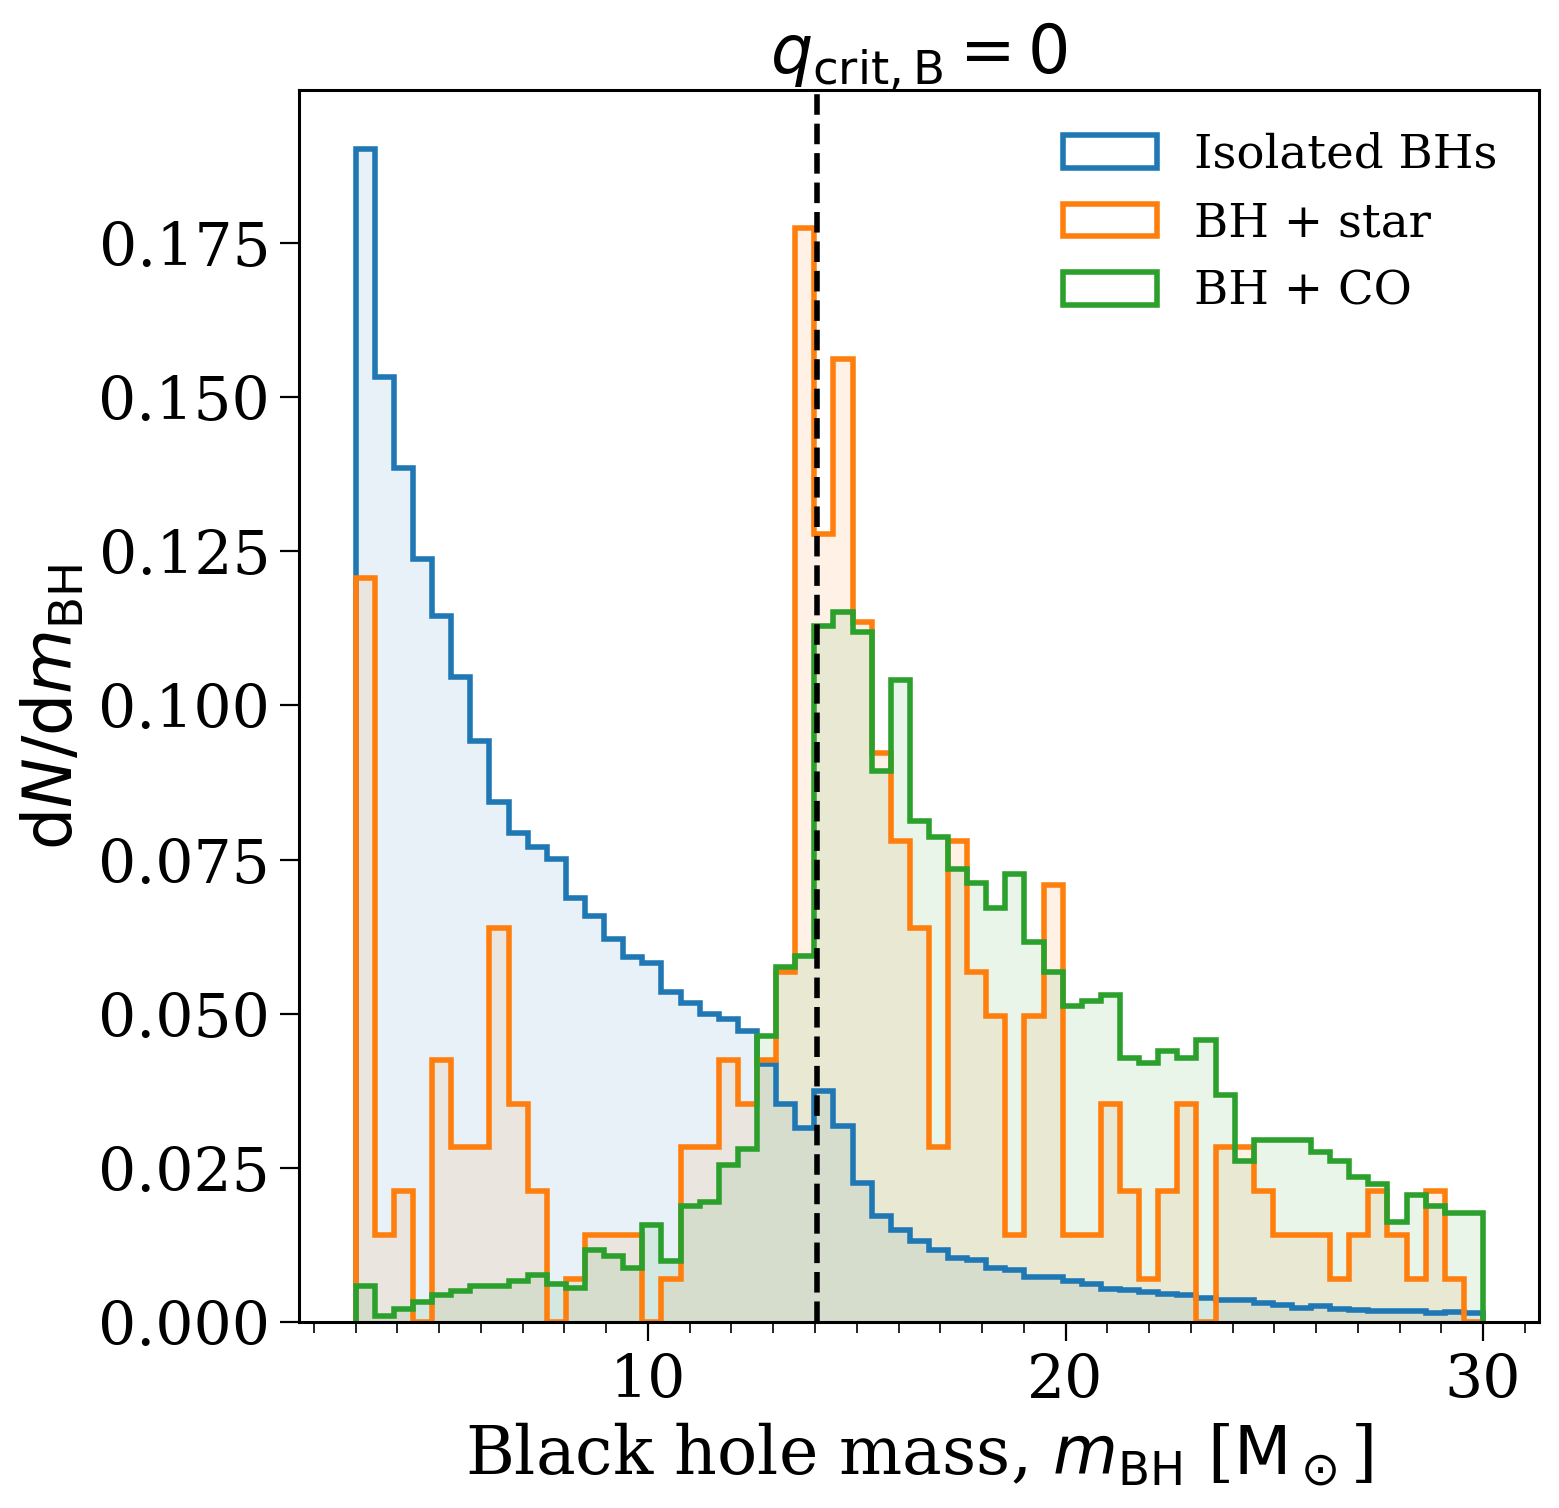

$q_{\rm crit, B} = \infty$ 418


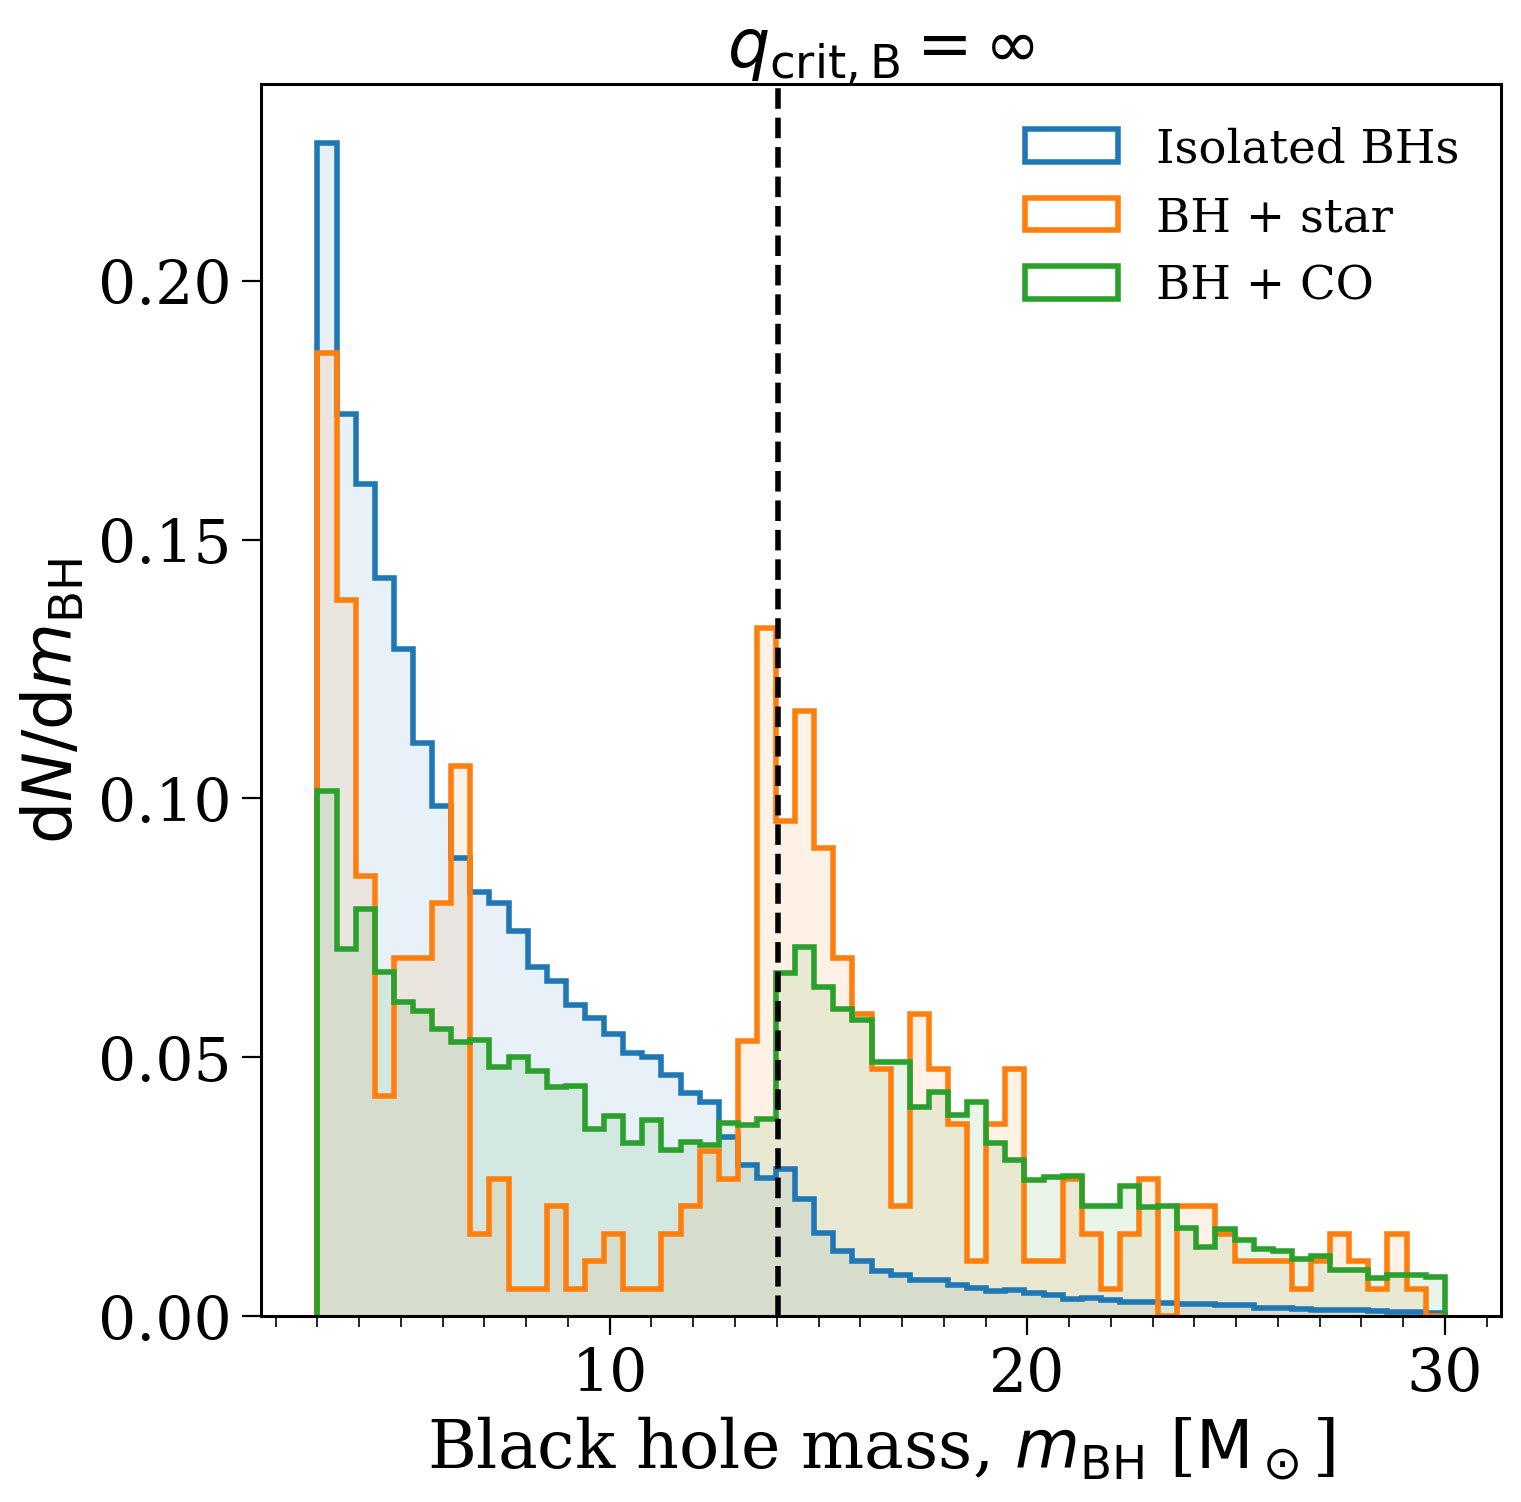

In [61]:
for pop_label in list(data.keys()):#['$f_{\\rm bin} = 1.0$', 'Fryer+2012 Rapid', 'Mandel\\&Muller2020', 'Maltsev+2025']:

    if pop_label == '$f_{\\rm bin} = 0.0$':
        continue

    fig, ax = plt.subplots(figsize=(8, 8))

    bins = np.linspace(3, 30, 60)
    density = True

    # pop_label = "Mandel\\&Muller2020"

    bh_bh = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["primary"]["BH"]) & (data[pop_label]["companion"]["BH"] == 14)
    bh_ns = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] == 13)
    bh_wd = (data[pop_label]["sep"]["BH"] > 0) & (np.isin(data[pop_label]["companion"]["BH"], [10, 11, 12]))
    bh_star = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] < 10)

    print(pop_label, bh_star.sum())

    for masses, colour, label in zip(
        [
            data[pop_label]["mass"]["BH"][data[pop_label]["sep"]["BH"] <= 0],
            data[pop_label]["mass"]["BH"][bh_star],
            data[pop_label]["mass"]["BH"][bh_bh | bh_ns | bh_wd],
        ],
        ['tab:blue', 'tab:orange', 'tab:green'],
        ["Isolated BHs","BH + star", "BH + CO"]
    ):
        plotting.nice_transparent_hist(
            ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
        )

        # ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]

    ax.axvline(14.04, ls='--', c='k', lw=2)

    # ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)

    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

    leg = ax.legend(fontsize=0.7*fs, frameon=False, loc='upper right')#, labelspacing=1.2)

    ax.set(
        xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
        ylabel=r"${\rm d}N/{\rm d}m_{\mathrm{BH}}$",
    )

    ax.set_title(plot_labels[labels.index(pop_label)], fontsize=fs)

    # plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
    plt.show()

In [151]:
p = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial/fiducial_part5.h5")

cogsworth warning: file was saved with gala v1.11.1.dev61 but you are using v1.11.1.dev77


In [154]:
stats["scale_up"][0] * 64.4

np.float64(6184.670379105397)

In [ ]:
51 * p.

In [153]:
(51 + 75 + 65 + 65 + 66) / 5

64.4

In [152]:
p.bpp[((p.bpp["kstar_1"] == 14) & (p.bpp["kstar_2"] == 14) & (p.bpp["evol_type"] == 3))]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_he_layer_1,massc_co_layer_1,massc_he_layer_2,massc_co_layer_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,omega_spin_1,omega_spin_2,bin_num
545,8.284530,15.487169,8.637821,14,14,0.000153,4.446199e-08,0.0,3,1.000353,0.728218,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2262.562899,3029.595027,1,1,1.464404e+11,200000000.0,545
14432,4909.823500,5.896607,5.350162,14,14,0.000064,1.762793e-08,0.0,3,1.010995,0.958984,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,3666.786211,3849.490045,1,1,5.154622e+08,200000000.0,14432
16962,223.089522,11.833398,4.075272,14,14,0.000106,3.170012e-08,0.0,3,1.000579,0.559403,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2588.403336,4410.708952,1,1,8.386207e+10,200000000.0,16962
27077,6215.070669,11.389459,7.859080,14,14,0.000117,3.343073e-08,0.0,3,1.003266,0.820090,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2638.366510,3176.148743,1,1,1.979735e+11,200000000.0,27077
32168,311.518232,12.598319,5.789966,14,14,0.000116,3.397840e-08,0.0,3,1.024725,0.671135,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2508.594044,3700.400091,1,1,8.104788e+10,200000000.0,32168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295301,124.169724,24.665600,4.099591,14,14,0.000193,5.807963e-08,0.0,3,1.008335,0.376072,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,1792.837127,4397.607011,1,1,9.133015e+10,200000000.0,295301
299020,728.357057,24.679918,6.538806,14,14,0.000207,6.193044e-08,0.0,3,1.016856,0.491893,0.0,0.0,2.757324,7.847629,1.000000e-10,1.000000e-10,1792.317017,3482.069669,1,1,9.181985e+10,200000000.0,299020
304086,905.873370,11.794597,6.192660,14,14,0.000111,3.180528e-08,0.0,3,1.037451,0.730740,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2592.657415,3578.063585,1,1,1.900566e+11,200000000.0,304086
309118,256.620950,11.529439,3.360169,14,14,0.000099,2.956332e-08,0.0,3,1.012507,0.516307,0.0,0.0,0.000000,0.000000,1.000000e-10,1.000000e-10,2622.301373,4857.425071,1,1,1.967099e+11,200000000.0,309118
